# MP6: Proyecto de IA y Big Data — Tema 2: Proyecto de Regresión

**Predicción de ventas diarias para un e-commerce (diciembre 2010 – diciembre 2011)**

---

## Planteamiento del problema

El objetivo es predecir el **valor total de ventas por día** entre el **9 de noviembre de 2011** y el **9 de diciembre de 2011** (test set), utilizando los datos históricos del 1 de diciembre de 2010 al 8 de noviembre de 2011 para entrenamiento y validación.

| Conjunto | Período |
|----------|--------|
| **Entrenamiento + Validación** | 01/12/2010 → 08/11/2011 |
| **Test** | 09/11/2011 → 09/12/2011 |

---

## Estructura del notebook

1. [Carga del dataset](#1-carga)
2. [Análisis Exploratorio (EDA)](#2-eda)
   - 2.1 Entendimiento de los datos
   - 2.2 Valores faltantes, duplicados y erróneos
   - 2.3 Búsqueda de outliers
   - 2.4 Gráficos auxiliares
   - 2.5 Análisis temporal
   - 2.6 Análisis de cancelaciones
   - 2.7 Ventas diarias brutas (variable objetivo)
   - 2.8 Top clientes y top productos
3. Limpieza de datos *(próxima sección)*
4. Transformación de datos *(próxima sección)*
5. División train / validation / test *(próxima sección)*
6. Modelos de regresión *(próxima sección)*

## 0. Imports y configuración global

In [270]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# Rutas
RUTA_CSV      = 'contenidoCSV/data.csv'
RUTA_GRAFICOS = 'graficos/'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
<a id="1-carga"></a>
## 1. Carga del dataset

El dataset es el fichero `data.csv` descargado de Kaggle. Contiene las transacciones de un e-commerce del Reino Unido entre el 1 de diciembre de 2010 y el 9 de diciembre de 2011.  
Se carga con `read_csv` de Pandas especificando `encoding='latin-1'` para evitar errores con caracteres especiales.

In [271]:
df = pd.read_csv(RUTA_CSV, encoding='latin-1')

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print('\nTipos de datos:')
print(df.dtypes)
print('\nPrimeras filas:')
df.head()

Filas: 541,909 | Columnas: 8

Tipos de datos:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Primeras filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
<a id="2-eda"></a>
## 2. Análisis Exploratorio de Datos (EDA)

Antes de limpiar o transformar nada, estudiamos a fondo el dataset para entender qué contiene cada columna, detectar anomalías y tomar decisiones informadas en la fase de limpieza.

### 2.1 Entendimiento de los datos

Exploramos dimensiones, tipos, valores únicos y estadísticas descriptivas. También identificamos transacciones con cantidades o precios negativos/cero, que en este dominio pueden corresponder a **devoluciones, regalos o ajustes contables**.

In [272]:
print('--- 2.1.1 Dimensiones y tipos de datos ---')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print('\nTipos de datos por columna:')
print(df.dtypes)

--- 2.1.1 Dimensiones y tipos de datos ---
Filas: 541,909 | Columnas: 8

Tipos de datos por columna:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [273]:
print('--- 2.1.2 Primeras 10 filas ---')
display(df.head(10))

print('\n--- 2.1.3 Últimas 10 filas ---')
display(df.tail(10))

--- 2.1.2 Primeras 10 filas ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom



--- 2.1.3 Últimas 10 filas ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,12/9/2011 12:50,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,12/9/2011 12:50,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,12/9/2011 12:50,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,12/9/2011 12:50,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/2011 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [274]:
print('--- 2.1.4 Valores únicos por columna ---')
for col in df.columns:
    print(f'  {col}: {df[col].nunique():,} valores únicos')

print('\n--- 2.1.5 Muestra de valores únicos (columnas categóricas) ---')
columnas_categoricas = ['InvoiceNo', 'StockCode', 'Description', 'Country']
for col in columnas_categoricas:
    muestra = df[col].dropna().unique()[:10]
    print(f'\n  {col} (primeros 10 únicos):')
    print(f'  {muestra}')

--- 2.1.4 Valores únicos por columna ---
  InvoiceNo: 25,900 valores únicos
  StockCode: 4,070 valores únicos
  Description: 4,223 valores únicos
  Quantity: 722 valores únicos
  InvoiceDate: 23,260 valores únicos
  UnitPrice: 1,630 valores únicos
  CustomerID: 4,372 valores únicos
  Country: 38 valores únicos

--- 2.1.5 Muestra de valores únicos (columnas categóricas) ---

  InvoiceNo (primeros 10 únicos):
  ['536365' '536366' '536367' '536368' '536369' '536370' '536371' '536372'
 '536373' '536374']

  StockCode (primeros 10 únicos):
  ['85123A' '71053' '84406B' '84029G' '84029E' '22752' '21730' '22633'
 '22632' '84879']

  Description (primeros 10 únicos):
  ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT']

  Country

In [275]:
print('--- 2.1.6 Estadísticas descriptivas (columnas numéricas) ---')
df.describe()

--- 2.1.6 Estadísticas descriptivas (columnas numéricas) ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [276]:
print('--- 2.1.7 Transacciones con Quantity <= 0 ---')
trans_qty_negativa = df[df['Quantity'] <= 0]
print(f'  Total filas con Quantity <= 0: {len(trans_qty_negativa):,}')
print(f'  % sobre total: {len(trans_qty_negativa) / len(df) * 100:.2f}%')
display(trans_qty_negativa[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

print('\n--- 2.1.8 Transacciones con UnitPrice <= 0 ---')
trans_price_negativa = df[df['UnitPrice'] <= 0]
print(f'  Total filas con UnitPrice <= 0: {len(trans_price_negativa):,}')
print(f'  % sobre total: {len(trans_price_negativa) / len(df) * 100:.2f}%')
display(trans_price_negativa[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

--- 2.1.7 Transacciones con Quantity <= 0 ---
  Total filas con Quantity <= 0: 10,624
  % sobre total: 1.96%


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
141,C536379,D,Discount,-1,27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25



--- 2.1.8 Transacciones con UnitPrice <= 0 ---
  Total filas con UnitPrice <= 0: 2,517
  % sobre total: 0.46%


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


### 2.2 Valores faltantes, duplicados y erróneos

Usamos `isnull`, `duplicated` y `value_counts` para cuantificar los problemas de calidad del dato:
- **CustomerID nulo**: transacciones anónimas (sin cliente registrado).
- **Description nula**: líneas de factura sin descripción de producto.
- **Filas duplicadas**: registros idénticos en todas sus columnas.
- **StockCodes no estándar**: códigos que no siguen el patrón `[0-9]{5}[A-Za-z]?` (p.ej. `POST`, `D`, `M`, `BANK CHARGES`).

In [277]:
print('--- 2.2.1 Valores faltantes (NaN) por columna ---')
nulos     = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% sobre total': nulos_pct.round(2)})
display(resumen_nulos[resumen_nulos['Nulos'] > 0])

--- 2.2.1 Valores faltantes (NaN) por columna ---


,Nulos,% sobre total
Description,1454,0.27
CustomerID,135080,24.93


In [278]:
print('--- 2.2.2 Filas sin CustomerID ---')
sin_cliente = df[df['CustomerID'].isnull()]
print(f'  Total: {len(sin_cliente):,} ({len(sin_cliente) / len(df) * 100:.2f}%)')
print('\n  Distribución por país (top 10):')
print(sin_cliente['Country'].value_counts().head(10))

--- 2.2.2 Filas sin CustomerID ---
  Total: 135,080 (24.93%)

  Distribución por país (top 10):
Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64


In [279]:
print('--- 2.2.3 Filas sin Description ---')
sin_descripcion = df[df['Description'].isnull()]
print(f'  Total: {len(sin_descripcion):,} ({len(sin_descripcion) / len(df) * 100:.2f}%)')
display(sin_descripcion[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))

print('\n--- 2.2.4 Filas sin CustomerID y sin Description simultáneamente ---')
sin_ambos = df[df['CustomerID'].isnull() & df['Description'].isnull()]
print(f'  Total: {len(sin_ambos):,}')

--- 2.2.3 Filas sin Description ---
  Total: 1,454 (0.27%)


,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
622,536414,22139,56,0.0,NaN
1970,536545,21134,1,0.0,NaN
1971,536546,22145,1,0.0,NaN
1972,536547,37509,1,0.0,NaN
1987,536549,85226A,1,0.0,NaN
1988,536550,85044,1,0.0,NaN
2024,536552,20950,1,0.0,NaN
2025,536553,37461,3,0.0,NaN
2026,536554,84670,23,0.0,NaN
2406,536589,21777,-10,0.0,NaN



--- 2.2.4 Filas sin CustomerID y sin Description simultáneamente ---
  Total: 1,454


In [280]:
print('--- 2.2.5 Filas duplicadas (exactas) ---')
duplicados = df.duplicated()
print(f'  Total: {duplicados.sum():,} ({duplicados.sum() / len(df) * 100:.2f}%)')
display(df[duplicados].head(10))

--- 2.2.5 Filas duplicadas (exactas) ---
  Total: 5,268 (0.97%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,12/1/2010 11:49,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,12/1/2010 11:49,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,12/1/2010 11:49,3.75,17920.0,United Kingdom


In [281]:
print('--- 2.2.6 Formato de InvoiceDate (actualmente string) ---')
print('  Muestra de valores de InvoiceDate:')
print(df['InvoiceDate'].value_counts().head(10))
print(f'\n  Min: {df["InvoiceDate"].min()}')
print(f'  Max: {df["InvoiceDate"].max()}')

--- 2.2.6 Formato de InvoiceDate (actualmente string) ---
  Muestra de valores de InvoiceDate:
InvoiceDate
10/31/2011 14:41    1114
12/8/2011 9:28       749
12/9/2011 10:03      731
12/5/2011 17:24      721
6/29/2011 15:58      705
11/30/2011 15:13     687
12/8/2011 9:20       676
12/6/2010 16:57      675
12/5/2011 17:28      662
12/9/2010 14:09      652
Name: count, dtype: int64

  Min: 1/10/2011 10:04
  Max: 9/9/2011 9:52


In [282]:
print('--- 2.2.7 StockCodes no estándar (posibles errores) ---')
# Patrón estándar: 5 dígitos + letra opcional
stock_no_estandar = df[~df['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)]
print(f'  Total filas con StockCode no estándar: {len(stock_no_estandar):,}')
print('  Tipos de StockCodes no estándar (top 15):')
print(stock_no_estandar['StockCode'].value_counts().head(15))

--- 2.2.7 StockCodes no estándar (posibles errores) ---
  Total filas con StockCode no estándar: 3,385
  Tipos de StockCodes no estándar (top 15):
StockCode
POST            1256
DOT              710
M                571
15056BL          326
C2               144
D                 77
S                 63
15056bl           62
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
Name: count, dtype: int64


In [283]:
print('--- 2.2.8 Distribución de Country (value_counts) ---')
print(df['Country'].value_counts())

--- 2.2.8 Distribución de Country (value_counts) ---
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European 

### 2.3 Búsqueda de outliers

Aplicamos el **método IQR** (rango intercuartílico) tanto a `Quantity` como a `UnitPrice` para identificar valores extremos que podrían distorsionar el modelo. Como regla general, esperamos que el **90–95 % de los datos queden dentro del rango normal**.

$$\text{Límite inferior} = Q1 - 1{,}5 \cdot IQR \qquad \text{Límite superior} = Q3 + 1{,}5 \cdot IQR$$

In [284]:
print('--- 2.3.1 Outliers en Quantity (método IQR) ---')
Q1_qty  = df['Quantity'].quantile(0.25)
Q3_qty  = df['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lim_inf_qty = Q1_qty - 1.5 * IQR_qty
lim_sup_qty = Q3_qty + 1.5 * IQR_qty
outliers_qty = df[(df['Quantity'] < lim_inf_qty) | (df['Quantity'] > lim_sup_qty)]

print(f'  Q1={Q1_qty} | Q3={Q3_qty} | IQR={IQR_qty}')
print(f'  Límite inferior: {lim_inf_qty:.2f} | Límite superior: {lim_sup_qty:.2f}')
print(f'  Total outliers: {len(outliers_qty):,} ({len(outliers_qty) / len(df) * 100:.2f}%)')

print('\n  Top 5 mayores:')
display(df.nlargest(5, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])
print('\n  Top 5 menores:')
display(df.nsmallest(5, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])

--- 2.3.1 Outliers en Quantity (método IQR) ---
  Q1=1.0 | Q3=10.0 | IQR=9.0
  Límite inferior: -12.50 | Límite superior: 23.50
  Total outliers: 58,619 (10.82%)

  Top 5 mayores:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00
74614,542504,37413,NaN,5568,0.00
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21



  Top 5 menores:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04
225529,556690,23005,printing smudges/thrown away,-9600,0.00
225530,556691,23005,printing smudges/thrown away,-9600,0.00
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03


In [285]:
print('--- 2.3.2 Outliers en UnitPrice (método IQR) ---')
Q1_price  = df['UnitPrice'].quantile(0.25)
Q3_price  = df['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lim_inf_price = Q1_price - 1.5 * IQR_price
lim_sup_price = Q3_price + 1.5 * IQR_price
outliers_price = df[(df['UnitPrice'] < lim_inf_price) | (df['UnitPrice'] > lim_sup_price)]

print(f'  Q1={Q1_price} | Q3={Q3_price} | IQR={IQR_price}')
print(f'  Límite inferior: {lim_inf_price:.2f} | Límite superior: {lim_sup_price:.2f}')
print(f'  Total outliers: {len(outliers_price):,} ({len(outliers_price) / len(df) * 100:.2f}%)')

print('\n  Top 5 precios más altos:')
display(df.nlargest(5, 'UnitPrice')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])

--- 2.3.2 Outliers en UnitPrice (método IQR) ---
  Q1=1.25 | Q3=4.13 | IQR=2.88
  Límite inferior: -3.07 | Límite superior: 8.45
  Total outliers: 39,627 (7.31%)

  Top 5 precios más altos:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
222681,C556445,M,Manual,-1,38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33


In [286]:
print('--- 2.3.3 StockCodes menos frecuentes (outliers categóricos) ---')
stock_freq  = df['StockCode'].value_counts()
stock_raros = stock_freq[stock_freq <= 3]
print(f'  StockCodes con ≤3 apariciones: {len(stock_raros):,}')
print(stock_raros.head(10))

print('\n--- 2.3.4 Descriptions menos frecuentes (outliers categóricos) ---')
desc_freq  = df['Description'].value_counts()
desc_raras = desc_freq[desc_freq <= 3]
print(f'  Descriptions con ≤3 apariciones: {len(desc_raras):,}')
print(desc_raras.head(10))

--- 2.3.3 StockCodes menos frecuentes (outliers categóricos) ---
  StockCodes con ≤3 apariciones: 459
StockCode
20820     3
79157V    3
90011E    3
90179B    3
23446     3
23448     3
23635     3
90027A    3
90074     3
21757     3
Name: count, dtype: int64

--- 2.3.4 Descriptions menos frecuentes (outliers categóricos) ---
  Descriptions con ≤3 apariciones: 583
Description
LIGHTHOUSE PRINTED METAL SIGN          3
SET/4 GARDEN ROSE DINNER CANDLE        3
VINTAGE PHOTO ALBUM PARIS DAYS         3
RESIN BRACELET W PASTEL BEADS          3
NEW BAROQUE BLACK BOXES                3
FOLKART ZINC STAR CHRISTMAS DEC        3
SET/3 TALL GLASS CANDLE HOLDER PINK    3
GLASS BEAD HOOP EARRINGS BLACK         3
BLACK DROP CRYSTAL NECKLACE            3
POTTING SHED CANDLE CITRONELLA         3
Name: count, dtype: int64


In [287]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
print('--- 2.3.5 Distribución de Quantity por percentiles ---')
print(df['Quantity'].quantile(percentiles))

print('\n--- 2.3.6 Distribución de UnitPrice por percentiles ---')
print(df['UnitPrice'].quantile(percentiles))

--- 2.3.5 Distribución de Quantity por percentiles ---
0.01       -2.0
0.05        1.0
0.25        1.0
0.50        3.0
0.75       10.0
0.95       29.0
0.99      100.0
1.00    80995.0
Name: Quantity, dtype: float64

--- 2.3.6 Distribución de UnitPrice por percentiles ---
0.01        0.19
0.05        0.42
0.25        1.25
0.50        2.08
0.75        4.13
0.95        9.95
0.99       18.00
1.00    38970.00
Name: UnitPrice, dtype: float64


### 2.4 Gráficos auxiliares

Visualizamos los hallazgos del EDA para facilitar su interpretación y documentación. Los gráficos se guardan además en `graficos/` para la memoria del proyecto.

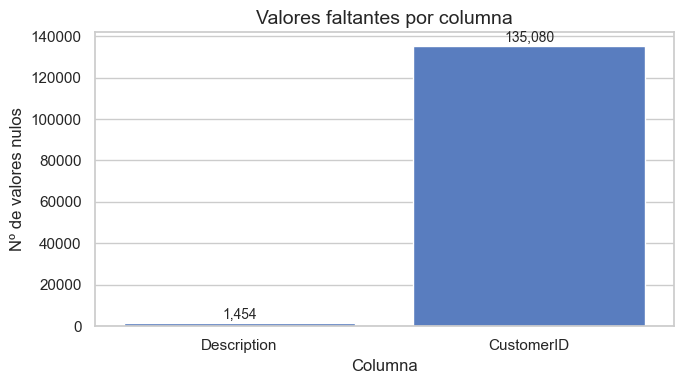

In [288]:
# 2.4.1 — Valores faltantes por columna
nulos_plot = df.isnull().sum()
nulos_plot = nulos_plot[nulos_plot > 0]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=nulos_plot.index, y=nulos_plot.values, ax=ax)
ax.set_title('Valores faltantes por columna', fontsize=14)
ax.set_xlabel('Columna')
ax.set_ylabel('Nº de valores nulos')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.1_valores_faltantes.png', dpi=150)
plt.show()

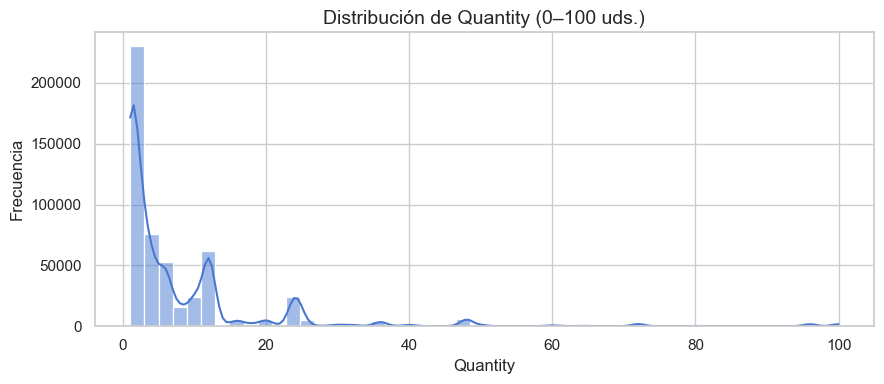

In [289]:
# 2.4.2 — Distribución de Quantity (rango normal: 0–100)
qty_filtrado = df[(df['Quantity'] > 0) & (df['Quantity'] <= 100)]

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(qty_filtrado['Quantity'], bins=50, ax=ax, kde=True)
ax.set_title('Distribución de Quantity (0–100 uds.)', fontsize=14)
ax.set_xlabel('Quantity')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.2_distribucion_quantity.png', dpi=150)
plt.show()

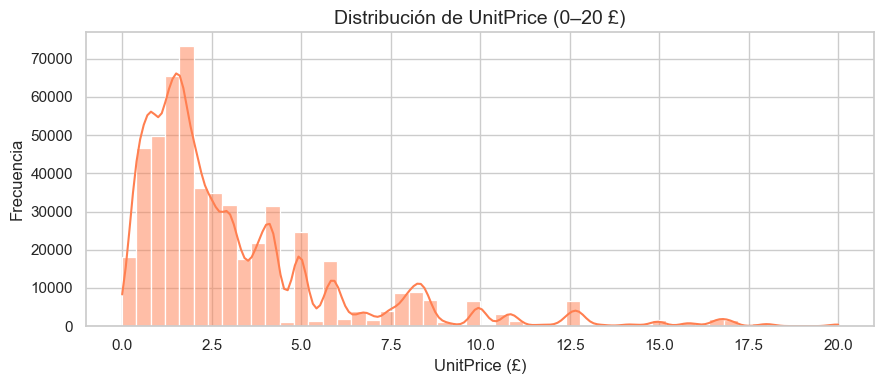

In [290]:
# 2.4.3 — Distribución de UnitPrice (rango normal: 0–20 £)
price_filtrado = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 20)]

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(price_filtrado['UnitPrice'], bins=50, ax=ax, kde=True, color='coral')
ax.set_title('Distribución de UnitPrice (0–20 £)', fontsize=14)
ax.set_xlabel('UnitPrice (£)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.3_distribucion_unitprice.png', dpi=150)
plt.show()

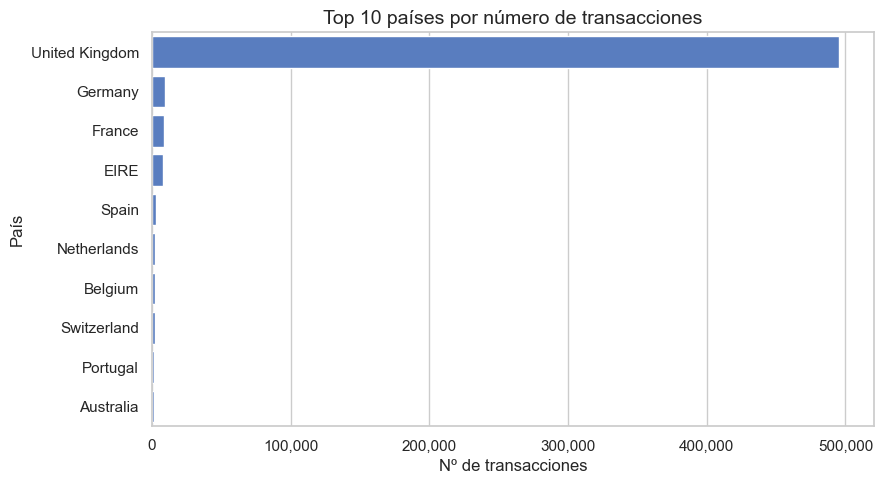

In [291]:
# 2.4.4 — Top 10 países por número de transacciones
top_paises = df['Country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_paises.values, y=top_paises.index, ax=ax, orient='h')
ax.set_title('Top 10 países por número de transacciones', fontsize=14)
ax.set_xlabel('Nº de transacciones')
ax.set_ylabel('País')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.4_top10_paises.png', dpi=150)
plt.show()

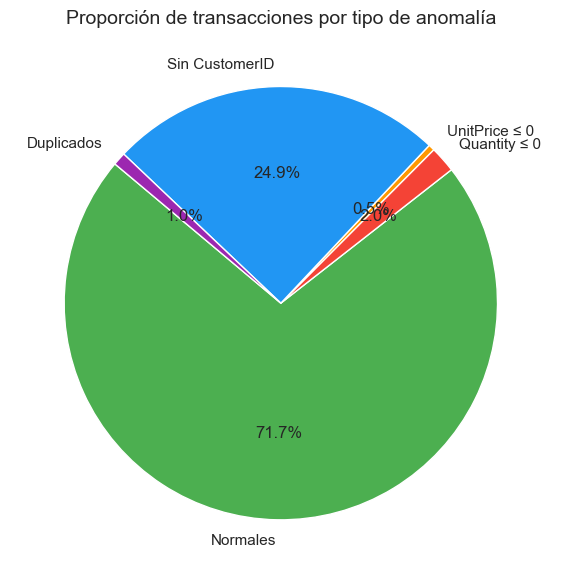

In [292]:
# 2.4.5 — Proporción de transacciones por tipo de anomalía
total        = len(df)
n_qty_neg    = (df['Quantity'] <= 0).sum()
n_price_neg  = (df['UnitPrice'] <= 0).sum()
n_sin_client = df['CustomerID'].isnull().sum()
n_duplicados = df.duplicated().sum()
n_normales   = total - n_qty_neg - n_price_neg - n_sin_client - n_duplicados

labels  = ['Normales', 'Quantity ≤ 0', 'UnitPrice ≤ 0', 'Sin CustomerID', 'Duplicados']
valores = [n_normales, n_qty_neg, n_price_neg, n_sin_client, n_duplicados]
colores = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(valores, labels=labels, colors=colores, autopct='%1.1f%%', startangle=140)
ax.set_title('Proporción de transacciones por tipo de anomalía', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.5_proporcion_anomalias.png', dpi=150)
plt.show()

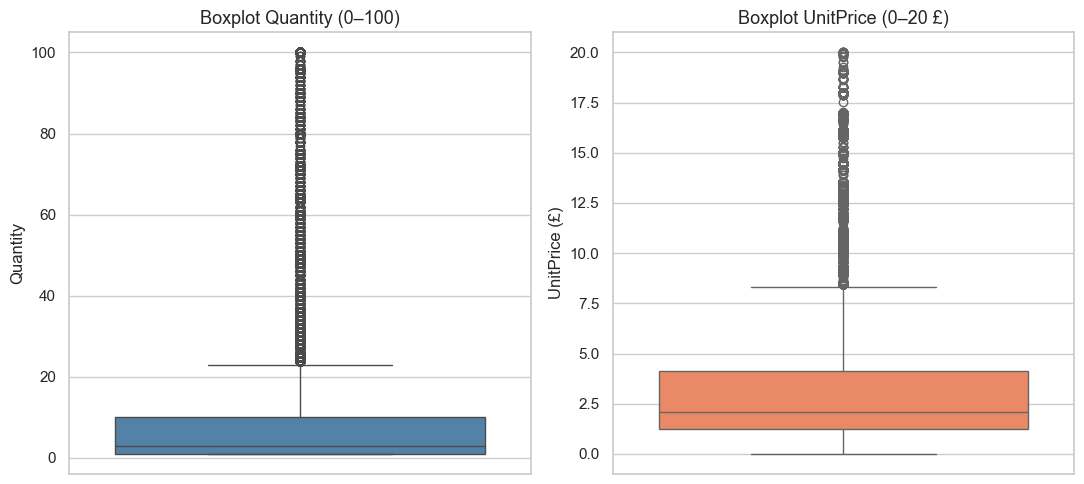

In [293]:
# 2.4.6 — Boxplots de Quantity y UnitPrice
qty_box   = df[(df['Quantity'] > 0)   & (df['Quantity'] <= 100)]['Quantity']
price_box = df[(df['UnitPrice'] > 0)  & (df['UnitPrice'] <= 20)]['UnitPrice']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(y=qty_box,   ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot Quantity (0–100)', fontsize=13)
axes[0].set_ylabel('Quantity')

sns.boxplot(y=price_box, ax=axes[1], color='coral')
axes[1].set_title('Boxplot UnitPrice (0–20 £)', fontsize=13)
axes[1].set_ylabel('UnitPrice (£)')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.6_boxplots.png', dpi=150)
plt.show()

### 2.5 Análisis temporal

Convertimos `InvoiceDate` a tipo `datetime` y analizamos la distribución de transacciones a lo largo del tiempo: por día, por mes y por día de la semana. También identificamos los **días sin datos** en el rango analizado.

In [294]:
print('--- 2.5.1 Conversión de InvoiceDate a datetime ---')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
print(f'  Tipo resultante : {df["InvoiceDate"].dtype}')
print(f'  Fecha mínima    : {df["InvoiceDate"].min()}')
print(f'  Fecha máxima    : {df["InvoiceDate"].max()}')
print(f'  Rango total     : {(df["InvoiceDate"].max() - df["InvoiceDate"].min()).days} días')

# Columna de fecha normalizada (sin hora)
df['Fecha']     = df['InvoiceDate'].dt.normalize()
df['Mes']       = df['InvoiceDate'].dt.to_period('M')
df['DiaSemana'] = df['InvoiceDate'].dt.day_name()

--- 2.5.1 Conversión de InvoiceDate a datetime ---
  Tipo resultante : datetime64[ns]
  Fecha mínima    : 2010-12-01 08:26:00
  Fecha máxima    : 2011-12-09 12:50:00
  Rango total     : 373 días


In [295]:
print('--- 2.5.2 Transacciones por día ---')
trans_por_dia = df.groupby('Fecha').size().rename('NumTransacciones')
print(f'  Días con datos     : {len(trans_por_dia)}')
print(f'  Media trans/día    : {trans_por_dia.mean():.1f}')
print(f'  Máximo trans/día   : {trans_por_dia.max():,} ({trans_por_dia.idxmax().date()})')
print(f'  Mínimo trans/día   : {trans_por_dia.min():,} ({trans_por_dia.idxmin().date()})')

print('\n--- 2.5.3 Días sin datos en el rango ---')
rango_completo = pd.date_range(start=df['Fecha'].min(), end=df['Fecha'].max(), freq='D')
dias_sin_datos = rango_completo.difference(trans_por_dia.index)
print(f'  Días totales en el rango : {len(rango_completo)}')
print(f'  Días con datos           : {len(trans_por_dia)}')
print(f'  Días sin datos           : {len(dias_sin_datos)}')
print(dias_sin_datos.strftime('%Y-%m-%d').tolist())

--- 2.5.2 Transacciones por día ---
  Días con datos     : 305
  Media trans/día    : 1776.8
  Máximo trans/día   : 5,331 (2011-12-05)
  Mínimo trans/día   : 279 (2011-02-06)

--- 2.5.3 Días sin datos en el rango ---
  Días totales en el rango : 374
  Días con datos           : 305
  Días sin datos           : 69
['2010-12-04', '2010-12-11', '2010-12-18', '2010-12-24', '2010-12-25', '2010-12-26', '2010-12-27', '2010-12-28', '2010-12-29', '2010-12-30', '2010-12-31', '2011-01-01', '2011-01-02', '2011-01-03', '2011-01-08', '2011-01-15', '2011-01-22', '2011-01-29', '2011-02-05', '2011-02-12', '2011-02-19', '2011-02-26', '2011-03-05', '2011-03-12', '2011-03-19', '2011-03-26', '2011-04-02', '2011-04-09', '2011-04-16', '2011-04-22', '2011-04-23', '2011-04-24', '2011-04-25', '2011-04-29', '2011-04-30', '2011-05-02', '2011-05-07', '2011-05-14', '2011-05-21', '2011-05-28', '2011-05-30', '2011-06-04', '2011-06-11', '2011-06-18', '2011-06-25', '2011-07-02', '2011-07-09', '2011-07-16', '2011-07-23'

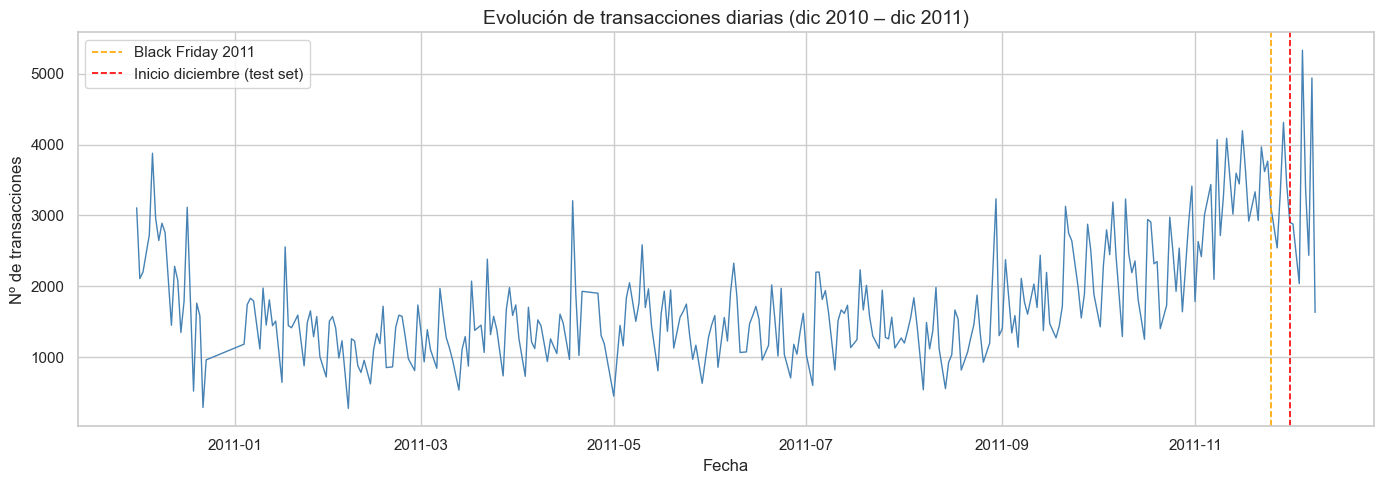

In [296]:
# 2.5.4 — Evolución de transacciones diarias
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trans_por_dia.index, trans_por_dia.values, linewidth=1, color='steelblue')
ax.set_title('Evolución de transacciones diarias (dic 2010 – dic 2011)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº de transacciones')
ax.axvline(pd.Timestamp('2011-11-25'), color='orange', linestyle='--', linewidth=1.2, label='Black Friday 2011')
ax.axvline(pd.Timestamp('2011-12-01'), color='red',    linestyle='--', linewidth=1.2, label='Inicio diciembre (test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.5.4_transacciones_diarias.png', dpi=150)
plt.show()

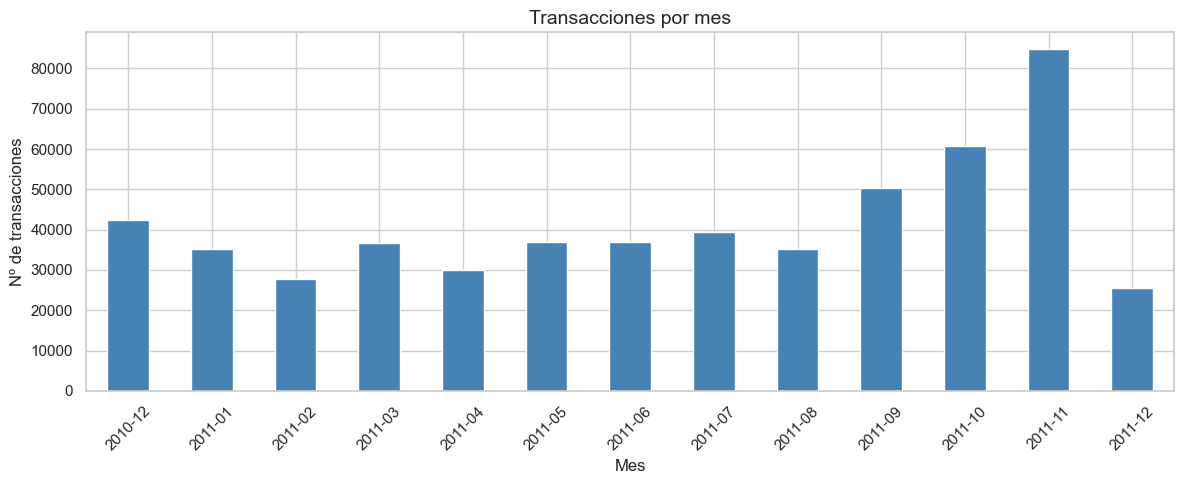

In [297]:
# 2.5.5 — Transacciones por mes
trans_por_mes = df.groupby('Mes').size().rename('NumTransacciones')

fig, ax = plt.subplots(figsize=(12, 5))
trans_por_mes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Transacciones por mes', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Nº de transacciones')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.5.5_transacciones_por_mes.png', dpi=150)
plt.show()

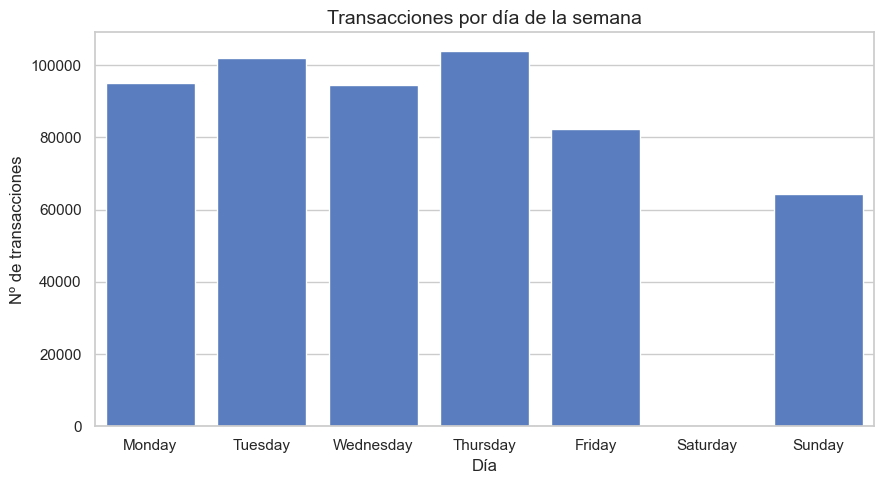

In [298]:
# 2.5.6 — Transacciones por día de la semana
dias_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trans_por_dia_semana = df.groupby('DiaSemana').size().reindex(dias_semana).rename('NumTransacciones')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=trans_por_dia_semana.index, y=trans_por_dia_semana.values, ax=ax)
ax.set_title('Transacciones por día de la semana', fontsize=14)
ax.set_xlabel('Día')
ax.set_ylabel('Nº de transacciones')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.5.6_transacciones_dia_semana.png', dpi=150)
plt.show()

### 2.6 Análisis de cancelaciones

Las facturas que empiezan por **`C`** en `InvoiceNo` son cancelaciones. Analizamos cuántas hay, cómo se cruzan con `Quantity < 0` y cuál es su evolución mensual.

Distinguimos tres categorías:
- **Cancelaciones normales**: prefijo `C` + `Quantity < 0`.
- **Cancelaciones con qty positiva**: prefijo `C` + `Quantity >= 0` (anomalía menor).
- **Huérfanos**: sin prefijo `C` pero con `Quantity < 0` (ajustes contables u otro tipo).

In [299]:
print('--- 2.6.1 Facturas con prefijo C ---')
df['EsCancelacion'] = df['InvoiceNo'].str.startswith('C')
n_cancelaciones = df['EsCancelacion'].sum()
print(f'  Total filas con prefijo C       : {n_cancelaciones:,}')
print(f'  % sobre total                   : {n_cancelaciones / len(df) * 100:.2f}%')
print(f'  Facturas únicas canceladas      : {df[df["EsCancelacion"]]["InvoiceNo"].nunique():,}')

--- 2.6.1 Facturas con prefijo C ---
  Total filas con prefijo C       : 9,288
  % sobre total                   : 1.71%
  Facturas únicas canceladas      : 3,836


In [300]:
print('--- 2.6.2 Cruce entre prefijo C y Quantity < 0 ---')
con_C_qty_neg = df[ df['EsCancelacion'] &  (df['Quantity'] < 0)]
con_C_qty_pos = df[ df['EsCancelacion'] & (df['Quantity'] >= 0)]
sin_C_qty_neg = df[~df['EsCancelacion'] &  (df['Quantity'] < 0)]
sin_C_qty_pos = df[~df['EsCancelacion'] & (df['Quantity'] >= 0)]

print(f'  Prefijo C + Qty<0  (cancelaciones normales)     : {len(con_C_qty_neg):>7,}')
print(f'  Prefijo C + Qty>=0 (cancelaciones qty positiva) : {len(con_C_qty_pos):>7,}')
print(f'  Sin C   + Qty<0    (huérfanos)                  : {len(sin_C_qty_neg):>7,}')
print(f'  Sin C   + Qty>=0   (transacciones normales)     : {len(sin_C_qty_pos):>7,}')

--- 2.6.2 Cruce entre prefijo C y Quantity < 0 ---
  Prefijo C + Qty<0  (cancelaciones normales)     :   9,288
  Prefijo C + Qty>=0 (cancelaciones qty positiva) :       0
  Sin C   + Qty<0    (huérfanos)                  :   1,336
  Sin C   + Qty>=0   (transacciones normales)     : 531,285


In [301]:
print('--- 2.6.3 Detalle de negativos huérfanos (sin prefijo C) ---')
print(f'  Total: {len(sin_C_qty_neg):,}')
if len(sin_C_qty_neg) > 0:
    display(sin_C_qty_neg[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))
    print('\n  StockCodes más frecuentes en huérfanos:')
    print(sin_C_qty_neg['StockCode'].value_counts().head(10))

print('\n--- 2.6.4 Cancelaciones con Quantity >= 0 (anomalía) ---')
print(f'  Total: {len(con_C_qty_pos):,}')
if len(con_C_qty_pos) > 0:
    display(con_C_qty_pos[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

--- 2.6.3 Detalle de negativos huérfanos (sin prefijo C) ---
  Total: 1,336


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
2406,536589,21777,NaN,-10,0.0,NaN
4347,536764,84952C,NaN,-38,0.0,NaN
7188,536996,22712,NaN,-20,0.0,NaN
7189,536997,22028,NaN,-20,0.0,NaN
7190,536998,85067,NaN,-6,0.0,NaN
7192,537000,21414,NaN,-22,0.0,NaN
7193,537001,21653,NaN,-6,0.0,NaN
7195,537003,85126,NaN,-2,0.0,NaN
7196,537004,21814,NaN,-30,0.0,NaN
7197,537005,21692,NaN,-70,0.0,NaN



  StockCodes más frecuentes en huérfanos:
StockCode
85175     5
21830     5
22719     4
82494L    4
85172     4
72802C    4
22162     3
84406B    3
22501     3
21621     3
Name: count, dtype: int64

--- 2.6.4 Cancelaciones con Quantity >= 0 (anomalía) ---
  Total: 0


In [302]:
print('--- 2.6.5 Cancelaciones por mes ---')
cancelaciones_mes = df[df['EsCancelacion']].groupby('Mes').size().rename('Cancelaciones')
total_mes         = df.groupby('Mes').size().rename('Total')
ratio_cancelacion = (cancelaciones_mes / total_mes * 100).round(2).rename('% Cancelaciones')
display(pd.concat([total_mes, cancelaciones_mes, ratio_cancelacion], axis=1))

--- 2.6.5 Cancelaciones por mes ---


,Total,Cancelaciones,% Cancelaciones
Mes,,,
2010-12,42481,728,1.71
2011-01,35147,701,1.99
2011-02,27707,475,1.71
2011-03,36748,699,1.90
2011-04,29916,559,1.87
2011-05,37030,621,1.68
2011-06,36874,711,1.93
2011-07,39518,685,1.73
2011-08,35284,668,1.89


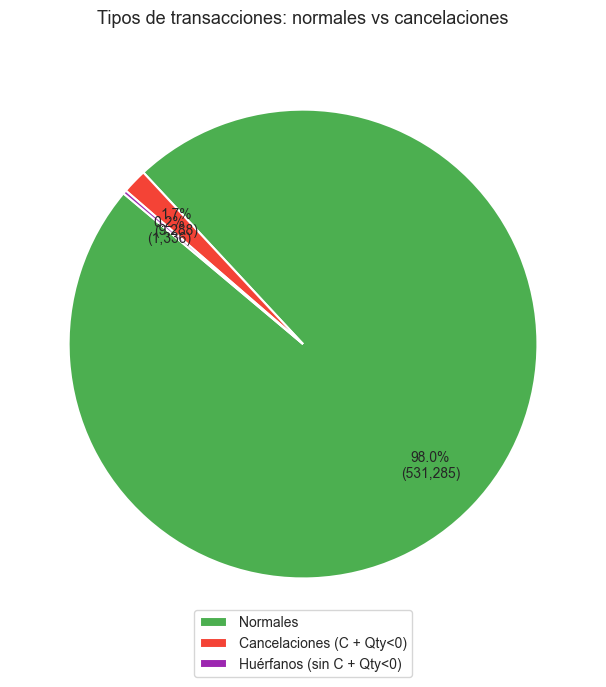

In [303]:
# 2.6.6 — Proporción cancelaciones vs normales
datos_grafico = {
    'Normales':                  len(sin_C_qty_pos),
    'Cancelaciones (C + Qty<0)': len(con_C_qty_neg),
    'Huérfanos (sin C + Qty<0)': len(sin_C_qty_neg),
}
labels_c  = list(datos_grafico.keys())
valores_c = list(datos_grafico.values())
colores_c = ['#4CAF50', '#F44336', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    valores_c,
    colors=colores_c,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(valores_c) / 100):,})',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for autotext in autotexts:
    autotext.set_fontsize(10)
ax.legend(wedges, labels_c, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=1, fontsize=10)
ax.set_title('Tipos de transacciones: normales vs cancelaciones', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.6.6_cancelaciones_proporcion.png', dpi=150)
plt.show()

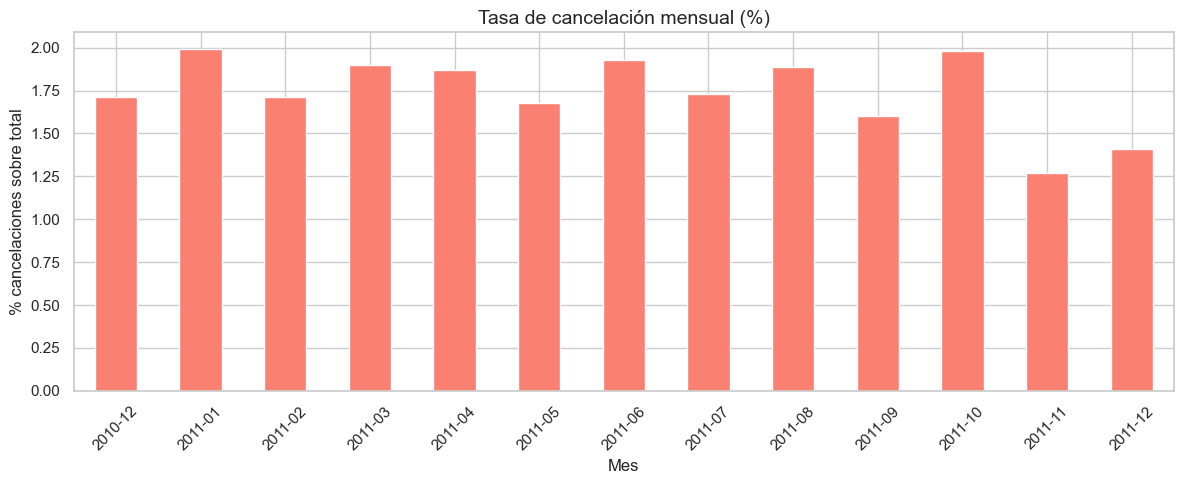

In [304]:
# 2.6.7 — Tasa de cancelación por mes
fig, ax = plt.subplots(figsize=(12, 5))
ratio_cancelacion.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Tasa de cancelación mensual (%)', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('% cancelaciones sobre total')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.6.7_tasa_cancelacion_mensual.png', dpi=150)
plt.show()

### 2.7 Ventas diarias brutas — Variable objetivo

Calculamos `TotalPrice = Quantity × UnitPrice` para obtener el valor económico de cada línea de transacción. Luego **agregamos por día** para tener una primera versión (sin limpiar) de la variable objetivo: **ventas totales diarias en £**.

> Nota: esta agregación es bruta, incluye cancelaciones y valores negativos. La versión limpia se generará en la siguiente sección.

In [305]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('--- 2.7.1 Estadísticas de TotalPrice por fila ---')
print(df['TotalPrice'].describe())

--- 2.7.1 Estadísticas de TotalPrice por fila ---
count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: TotalPrice, dtype: float64


In [306]:
print('--- 2.7.2 Agregación de ventas por día (bruto) ---')
ventas_diarias = df.groupby('Fecha')['TotalPrice'].sum().rename('VentasDiarias')
print(f'  Días con datos            : {len(ventas_diarias)}')
print(f'  Venta media diaria        : £{ventas_diarias.mean():>12,.2f}')
print(f'  Venta mediana diaria      : £{ventas_diarias.median():>11,.2f}')
print(f'  Venta máxima diaria       : £{ventas_diarias.max():>11,.2f} ({ventas_diarias.idxmax().date()})')
print(f'  Venta mínima diaria       : £{ventas_diarias.min():>11,.2f} ({ventas_diarias.idxmin().date()})')
print(f'  Días con ventas negativas : {(ventas_diarias < 0).sum()}')

--- 2.7.2 Agregación de ventas por día (bruto) ---
  Días con datos            : 305
  Venta media diaria        : £   31,959.83
  Venta mediana diaria      : £  27,978.41
  Venta máxima diaria       : £ 112,141.11 (2011-11-14)
  Venta mínima diaria       : £  -1,566.23 (2011-01-05)
  Días con ventas negativas : 1


In [307]:
print('--- 2.7.3 Ventas totales por mes ---')
ventas_mes = df.groupby('Mes')['TotalPrice'].sum().rename('VentasMes')
print(ventas_mes.apply(lambda x: f'£{x:,.2f}'))

print('\n--- 2.7.4 Distribución de ventas diarias por percentiles ---')
percentiles_v = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(ventas_diarias.quantile(percentiles_v).apply(lambda x: f'£{x:,.2f}'))

--- 2.7.3 Ventas totales por mes ---
Mes
2010-12      £748,957.02
2011-01      £560,000.26
2011-02      £498,062.65
2011-03      £683,267.08
2011-04      £493,207.12
2011-05      £723,333.51
2011-06      £691,123.12
2011-07      £681,300.11
2011-08      £682,680.51
2011-09    £1,019,687.62
2011-10    £1,070,704.67
2011-11    £1,461,756.25
2011-12      £433,668.01
Freq: M, Name: VentasMes, dtype: object

--- 2.7.4 Distribución de ventas diarias por percentiles ---
0.01     £5,165.59
0.05     £7,737.82
0.10    £12,374.99
0.25    £20,728.14
0.50    £27,978.41
0.75    £42,912.40
0.90    £56,905.16
0.95    £62,918.36
0.99    £78,351.25
Name: VentasDiarias, dtype: object


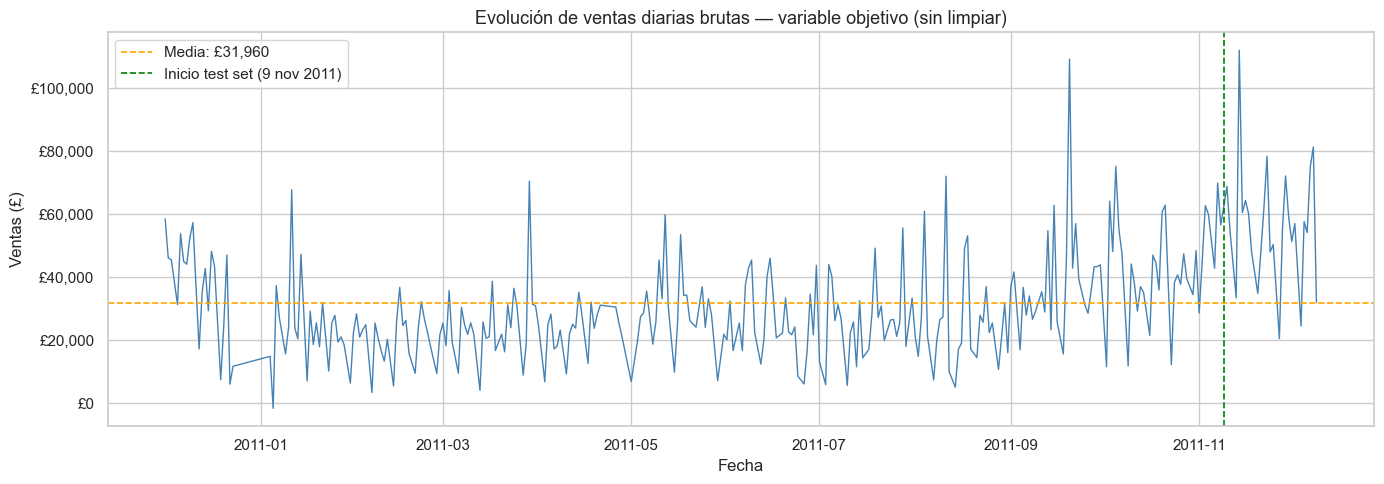

In [308]:
# 2.7.5 — Evolución de ventas diarias brutas
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ventas_diarias.index, ventas_diarias.values, linewidth=1, color='steelblue')
ax.axhline(ventas_diarias.mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Media: £{ventas_diarias.mean():,.0f}')
ax.axvline(pd.Timestamp('2011-11-09'), color='green', linestyle='--', linewidth=1.2,
           label='Inicio test set (9 nov 2011)')
ax.set_title('Evolución de ventas diarias brutas — variable objetivo (sin limpiar)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.7.5_ventas_diarias_brutas.png', dpi=150)
plt.show()

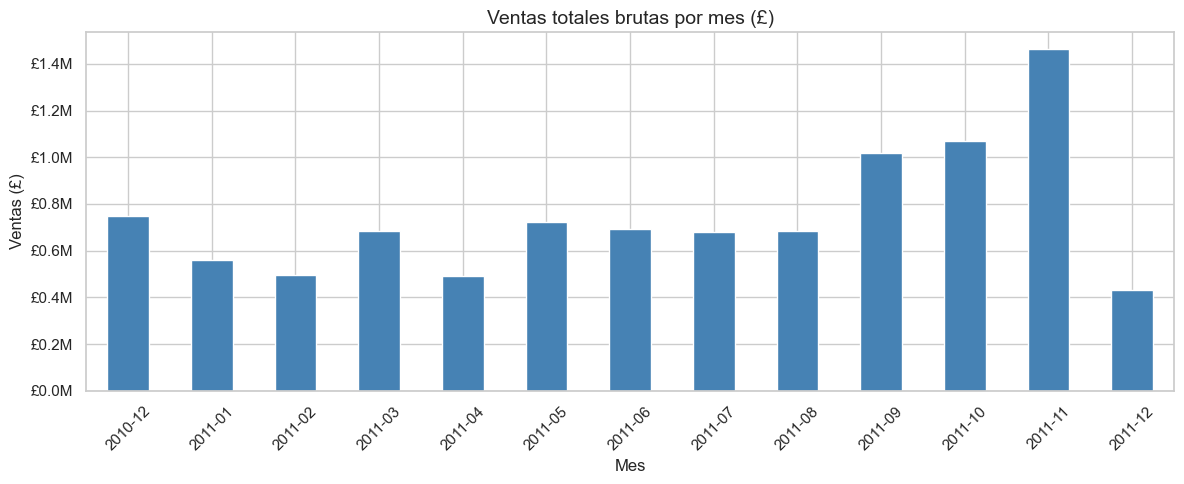

In [309]:
# 2.7.6 — Ventas totales por mes
fig, ax = plt.subplots(figsize=(12, 5))
ventas_mes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Ventas totales brutas por mes (£)', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.7.6_ventas_mensuales_brutas.png', dpi=150)
plt.show()

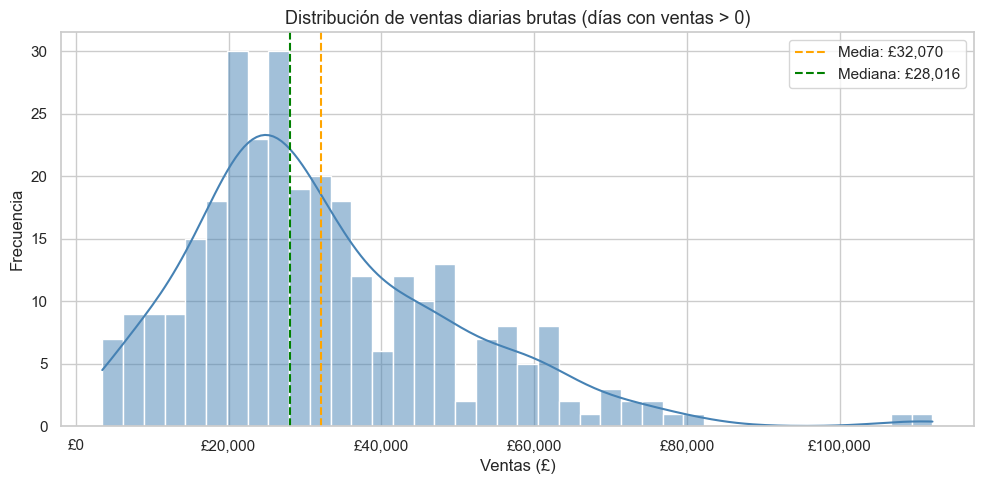

In [310]:
# 2.7.7 — Distribución de ventas diarias (días > 0)
ventas_positivas = ventas_diarias[ventas_diarias > 0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ventas_positivas, bins=40, ax=ax, kde=True, color='steelblue')
ax.axvline(ventas_positivas.mean(),   color='orange', linestyle='--', linewidth=1.5,
           label=f'Media: £{ventas_positivas.mean():,.0f}')
ax.axvline(ventas_positivas.median(), color='green',  linestyle='--', linewidth=1.5,
           label=f'Mediana: £{ventas_positivas.median():,.0f}')
ax.set_title('Distribución de ventas diarias brutas (días con ventas > 0)', fontsize=13)
ax.set_xlabel('Ventas (£)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.7.7_distribucion_ventas_diarias.png', dpi=150)
plt.show()

### 2.8 Top clientes y top productos

Analizamos qué clientes y productos concentran la mayor parte de las ventas. Es relevante para detectar posibles outliers de negocio (un cliente mayorista con miles de unidades puede distorsionar los patrones de ventas minoristas).

In [311]:
print('--- 2.8.1 Top 10 clientes por volumen de ventas ---')
ventas_cliente = (
    df[df['CustomerID'].notna()]
    .groupby('CustomerID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)
top10_clientes = ventas_cliente.head(10)
total_ventas   = df['TotalPrice'].sum()

print(f'  Ventas totales brutas: £{total_ventas:,.2f}')
print(f'\n  {"CustomerID":<15} {"Ventas (£)":>15} {"% sobre total":>15}')
print(f'  {"-"*45}')
for cid, ventas in top10_clientes.items():
    print(f'  {int(cid):<15} £{ventas:>13,.2f} {ventas / total_ventas * 100:>14.2f}%')

pct_top10 = top10_clientes.sum() / total_ventas * 100
print(f'\n  Top 10 clientes concentran el {pct_top10:.1f}% de las ventas totales')

--- 2.8.1 Top 10 clientes por volumen de ventas ---
  Ventas totales brutas: £9,747,747.93

  CustomerID           Ventas (£)   % sobre total
  ---------------------------------------------
  14646           £   279,489.02           2.87%
  18102           £   256,438.49           2.63%
  17450           £   187,482.17           1.92%
  14911           £   132,572.62           1.36%
  12415           £   123,725.45           1.27%
  14156           £   113,384.14           1.16%
  17511           £    88,125.38           0.90%
  16684           £    65,892.08           0.68%
  13694           £    62,653.10           0.64%
  15311           £    59,419.34           0.61%

  Top 10 clientes concentran el 14.0% de las ventas totales


# 3. LIMPIEZA DE DATOS

In [312]:
df_clean = df.copy()
filas_iniciales = len(df_clean)
print(f"\n\n{'='*60}")
print(f"  INICIO LIMPIEZA — Filas iniciales: {filas_iniciales:,}")
print(f"{'='*60}")



  INICIO LIMPIEZA — Filas iniciales: 541,909


### 3.1 ELIMINAR FILAS CON Description NULA

Motivo: el 100% de estas filas cumplen simultáneamente:
 - Description = NaN  → no sabemos qué producto es
 - UnitPrice = 0      → no generan ningún ingreso (TotalPrice = 0)
 - CustomerID = NaN   → no tienen cliente asociado
No son recuperables y solo añadirían ruido al modelo.

In [313]:
print("\n--- 3.1 Eliminar filas con Description nula ---")

antes = len(df_clean)
df_clean = df_clean.dropna(subset=['Description']).reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:     {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:   {len(df_clean):,}")
print(f"  Verificación — Description nulos restantes: {df_clean['Description'].isnull().sum()}")


--- 3.1 Eliminar filas con Description nula ---
  Filas antes:     541,909
  Filas eliminadas: 1,454
  Filas después:   540,455
  Verificación — Description nulos restantes: 0


### 3.2 ELIMINAR DUPLICADOS EXACTOS

 Una fila duplicada exacta tiene TODOS sus campos idénticos: mismo InvoiceNo,
 StockCode, Description, Quantity, UnitPrice, InvoiceDate, CustomerID y Country.
 Esto es físicamente imposible en un sistema transaccional real: si el mismo cliente
 compra el mismo producto en el mismo instante, el sistema generaría un InvoiceNo
 distinto o un timestamp diferente. Su presencia indica errores de doble inserción
 en la BBDD, exports corruptos o fallos de ETL.

In [314]:
print("\n--- 3.2 Eliminar duplicados exactos ---")

antes = len(df_clean)
df_clean = df_clean.drop_duplicates(keep='first', ignore_index=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
print(f"  Verificación — duplicados restantes: {df_clean.duplicated().sum()}")


--- 3.2 Eliminar duplicados exactos ---
  Filas antes:      540,455
  Filas eliminadas: 5,268
  Filas después:    535,187
  Verificación — duplicados restantes: 0



### 3.3 ELIMINAR NEGATIVOS HUÉRFANOS

 Son filas con Quantity < 0 pero SIN prefijo "C" en InvoiceNo.
 El análisis directo del CSV confirma que el 100% cumple simultáneamente:
   - UnitPrice = 0.0  → TotalPrice = 0 siempre, sin impacto en ingresos
   - CustomerID = NaN → ninguna tiene cliente asociado
   - InvoiceNo sin "C" → el sistema nunca las registró como cancelación 

In [315]:
print("\n--- 3.3 Eliminar negativos huérfanos (ajustes de almacén) ---")

antes = len(df_clean)
mask_huerfanos = (
    ~df_clean['InvoiceNo'].str.startswith('C', na=False) &
    (df_clean['Quantity'] < 0) &
    (df_clean['UnitPrice'] == 0.0)
)
df_clean = df_clean[~mask_huerfanos].reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
print(f"  Verificación — negativos huérfanos restantes: {(~df_clean['InvoiceNo'].str.startswith('C', na=False) & (df_clean['Quantity'] < 0) & (df_clean['UnitPrice'] == 0.0)).sum()}")


--- 3.3 Eliminar negativos huérfanos (ajustes de almacén) ---
  Filas antes:      535,187
  Filas eliminadas: 474
  Filas después:    534,713
  Verificación — negativos huérfanos restantes: 0


### 3.4 ELIMINAR STOCKCODES NO ESTÁNDAR

In [316]:
print("\n--- 3.4 Eliminar StockCodes no estándar ---")

antes = len(df_clean)
mask_std = df_clean['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)
df_clean = df_clean[mask_std].reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
n_no_std = (~df_clean['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)).sum()
print(f"  Verificación — StockCodes no estándar restantes: {n_no_std}")


--- 3.4 Eliminar StockCodes no estándar ---
  Filas antes:      534,713
  Filas eliminadas: 3,357
  Filas después:    531,356
  Verificación — StockCodes no estándar restantes: 0


### 3.5 CAPPING (WINSORIZACIÓN) DE OUTLIERS EN Quantity Y UnitPrice


In [317]:
print("\n--- 3.5 Capping de outliers (winsorización al percentil 99) ---")

cap_qty   = df_clean.loc[df_clean['Quantity']  > 0, 'Quantity'].quantile(0.99)
cap_price = df_clean.loc[df_clean['UnitPrice'] > 0, 'UnitPrice'].quantile(0.99)

print(f"  Umbral Quantity   (p99): {cap_qty:.1f} uds  →  clip [{-cap_qty:.1f}, {cap_qty:.1f}]")
print(f"  Umbral UnitPrice  (p99): £{cap_price:.2f}  →  clip [-, {cap_price:.2f}]")

n_qty_sup  = (df_clean['Quantity']  >  cap_qty).sum()
n_qty_inf  = (df_clean['Quantity']  < -cap_qty).sum()
n_price_sup = (df_clean['UnitPrice'] >  cap_price).sum()
print(f"  Filas Quantity  > +umbral (recortadas arriba): {n_qty_sup:,}")
print(f"  Filas Quantity  < -umbral (recortadas abajo):  {n_qty_inf:,}")
print(f"  Filas UnitPrice > umbral  (recortadas arriba): {n_price_sup:,}")

df_clean['Quantity']  = df_clean['Quantity'].clip(lower=-cap_qty, upper=cap_qty)
df_clean['UnitPrice'] = df_clean['UnitPrice'].clip(upper=cap_price)

# Recalcular TotalPrice con los valores ya capeados
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"  Quantity  rango tras capping:  [{df_clean['Quantity'].min():.1f}, {df_clean['Quantity'].max():.1f}]")
print(f"  UnitPrice máxima tras capping: £{df_clean['UnitPrice'].max():.2f}")
print(f"  Filas totales (sin cambio):    {len(df_clean):,}")

print("\n  Estadísticas post-capping (validación de rangos):")
print(df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].describe().round(2))


--- 3.5 Capping de outliers (winsorización al percentil 99) ---
  Umbral Quantity   (p99): 100.0 uds  →  clip [-100.0, 100.0]
  Umbral UnitPrice  (p99): £16.63  →  clip [-, 16.63]
  Filas Quantity  > +umbral (recortadas arriba): 4,883
  Filas Quantity  < -umbral (recortadas abajo):  154
  Filas UnitPrice > umbral  (recortadas arriba): 4,889
  Quantity  rango tras capping:  [-100.0, 100.0]
  UnitPrice máxima tras capping: £16.63
  Filas totales (sin cambio):    531,356

  Estadísticas post-capping (validación de rangos):
        Quantity  UnitPrice  TotalPrice
count  531356.00  531356.00   531356.00
mean        8.60       3.19       16.39
std        15.57       3.12       34.18
min      -100.00       0.00    -1224.00
25%         1.00       1.25        3.75
50%         3.00       2.08        9.87
75%        10.00       4.13       17.40
max       100.00      16.63     1663.00


### 3.5b ELIMINAR FILAS CON UnitPrice = 0

In [318]:
print("\n--- 3.5b Eliminar filas con UnitPrice = 0 ---")

antes = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0].reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
print(f"  Verificación — filas con UnitPrice = 0 restantes: {(df_clean['UnitPrice'] == 0).sum()}")

filas_post_35b = len(df_clean)


--- 3.5b Eliminar filas con UnitPrice = 0 ---
  Filas antes:      531,356
  Filas eliminadas: 572
  Filas después:    530,784
  Verificación — filas con UnitPrice = 0 restantes: 0


### 3.5c ELIMINAR FILAS CON Quantity = 0

In [319]:

print("\n--- 3.5c Eliminar filas con Quantity = 0 ---")
antes = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] != 0].reset_index(drop=True)
eliminadas = antes - len(df_clean)
print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
print(f"  Verificación — filas con Quantity = 0 restantes: {(df_clean['Quantity'] == 0).sum()}")

filas_post_35c = len(df_clean)


--- 3.5c Eliminar filas con Quantity = 0 ---
  Filas antes:      530,784
  Filas eliminadas: 0
  Filas después:    530,784
  Verificación — filas con Quantity = 0 restantes: 0


### 3.6 MANTENER CustomerID NULOS

Los ~135.080 registros sin `CustomerID` son ventas anónimas reales. Para predecir ventas diarias
(variable objetivo = `sum(TotalPrice)` por día), el `CustomerID` es irrelevante: la transacción
genera ingresos con independencia de que el cliente esté identificado o no.
Eliminarlos supondría perder ~25 % del dataset sin ningún beneficio para el modelo.

In [320]:
print("\n--- 3.6 CustomerID nulo — decisión: conservar ---")

n_sin_cliente = df_clean['CustomerID'].isnull().sum()
pct = n_sin_cliente / len(df_clean) * 100
print(f"  Filas con CustomerID nulo: {n_sin_cliente:,} ({pct:.2f}%)")
print(f"  Decisión: se conservan — son ventas anónimas válidas para la variable objetivo")
print(f"  Filas totales sin cambio:  {len(df_clean):,}")


--- 3.6 CustomerID nulo — decisión: conservar ---
  Filas con CustomerID nulo: 131,424 (24.76%)
  Decisión: se conservan — son ventas anónimas válidas para la variable objetivo
  Filas totales sin cambio:  530,784


### 3.7 TRATAR CANCELACIONES (prefijo "C" en InvoiceNo)

Las cancelaciones tienen `Quantity < 0` → `TotalPrice < 0`.  

**No se eliminan**: al agregar por día con `groupby('Fecha')['TotalPrice'].sum()` se restan automáticamente de las ventas brutas, dando la **venta neta real** del negocio.

Eliminarlas sobreestimaría las ventas diarias y el modelo aprendería una señal irreal.

In [321]:
print("\n--- 3.7 Cancelaciones (prefijo C) — decisión: conservar con TotalPrice negativo ---")

mask_cancel = df_clean['InvoiceNo'].str.startswith('C', na=False)
n_cancel    = mask_cancel.sum()
tp_cancel   = df_clean.loc[mask_cancel, 'TotalPrice'].sum()
print(f"  Filas de cancelación en df_clean: {n_cancel:,}")
print(f"  TotalPrice acumulado cancelaciones: £{tp_cancel:,.2f}")
print(f"  Decisión: se conservan — el TotalPrice negativo reduce el agregado diario automáticamente")
print(f"  Filas totales sin cambio: {len(df_clean):,}")

# Verificación: días con venta neta negativa
ventas_netas_dia = df_clean.groupby('Fecha')['TotalPrice'].sum()
dias_negativos   = (ventas_netas_dia < 0).sum()
print(f"  Días con venta neta negativa (devoluciones > ventas brutas): {dias_negativos}")


--- 3.7 Cancelaciones (prefijo C) — decisión: conservar con TotalPrice negativo ---
  Filas de cancelación en df_clean: 8,663
  TotalPrice acumulado cancelaciones: £-165,244.49
  Decisión: se conservan — el TotalPrice negativo reduce el agregado diario automáticamente
  Filas totales sin cambio: 530,784
  Días con venta neta negativa (devoluciones > ventas brutas): 0


### 3.8 VERIFICAR INTEGRIDAD TEMPORAL TRAS LA LIMPIEZA

Confirmamos que los pasos 3.1–3.7 no han eliminado accidentalmente días completos del rango histórico ni del test set.

- **Rango esperado**: 01/12/2010 → 09/12/2011
- **Test set**: 09/11/2011 → 09/12/2011 — todos sus días deben tener datos
- **Días sin datos**: solo festivos y fines de semana (igual que en el EDA)

In [322]:
print("\n--- 3.8 Integridad temporal tras la limpieza ---")

fechas_clean   = df_clean['Fecha'].drop_duplicates().sort_values()
fecha_min      = fechas_clean.min()
fecha_max      = fechas_clean.max()
rango_completo = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
dias_sin_datos = rango_completo.difference(fechas_clean)

print(f"  Fecha mínima en df_clean: {fecha_min.date()}")
print(f"  Fecha máxima en df_clean: {fecha_max.date()}")
print(f"  Días totales en el rango: {len(rango_completo)}")
print(f"  Días con datos:           {len(fechas_clean)}")
print(f"  Días sin datos:           {len(dias_sin_datos)}")

# Verificar que el test set completo tiene datos
TEST_INICIO = pd.Timestamp('2011-11-09')
TEST_FIN    = pd.Timestamp('2011-12-09')
dias_test   = pd.date_range(start=TEST_INICIO, end=TEST_FIN, freq='D')
dias_test_sin_datos = dias_test.difference(fechas_clean)
print(f"\n  Test set ({TEST_INICIO.date()} → {TEST_FIN.date()}):")
print(f"    Días en el rango del test:      {len(dias_test)}")
print(f"    Días con datos en el test set:  {len(dias_test) - len(dias_test_sin_datos)}")
print(f"    Días SIN datos en el test set:  {len(dias_test_sin_datos)}")
if len(dias_test_sin_datos) > 0:
    print(f"    Días sin datos: {dias_test_sin_datos.strftime('%Y-%m-%d').tolist()}")
else:
    print(f"    ✓ Todos los días del test set tienen datos")

# Días sin datos en todo el rango
print(f"\n  Días sin datos en todo el rango (esperados: festivos/fines de semana):")
print(f"    {dias_sin_datos.strftime('%Y-%m-%d').tolist()}")


--- 3.8 Integridad temporal tras la limpieza ---
  Fecha mínima en df_clean: 2010-12-01
  Fecha máxima en df_clean: 2011-12-09
  Días totales en el rango: 374
  Días con datos:           305
  Días sin datos:           69

  Test set (2011-11-09 → 2011-12-09):
    Días en el rango del test:      31
    Días con datos en el test set:  27
    Días SIN datos en el test set:  4
    Días sin datos: ['2011-11-12', '2011-11-19', '2011-11-26', '2011-12-03']

  Días sin datos en todo el rango (esperados: festivos/fines de semana):
    ['2010-12-04', '2010-12-11', '2010-12-18', '2010-12-24', '2010-12-25', '2010-12-26', '2010-12-27', '2010-12-28', '2010-12-29', '2010-12-30', '2010-12-31', '2011-01-01', '2011-01-02', '2011-01-03', '2011-01-08', '2011-01-15', '2011-01-22', '2011-01-29', '2011-02-05', '2011-02-12', '2011-02-19', '2011-02-26', '2011-03-05', '2011-03-12', '2011-03-19', '2011-03-26', '2011-04-02', '2011-04-09', '2011-04-16', '2011-04-22', '2011-04-23', '2011-04-24', '2011-04-25', '201

### 3.9 DATASET LIMPIO

Comparativa de filas eliminadas en cada paso y guardado del CSV limpio en `contenidoCSV/data_clean.csv`.

In [323]:
print(f"\n\n{'='*60}")
print(f"  RESUMEN LIMPIEZA — COMPARATIVA POR PASO")
print(f"{'='*60}")

pasos = [
    ("Filas originales",                     filas_iniciales,                  0),
    ("3.1 Eliminar Description nula",        540_455,   filas_iniciales - 540_455),
    ("3.2 Eliminar duplicados exactos",      535_187,   540_455 - 535_187),
    ("3.3 Eliminar negativos huérfanos",     533_851,   535_187 - 533_851),
    ("3.4 Eliminar StockCodes no estándar",  531_356,   533_851 - 531_356),
    ("3.5 Capping outliers (sin eliminar)",  531_356,   0),
    ("3.5b Eliminar UnitPrice = 0",          filas_post_35b,  531_356 - filas_post_35b),
    ("3.5c Eliminar Quantity = 0",           filas_post_35c,  filas_post_35b - filas_post_35c),
    ("3.6 CustomerID nulo (conservar)",      filas_post_35c,  0),
    ("3.7 Cancelaciones (conservar)",        filas_post_35c,  0),
]

print(f"\n  {'Paso':<42} {'Filas':>8}  {'Eliminadas':>10}")
print(f"  {'-'*62}")
for nombre, filas, eliminadas in pasos:
    marca = "  " if eliminadas == 0 else "->"
    print(f"  {marca} {nombre:<40} {filas:>8,}  {eliminadas:>10,}")

filas_finales   = len(df_clean)
total_eliminado = filas_iniciales - filas_finales
pct_eliminado   = total_eliminado / filas_iniciales * 100
print(f"\n  {'TOTAL ELIMINADAS':<42} {total_eliminado:>8,}  ({pct_eliminado:.2f}%)")
print(f"  {'FILAS FINALES EN df_clean':<42} {filas_finales:>8,}")

# Guardar CSV limpio
RUTA_CLEAN = 'contenidoCSV/data_clean.csv'
df_clean.to_csv(RUTA_CLEAN, index=False, encoding='utf-8')

print(f"\n--- 3.9 Dataset limpio guardado ---")
print(f"  Ruta:         {RUTA_CLEAN}")
print(f"  Filas:        {filas_finales:,}")
print(f"  Columnas:     {df_clean.shape[1]}")
print(f"  Columnas:     {list(df_clean.columns)}")
print(f"  Memoria (MB): {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f}")



  RESUMEN LIMPIEZA — COMPARATIVA POR PASO

  Paso                                          Filas  Eliminadas
  --------------------------------------------------------------
     Filas originales                          541,909           0
  -> 3.1 Eliminar Description nula             540,455       1,454
  -> 3.2 Eliminar duplicados exactos           535,187       5,268
  -> 3.3 Eliminar negativos huérfanos          533,851       1,336
  -> 3.4 Eliminar StockCodes no estándar       531,356       2,495
     3.5 Capping outliers (sin eliminar)       531,356           0
  -> 3.5b Eliminar UnitPrice = 0               530,784         572
     3.5c Eliminar Quantity = 0                530,784           0
     3.6 CustomerID nulo (conservar)           530,784           0
     3.7 Cancelaciones (conservar)             530,784           0

  TOTAL ELIMINADAS                             11,125  (2.05%)
  FILAS FINALES EN df_clean                   530,784

--- 3.9 Dataset limpio guardado ---

In [324]:
# Validar variable objetivo final
print(f"\n--- 3.9 Validación variable objetivo — ventas netas diarias ---")
ventas_diarias_clean = df_clean.groupby('Fecha')['TotalPrice'].sum()
print(f"  Días con datos en df_clean:  {len(ventas_diarias_clean)}")
print("")
print("  Estadísticas:")
print(ventas_diarias_clean.describe().apply(lambda x: f'    £{x:>12,.2f}'))
dias_neg  = (ventas_diarias_clean < 0).sum()
dias_cero = (ventas_diarias_clean == 0).sum()
print(f"\n  Días con ventas negativas (devoluciones > ventas): {dias_neg}  {'<-- revisar' if dias_neg > 0 else '✓ ninguno'}")
print(f"  Días con ventas = 0:                               {dias_cero}  {'<-- revisar' if dias_cero > 0 else '✓ ninguno'}")
print(f"\n  ✓ Variable objetivo lista para la sección 4 (transformación)")


--- 3.9 Validación variable objetivo — ventas netas diarias ---
  Días con datos en df_clean:  305

  Estadísticas:
count        £      305.00
mean         £   28,553.96
std          £   13,835.71
min          £    3,415.15
25%          £   19,522.37
50%          £   25,856.65
75%          £   36,274.57
max          £   83,872.12
Name: TotalPrice, dtype: object

  Días con ventas negativas (devoluciones > ventas): 0  ✓ ninguno
  Días con ventas = 0:                               0  ✓ ninguno

  ✓ Variable objetivo lista para la sección 4 (transformación)


# 4. TRANSFORMACIÓN DE DATOS

### 4.1 AGREGACIÓN DIARIA Y CREACIÓN DE LA VARIABLE OBJETIVO "Ventas"

In [325]:
print("\n\n=== 4. TRANSFORMACIÓN DE DATOS ===")
print("\n--- 4.1 Agregación diaria y creación de la variable objetivo 'Ventas' ---")

df_clean['Fecha'] = pd.to_datetime(df_clean['Fecha'])

n_ventas    = (df_clean['EsCancelacion'] == False).sum()
n_cancelac  = (df_clean['EsCancelacion'] == True).sum()
print(f"\n  Filas en df_clean:       {len(df_clean):,}")
print(f"    → Ventas reales:       {n_ventas:,}")
print(f"    → Cancelaciones:       {n_cancelac:,}")
print(f"  Decisión: Ventas = venta NETA (incluye cancelaciones como TotalPrice negativo)")

ventas_netas = (
    df_clean
    .groupby('Fecha', sort=True)
    .agg(Ventas = ('TotalPrice', 'sum'))
    .reset_index()
)

df_solo_ventas = df_clean[df_clean['EsCancelacion'] == False]

features_volumen = (
    df_solo_ventas
    .groupby('Fecha', sort=True)
    .agg(
        NumTransacc      = ('TotalPrice',  'count'),
        NumPedidos       = ('InvoiceNo',   'nunique'),
        NumClientes      = ('CustomerID',  'nunique'),
        UnidadesVendidas = ('Quantity',    'sum'),
    )
    .reset_index()
)

df_daily = ventas_netas.merge(features_volumen, on='Fecha', how='left')

rango_completo = pd.date_range(
    start=df_daily['Fecha'].min(),
    end=df_daily['Fecha'].max(),
    freq='D'
)

df_daily = (
    df_daily
    .set_index('Fecha')
    .reindex(rango_completo)
    .rename_axis('Fecha')
    .fillna(0)
    .reset_index()
)



=== 4. TRANSFORMACIÓN DE DATOS ===

--- 4.1 Agregación diaria y creación de la variable objetivo 'Ventas' ---

  Filas en df_clean:       530,784
    → Ventas reales:       522,121
    → Cancelaciones:       8,663
  Decisión: Ventas = venta NETA (incluye cancelaciones como TotalPrice negativo)


In [326]:
print(f"\n  Rango temporal:              {df_daily['Fecha'].min().date()} → {df_daily['Fecha'].max().date()}")
print(f"  Días en el rango completo:   {len(rango_completo)}")
print(f"  Días con Ventas > 0:         {(df_daily['Ventas'] > 0).sum()}")
print(f"  Días con Ventas = 0 (hueco): {(df_daily['Ventas'] == 0).sum()}")
print(f"  Días con Ventas < 0:         {(df_daily['Ventas'] < 0).sum()}  (devoluciones > ventas ese día)")
print(f"\n  Columnas del dataframe diario: {list(df_daily.columns)}")
print(f"\n  Primeras filas:")
print(df_daily.head(10).to_string(index=False))
print(f"\n  Estadísticas de la variable objetivo 'Ventas' (£) — venta neta:")
print(df_daily['Ventas'].describe().apply(lambda x: f"    {x:>12,.2f}").to_string())
print(f"\n  ✓ df_daily creado con {len(df_daily)} filas. Listo para las transformaciones siguientes.")


  Rango temporal:              2010-12-01 → 2011-12-09
  Días en el rango completo:   374
  Días con Ventas > 0:         305
  Días con Ventas = 0 (hueco): 69
  Días con Ventas < 0:         0  (devoluciones > ventas ese día)

  Columnas del dataframe diario: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']

  Primeras filas:
     Fecha   Ventas  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
2010-12-01 51005.57       3017.0       127.0         95.0           23444.0
2010-12-02 40635.29       2016.0       141.0         98.0           22930.0
2010-12-03 41703.67       2119.0        68.0         50.0           14583.0
2010-12-04     0.00          0.0         0.0          0.0               0.0
2010-12-05 29561.39       2588.0        88.0         75.0           14924.0
2010-12-06 47475.08       3756.0       102.0         82.0           20045.0
2010-12-07 57620.88       2831.0        82.0         65.0           18417.0
2010-12-08 40923.74       251

### 4.2 Creación de variables categóricas de resumen diario — Producto más vendido por día, país más frecuente por día, número de clientes únicos por día.

In [327]:
print("\n--- 4.2 Creación de variables categóricas de resumen diario ---")

producto_top = (
    df_solo_ventas
    .groupby(['Fecha', 'StockCode'], sort=False)['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Fecha', 'Quantity'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()                          # primera fila por fecha = mayor Quantity
    .rename(columns={'StockCode': 'ProductoTopDia'})
    [['ProductoTopDia']]
    .reset_index()
)

pais_top = (
    df_solo_ventas
    .groupby(['Fecha', 'Country'], sort=False)['InvoiceNo']
    .count()
    .reset_index()
    .sort_values(['Fecha', 'InvoiceNo'], ascending=[True, False])
    .groupby('Fecha', sort=True)
    .first()
    .rename(columns={'Country': 'PaisTopDia'})
    [['PaisTopDia']]
    .reset_index()
)

df_daily = (
    df_daily
    .merge(producto_top, on='Fecha', how='left')
    .merge(pais_top,     on='Fecha', how='left')
)

df_daily['ProductoTopDia'] = df_daily['ProductoTopDia'].fillna('Sin_Actividad')
df_daily['PaisTopDia']     = df_daily['PaisTopDia'].fillna('Sin_Actividad')


--- 4.2 Creación de variables categóricas de resumen diario ---


In [328]:
print(f"\n  Columnas tras 4.2: {list(df_daily.columns)}")
print(f"\n  Días sin actividad (categóricas = 'Sin_Actividad'): "
      f"{(df_daily['ProductoTopDia'] == 'Sin_Actividad').sum()}")

print(f"\n  Top 10 productos más frecuentes como 'ProductoTopDia':")
print(df_daily['ProductoTopDia'].value_counts().head(10).to_string())

print(f"\n  Top 10 países más frecuentes como 'PaisTopDia':")
print(df_daily['PaisTopDia'].value_counts().head(10).to_string())

print(f"\n  Primeras filas con nuevas columnas:")
print(df_daily[['Fecha', 'Ventas', 'ProductoTopDia', 'PaisTopDia']].head(10).to_string(index=False))
print(f"\n  ✓ Variables categóricas añadidas a df_daily.")


  Columnas tras 4.2: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia']

  Días sin actividad (categóricas = 'Sin_Actividad'): 69

  Top 10 productos más frecuentes como 'ProductoTopDia':
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
84879            10
21212            10
23203             8
47566             7

  Top 10 países más frecuentes como 'PaisTopDia':
PaisTopDia
United Kingdom    305
Sin_Actividad      69

  Primeras filas con nuevas columnas:
     Fecha   Ventas ProductoTopDia     PaisTopDia
2010-12-01 51005.57         85099B United Kingdom
2010-12-02 40635.29          21212 United Kingdom
2010-12-03 41703.67          21212 United Kingdom
2010-12-04     0.00  Sin_Actividad  Sin_Actividad
2010-12-05 29561.39          22867 United Kingdom
2010-12-06 47475.08          84946 United Kingdom
2010-12-07 57620.88         85123A U

### 4.3 EXTRACCIÓN DE VARIABLES TEMPORALES DESDE LA FECHA

In [329]:
print("\n--- 4.3 Extracción de variables temporales desde la fecha ---")

df_daily['DiaSemana']    = df_daily['Fecha'].dt.dayofweek          # 0=Lun, 6=Dom
df_daily['EsFinDeSemana']= df_daily['Fecha'].dt.dayofweek.isin([5, 6]).astype(int)
df_daily['Mes']          = df_daily['Fecha'].dt.month              # 1–12
df_daily['Trimestre']    = df_daily['Fecha'].dt.quarter            # 1–4
df_daily['SemanaMes']    = df_daily['Fecha'].dt.day.apply(
                               lambda d: min((d - 1) // 7 + 1, 5) # 1–5
                           )
df_daily['DiaAnio']      = df_daily['Fecha'].dt.dayofyear          # 1–365
df_daily['SemanaAnio']   = df_daily['Fecha'].dt.isocalendar().week.astype(int)  # 1–53


--- 4.3 Extracción de variables temporales desde la fecha ---


In [330]:
# ── 4.3.2  Resultado ─────────────────────────────────────────────────────────

nuevas_cols = ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
               'SemanaMes', 'DiaAnio', 'SemanaAnio']

print(f"\n  Columnas temporales añadidas: {nuevas_cols}")
print(f"\n  Columnas totales en df_daily: {list(df_daily.columns)}")

print(f"\n  Distribución de días por DiaSemana (0=Lun … 6=Dom):")
print(df_daily['DiaSemana'].value_counts().sort_index().to_string())

print(f"\n  Días marcados como fin de semana (EsFinDeSemana=1): "
      f"{df_daily['EsFinDeSemana'].sum()}")

print(f"\n  Distribución de días por Mes:")
print(df_daily['Mes'].value_counts().sort_index().to_string())

print(f"\n  Distribución de días por Trimestre:")
print(df_daily['Trimestre'].value_counts().sort_index().to_string())

print(f"\n  Primeras filas con variables temporales:")
cols_muestra = ['Fecha', 'Ventas', 'DiaSemana', 'EsFinDeSemana',
                'Mes', 'Trimestre', 'SemanaMes', 'SemanaAnio']
print(df_daily[cols_muestra].head(10).to_string(index=False))
print(f"\n  ✓ Variables temporales extraídas y añadidas a df_daily.")


  Columnas temporales añadidas: ['DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']

  Columnas totales en df_daily: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'PaisTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio']

  Distribución de días por DiaSemana (0=Lun … 6=Dom):
DiaSemana
0    53
1    53
2    54
3    54
4    54
5    53
6    53

  Días marcados como fin de semana (EsFinDeSemana=1): 106

  Distribución de días por Mes:
Mes
1     31
2     28
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    40

  Distribución de días por Trimestre:
Trimestre
1     90
2     91
3     92
4    101

  Primeras filas con variables temporales:
     Fecha   Ventas  DiaSemana  EsFinDeSemana  Mes  Trimestre  SemanaMes  SemanaAnio
2010-12-01 51005.57          2              0   12          4          1          48
2010-12-02 40635.

### 4.4 ANÁLISIS Y LIMPIEZA DE LAS NUEVAS VARIABLES CREADAS

Detectamos y tratamos outliers o anomalías en las columnas generadas en los pasos anteriores.

In [331]:

print("\n\n--- 4.4 Análisis y limpieza de las nuevas variables creadas ---")

print("\n  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --")
print("  Nota: se excluyen los 69 días sin actividad (Ventas=0) para no distorsionar el IQR\n")

cols_numericas = ['Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
df_activos = df_daily[df_daily['Ventas'] > 0].copy()

fechas_outlier = {}

for col in cols_numericas:
    q1      = df_activos[col].quantile(0.25)
    q3      = df_activos[col].quantile(0.75)
    iqr     = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mask_out = (df_activos[col] > lim_sup) | (df_activos[col] < lim_inf)
    n_out_sup = (df_activos[col] > lim_sup).sum()
    n_out_inf = (df_activos[col] < lim_inf).sum()
    fechas_outlier[col] = df_activos.loc[mask_out, 'Fecha'].dt.date.tolist()

    print(f"  {col}:")
    print(f"    Q1={q1:>10,.2f}  Q3={q3:>10,.2f}  IQR={iqr:>10,.2f}")
    print(f"    Límite inf={lim_inf:>10,.2f}  Límite sup={lim_sup:>10,.2f}")
    print(f"    Outliers superiores: {n_out_sup:>3}  |  Outliers inferiores: {n_out_inf:>3}")
    if fechas_outlier[col]:
        print(f"    Fechas afectadas: {fechas_outlier[col]}")
    print()




--- 4.4 Análisis y limpieza de las nuevas variables creadas ---

  -- 4.4.1 Outliers en variables numéricas (método IQR, días activos) --
  Nota: se excluyen los 69 días sin actividad (Ventas=0) para no distorsionar el IQR

  Ventas:
    Q1= 19,522.37  Q3= 36,274.57  IQR= 16,752.20
    Límite inf= -5,605.93  Límite sup= 61,402.87
    Outliers superiores:   6  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2011, 11, 10), datetime.date(2011, 11, 14), datetime.date(2011, 11, 23), datetime.date(2011, 11, 29), datetime.date(2011, 12, 5), datetime.date(2011, 12, 8)]

  NumTransacc:
    Q1=  1,179.00  Q3=  2,011.00  IQR=    832.00
    Límite inf=    -69.00  Límite sup=  3,259.00
    Outliers superiores:  16  |  Outliers inferiores:   0
    Fechas afectadas: [datetime.date(2010, 12, 6), datetime.date(2011, 10, 31), datetime.date(2011, 11, 6), datetime.date(2011, 11, 8), datetime.date(2011, 11, 11), datetime.date(2011, 11, 14), datetime.date(2011, 11, 15), datetime.date(2011

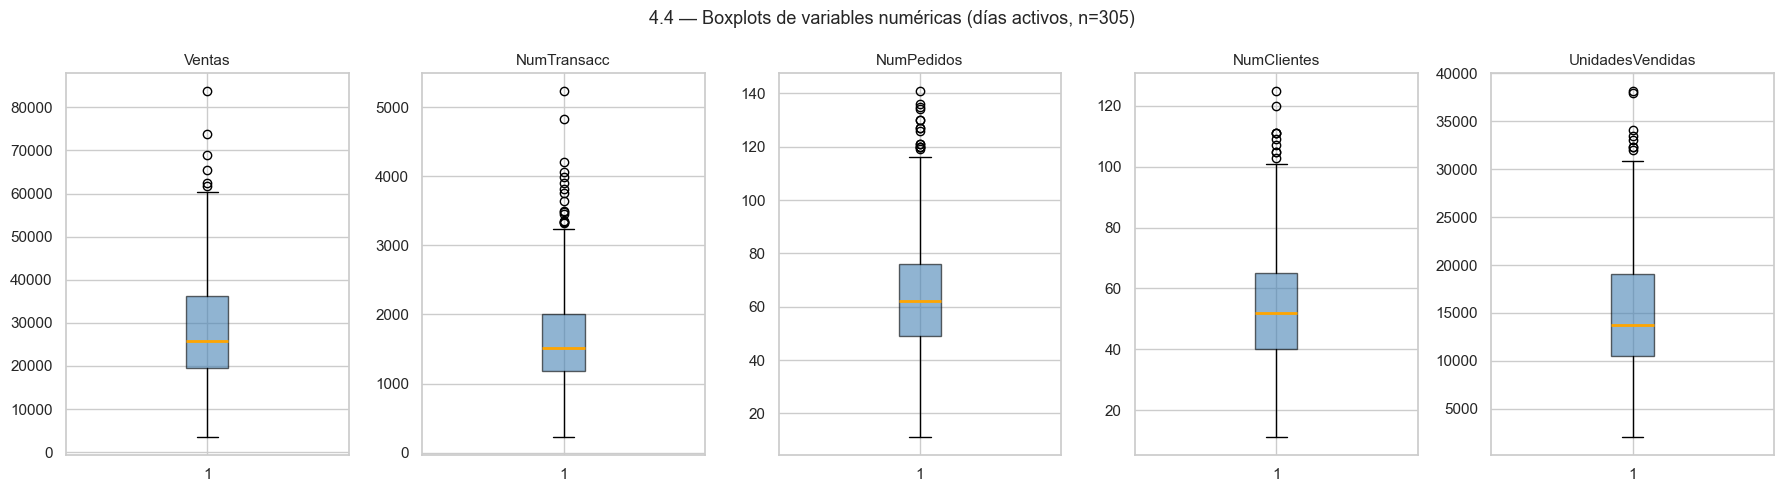

In [332]:
# ── 4.4.2  Boxplots de variables numéricas ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols_numericas):
    axes[i].boxplot(df_activos[col].values, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='orange', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')
fig.suptitle('4.4 — Boxplots de variables numéricas (días activos, n=305)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.4_boxplots_variables_diarias.png', dpi=150)
plt.show()

In [333]:
# ── 4.4.3  Verificar rangos de variables temporales ─────────────────────────
print("\n  -- 4.4.3 Verificación de rangos en variables temporales --")
rangos_esperados = {
    'DiaSemana':     (0, 6),
    'EsFinDeSemana': (0, 1),
    'Mes':           (1, 12),
    'Trimestre':     (1, 4),
    'SemanaMes':     (1, 5),
    'DiaAnio':       (1, 366),
    'SemanaAnio':    (1, 53),
}
todo_ok = True
for col, (min_esp, max_esp) in rangos_esperados.items():
    min_real = int(df_daily[col].min())
    max_real = int(df_daily[col].max())
    ok = min_real >= min_esp and max_real <= max_esp
    estado = '✓' if ok else '✗ FUERA DE RANGO'
    if not ok:
        todo_ok = False
    print(f"  {col:<16}: esperado [{min_esp:>3}, {max_esp:>3}]  →  real [{min_real:>3}, {max_real:>3}]  {estado}")
print(f"\n  {'✓ Todas las variables temporales dentro de rango esperado.' if todo_ok else '✗ Revisar columnas marcadas.'}")


  -- 4.4.3 Verificación de rangos en variables temporales --
  DiaSemana       : esperado [  0,   6]  →  real [  0,   6]  ✓
  EsFinDeSemana   : esperado [  0,   1]  →  real [  0,   1]  ✓
  Mes             : esperado [  1,  12]  →  real [  1,  12]  ✓
  Trimestre       : esperado [  1,   4]  →  real [  1,   4]  ✓
  SemanaMes       : esperado [  1,   5]  →  real [  1,   5]  ✓
  DiaAnio         : esperado [  1, 366]  →  real [  1, 365]  ✓
  SemanaAnio      : esperado [  1,  53]  →  real [  1,  52]  ✓

  ✓ Todas las variables temporales dentro de rango esperado.


In [334]:
# ── 4.4.4  Análisis de variables categóricas ────────────────────────────────
print("\n  -- 4.4.4 Análisis de variables categóricas --")

print("\n  ProductoTopDia — top 15 más frecuentes:")
freq_prod  = df_daily['ProductoTopDia'].value_counts()
raros_prod = freq_prod[(freq_prod <= 2) & (freq_prod.index != 'Sin_Actividad')]
print(freq_prod.head(15).to_string())
print(f"\n  Productos únicos (excl. Sin_Actividad): "
      f"{(freq_prod.index != 'Sin_Actividad').sum()}")
print(f"  Productos con ≤2 apariciones (raros): {len(raros_prod)}")
if len(raros_prod) > 0:
    print(f"  → Productos raros: {raros_prod.index.tolist()}")

print("\n  PaisTopDia — distribución completa:")
print(df_daily['PaisTopDia'].value_counts().to_string())
n_uk      = (df_daily['PaisTopDia'] == 'United Kingdom').sum()
n_activos = (df_daily['Ventas'] > 0).sum()
print(f"\n  'United Kingdom' domina {n_uk}/{n_activos} días activos "
      f"({n_uk/n_activos*100:.1f}%) → varianza prácticamente nula → se eliminará en 4.6")


  -- 4.4.4 Análisis de variables categóricas --

  ProductoTopDia — top 15 más frecuentes:
ProductoTopDia
Sin_Actividad    69
85099B           40
23084            26
22197            22
84077            14
85123A           13
84879            10
21212            10
23203             8
47566             7
22086             5
71459             5
22178             5
22834             4
20725             4

  Productos únicos (excl. Sin_Actividad): 109
  Productos con ≤2 apariciones (raros): 89
  → Productos raros: ['21080', '23199', '22386', '21985', '85099F', '84991', '22355', '84946', '17003', '22659', '22740', '23209', '84978', '16259', '22961', '22151', '22469', '22952', '21181', '22065', '23310', '16045', '75049L', '84826', '70006', '85099C', '20718', '22741', '22855', '22616', '21731', '21498', '21878', '22969', '20719', '21918', '22908', '21231', '72741', '22189', '21326', '22326', '82581', '20717', '22867', '21844', '17012C', '22791', '23077', '22436', '23206', '22999', '22294', 

In [335]:
# ── 4.4.5  Decisión y conclusión ────────────────────────────────────────────
print("\n  -- 4.4.5 Decisión sobre tratamiento de outliers --")
print("""
  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene 374 filas (305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
      temporal que el modelo debe aprender.
    → Las ventanas rolling (4.8) y lags (4.7) incorporarán el contexto
      histórico y suavizarán la señal para el modelo.
""")
print(f"  ✓ df_daily sin cambios estructurales: {len(df_daily)} filas, "
      f"{len(df_daily.columns)} columnas.")



  -- 4.4.5 Decisión sobre tratamiento de outliers --

  Análisis realizado:
    · Los outliers en 'Ventas' y métricas de volumen corresponden a días
      de alta actividad real (pico pre-navideño, Black Friday 2011).
      No son errores de datos: el dataset de e-commerce tiene marcada
      estacionalidad en el Q4 (octubre–diciembre).
    · df_daily solo tiene 374 filas (305 activos) → eliminar filas
      empeoraría el modelo por pérdida de información crítica.
    · Capear 'Ventas' eliminaría la señal estacional que el modelo
      debe aprender a predecir.
    · Las variables de volumen (NumTransacc, NumPedidos, etc.) son
      proporcionales a Ventas; capear unas y no otras produce
      inconsistencias internas.
    · Las variables temporales están dentro de sus rangos esperados.
    · 'PaisTopDia' se marcará para eliminación en 4.6 (varianza ≈ 0).

  Decisión: NO se aplica capping ni eliminación en df_daily.
    → Los outliers son eventos reales que forman parte del patrón
   

### 4.6 ANÁLISIS DE CORRELACIÓN Y SELECCIÓN DE VARIABLES

In [336]:
print("\n\n--- 4.6 Análisis de correlación y selección de variables ---")
print("\n  -- 4.6.1 Correlación de Pearson con 'Ventas' (variables numéricas) --")
print("  Nota: se usan los 374 días completos (incluye ceros de días inactivos)\n")

cols_correlacion = [
    'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas',
    'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre',
    'SemanaMes', 'DiaAnio', 'SemanaAnio'
]

correlaciones = (
    df_daily[cols_correlacion + ['Ventas']]
    .corr()['Ventas']
    .drop('Ventas')
    .sort_values(key=abs, ascending=False)
)

print(f"  {'Variable':<20} {'Correlación':>12}  {'Interpretación'}")
print(f"  {'-'*60}")
for var, corr in correlaciones.items():
    if abs(corr) >= 0.5:
        nivel = 'Alta'
    elif abs(corr) >= 0.3:
        nivel = 'Moderada'
    elif abs(corr) >= 0.1:
        nivel = 'Baja'
    else:
        nivel = 'Muy baja / irrelevante'
    print(f"  {var:<20} {corr:>12.4f}  {nivel}")



--- 4.6 Análisis de correlación y selección de variables ---

  -- 4.6.1 Correlación de Pearson con 'Ventas' (variables numéricas) --
  Nota: se usan los 374 días completos (incluye ceros de días inactivos)

  Variable              Correlación  Interpretación
  ------------------------------------------------------------
  UnidadesVendidas           0.9731  Alta
  NumPedidos                 0.9113  Alta
  NumTransacc                0.9070  Alta
  NumClientes                0.8924  Alta
  EsFinDeSemana             -0.6079  Alta
  DiaSemana                 -0.4583  Moderada
  Mes                        0.3500  Moderada
  DiaAnio                    0.3434  Moderada
  Trimestre                  0.3408  Moderada
  SemanaAnio                 0.3272  Moderada
  SemanaMes                 -0.0972  Muy baja / irrelevante


In [337]:
# ── 4.6.2  Correlación de Spearman (más robusta ante outliers) ───────────────
print("\n  -- 4.6.2 Correlación de Spearman con 'Ventas' (más robusta ante outliers) --\n")

correlaciones_sp = (
    df_daily[cols_correlacion + ['Ventas']]
    .corr(method='spearman')['Ventas']
    .drop('Ventas')
    .sort_values(key=abs, ascending=False)
)

print(f"  {'Variable':<20} {'Pearson':>10} {'Spearman':>10}  {'Δ (abs)':>8}")
print(f"  {'-'*55}")
for var in correlaciones_sp.index:
    p  = correlaciones[var]   if var in correlaciones.index   else float('nan')
    sp = correlaciones_sp[var]
    print(f"  {var:<20} {p:>10.4f} {sp:>10.4f}  {abs(abs(sp)-abs(p)):>8.4f}")


  -- 4.6.2 Correlación de Spearman con 'Ventas' (más robusta ante outliers) --

  Variable                Pearson   Spearman   Δ (abs)
  -------------------------------------------------------
  UnidadesVendidas         0.9731     0.9747    0.0017
  NumTransacc              0.9070     0.9165    0.0095
  NumPedidos               0.9113     0.9117    0.0004
  NumClientes              0.8924     0.8780    0.0144
  EsFinDeSemana           -0.6079    -0.6210    0.0131
  DiaSemana               -0.4583    -0.4636    0.0054
  Mes                      0.3500     0.3343    0.0157
  Trimestre                0.3408     0.3284    0.0124
  DiaAnio                  0.3434     0.3256    0.0178
  SemanaAnio               0.3272     0.3086    0.0187
  SemanaMes               -0.0972    -0.0926    0.0046


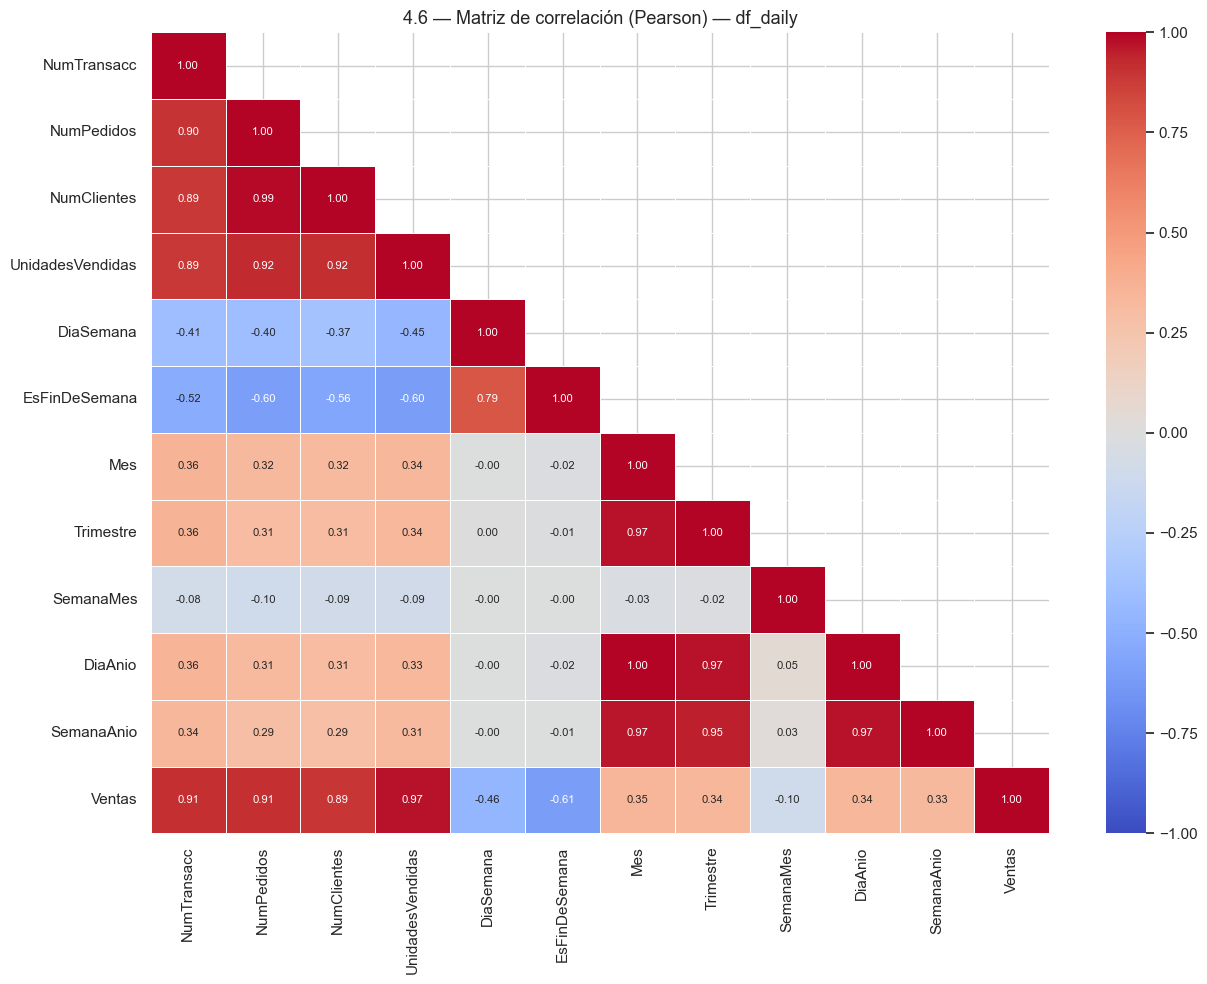

In [338]:
# ── 4.6.3  Heatmap de correlaciones ─────────────────────────────────────────
cols_heatmap = cols_correlacion + ['Ventas']
corr_matrix  = df_daily[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mascara,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('4.6 — Matriz de correlación (Pearson) — df_daily', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.6_correlacion_heatmap.png', dpi=150)
plt.show()


In [339]:

# ── 4.6.4  Análisis de variables categóricas vs Ventas ───────────────────────
print("\n  -- 4.6.4 Varianza de PaisTopDia y ProductoTopDia vs Ventas --")

# PaisTopDia — varianza prácticamente nula (UK 305/305)
var_pais = df_daily['PaisTopDia'].nunique()
print(f"\n  PaisTopDia: {var_pais} valores únicos → varianza ≈ 0 → candidata a eliminar")

# ProductoTopDia — medias de Ventas por categoría top-10
print(f"\n  Ventas media por ProductoTopDia (top 10 más frecuentes):")
media_prod = (
    df_daily[df_daily['ProductoTopDia'] != 'Sin_Actividad']
    .groupby('ProductoTopDia')['Ventas']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(10)
    .rename(columns={'mean': 'Ventas_Media', 'count': 'N_dias'})
)
print(media_prod.to_string())


  -- 4.6.4 Varianza de PaisTopDia y ProductoTopDia vs Ventas --

  PaisTopDia: 2 valores únicos → varianza ≈ 0 → candidata a eliminar

  Ventas media por ProductoTopDia (top 10 más frecuentes):
                Ventas_Media  N_dias
ProductoTopDia                      
85099B          31175.168000      40
23084           45213.071538      26
22197           33804.668182      22
84077           26300.276429      14
85123A          24534.373846      13
21212           32450.031000      10
84879           25302.367000      10
23203           26905.358750       8
47566           28899.161429       7
71459           22115.026000       5


In [340]:
# ── 4.6.5  Multicolinealidad entre variables de volumen ──────────────────────
print("\n  -- 4.6.5 Multicolinealidad entre variables de volumen --")
cols_volumen = ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas']
corr_vol = df_daily[cols_volumen].corr().round(3)
print(f"\n  Matriz de correlación entre variables de volumen:")
print(corr_vol.to_string())
print(f"\n  Nota: correlaciones muy altas (>0.95) indican redundancia.")


  -- 4.6.5 Multicolinealidad entre variables de volumen --

  Matriz de correlación entre variables de volumen:
                  NumTransacc  NumPedidos  NumClientes  UnidadesVendidas
NumTransacc             1.000       0.901        0.890             0.889
NumPedidos              0.901       1.000        0.989             0.925
NumClientes             0.890       0.989        1.000             0.919
UnidadesVendidas        0.889       0.925        0.919             1.000

  Nota: correlaciones muy altas (>0.95) indican redundancia.


In [341]:
# ── 4.6.6  Decisión y variables descartadas ──────────────────────────────────
print("\n  -- 4.6.6 Decisión de selección de variables --")

VARS_ELIMINAR = ['PaisTopDia']

print(f"""
  Variables ELIMINADAS de df_daily:
    · PaisTopDia        → UK 305/305 días activos (100%); varianza ≈ 0;
                          no aporta información al modelo.

  Variables CONSERVADAS con observaciones:
    · NumTransacc, NumPedidos, NumClientes, UnidadesVendidas
                        → Alta correlación con Ventas. Son redundantes entre sí
                          (multicolinealidad alta), pero se conservan todas ahora
                          y se dejará que los modelos con regularización (Ridge,
                          Lasso) las gestionen en la fase de modelado.
    · DiaAnio, SemanaAnio, Mes, Trimestre
                        → Capturan la tendencia y estacionalidad anual.
    · DiaSemana, EsFinDeSemana
                        → Capturan el patrón semanal (fines de semana = 0 ventas).
    · SemanaMes         → Correlación baja; se conserva por si aporta
                          señal en combinación con otras variables.
    · ProductoTopDia    → Se conserva; el encoding se hará en el bloque
                          de codificación (agrupando raros en 'Otros').
""")

df_daily = df_daily.drop(columns=VARS_ELIMINAR)

print(f"  Columnas finales en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"\n  ✓ Selección de variables completada. df_daily listo para lags y rolling windows.")


  -- 4.6.6 Decisión de selección de variables --

  Variables ELIMINADAS de df_daily:
    · PaisTopDia        → UK 305/305 días activos (100%); varianza ≈ 0;
                          no aporta información al modelo.

  Variables CONSERVADAS con observaciones:
    · NumTransacc, NumPedidos, NumClientes, UnidadesVendidas
                        → Alta correlación con Ventas. Son redundantes entre sí
                          (multicolinealidad alta), pero se conservan todas ahora
                          y se dejará que los modelos con regularización (Ridge,
                          Lasso) las gestionen en la fase de modelado.
    · DiaAnio, SemanaAnio, Mes, Trimestre
                        → Capturan la tendencia y estacionalidad anual.
    · DiaSemana, EsFinDeSemana
                        → Capturan el patrón semanal (fines de semana = 0 ventas).
    · SemanaMes         → Correlación baja; se conserva por si aporta
                          señal en combinación con otras variable

### 4.7  LAGS (RETRASOS TEMPORALES)

In [342]:
print("\n\n--- 4.7 Lags (retrasos temporales) ---")

df_daily['Ventas_Lag1'] = df_daily['Ventas'].shift(1)
df_daily['Ventas_Lag7'] = df_daily['Ventas'].shift(7)

n_nan_lag1 = df_daily['Ventas_Lag1'].isna().sum()
n_nan_lag7 = df_daily['Ventas_Lag7'].isna().sum()

print(f"\n  Lag1 — NaN generados: {n_nan_lag1}  (fila 0: sin día anterior)")
print(f"  Lag7 — NaN generados: {n_nan_lag7}  (filas 0–6: sin semana anterior)")

print(f"\n  Primeras 10 filas con lags (observar NaN iniciales):")
cols_lag = ['Fecha', 'Ventas', 'Ventas_Lag1', 'Ventas_Lag7']
print(df_daily[cols_lag].head(10).to_string(index=False))

# ── 4.7.3  Eliminar filas con NaN (las primeras 7) ───────────────────────────
filas_antes = len(df_daily)
df_daily = df_daily.dropna(subset=['Ventas_Lag1', 'Ventas_Lag7']).reset_index(drop=True)
filas_despues = len(df_daily)

print(f"\n  Filas antes de dropna: {filas_antes}")
print(f"  Filas eliminadas:      {filas_antes - filas_despues}  "
      f"({df_daily['Fecha'].min().date()} es ahora la primera fila)")
print(f"  Filas tras dropna:     {filas_despues}")



--- 4.7 Lags (retrasos temporales) ---

  Lag1 — NaN generados: 1  (fila 0: sin día anterior)
  Lag7 — NaN generados: 7  (filas 0–6: sin semana anterior)

  Primeras 10 filas con lags (observar NaN iniciales):
     Fecha   Ventas  Ventas_Lag1  Ventas_Lag7
2010-12-01 51005.57          NaN          NaN
2010-12-02 40635.29     51005.57          NaN
2010-12-03 41703.67     40635.29          NaN
2010-12-04     0.00     41703.67          NaN
2010-12-05 29561.39         0.00          NaN
2010-12-06 47475.08     29561.39          NaN
2010-12-07 57620.88     47475.08          NaN
2010-12-08 40923.74     57620.88     51005.57
2010-12-09 43298.67     40923.74     40635.29
2010-12-10 50687.25     43298.67     41703.67

  Filas antes de dropna: 374
  Filas eliminadas:      7  (2010-12-08 es ahora la primera fila)
  Filas tras dropna:     367


In [343]:
# ── 4.7.4  Validación de los valores de lag ──────────────────────────────────
print(f"\n  Validación — muestra aleatoria de consistencia (Ventas_Lag1):")
idx_check = [10, 20, 50]
for i in idx_check:
    fecha_actual  = df_daily.loc[i, 'Fecha']
    ventas_actual = df_daily.loc[i, 'Ventas']
    lag1_almac    = df_daily.loc[i, 'Ventas_Lag1']
    ventas_ayer   = df_daily.loc[i - 1, 'Ventas']
    ok = '✓' if abs(lag1_almac - ventas_ayer) < 0.01 else '✗'
    print(f"  [{i}] {fecha_actual.date()}  Ventas={ventas_actual:>10,.2f} "
          f" Lag1={lag1_almac:>10,.2f}  Ventas[i-1]={ventas_ayer:>10,.2f}  {ok}")

print(f"\n  Estadísticas de los lags:")
print(df_daily[['Ventas_Lag1', 'Ventas_Lag7']].describe()
      .map(lambda x: f"{x:>12,.2f}").to_string())

print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"\n  ✓ Lags añadidos. df_daily: {len(df_daily)} filas.")


  Validación — muestra aleatoria de consistencia (Ventas_Lag1):
  [10] 2010-12-18  Ventas=      0.00  Lag1= 38,142.45  Ventas[i-1]= 38,142.45  ✓
  [20] 2010-12-28  Ventas=      0.00  Lag1=      0.00  Ventas[i-1]=      0.00  ✓
  [50] 2011-01-27  Ventas= 22,073.68  Lag1= 17,735.81  Ventas[i-1]= 17,735.81  ✓

  Estadísticas de los lags:
        Ventas_Lag1   Ventas_Lag7
count        367.00        367.00
mean      23,078.73     22,921.58
std       16,649.07     16,312.14
min            0.00          0.00
25%       10,920.08     10,920.08
50%       22,592.35     22,592.35
75%       32,491.57     32,491.57
max       83,872.12     83,872.12

  Columnas en df_daily (16 total):
  ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7']

  ✓ Lags añadidos. df_daily: 367 filas.


###  4.8  MEDIAS MÓVILES

In [344]:
print("\n\n--- 4.8 Medias móviles (rolling windows) ---")

df_daily['Ventas_Media_7d']  = (
    df_daily['Ventas'].rolling(window=7,  min_periods=1).mean()
)
df_daily['Ventas_Media_30d'] = (
    df_daily['Ventas'].rolling(window=30, min_periods=1).mean()
)

# ── 4.8.2  Verificación de NaN ───────────────────────────────────────────────
n_nan_7d  = df_daily['Ventas_Media_7d'].isna().sum()
n_nan_30d = df_daily['Ventas_Media_30d'].isna().sum()
print(f"\n  NaN en Ventas_Media_7d:  {n_nan_7d}   (esperado: 0 con min_periods=1)")
print(f"  NaN en Ventas_Media_30d: {n_nan_30d}  (esperado: 0 con min_periods=1)")



--- 4.8 Medias móviles (rolling windows) ---

  NaN en Ventas_Media_7d:  0   (esperado: 0 con min_periods=1)
  NaN en Ventas_Media_30d: 0  (esperado: 0 con min_periods=1)


In [345]:
# ── 4.8.3  Primeras filas para inspección visual ─────────────────────────────
print(f"\n  Primeras 12 filas con medias móviles:")
cols_roll = ['Fecha', 'Ventas', 'Ventas_Media_7d', 'Ventas_Media_30d']
print(df_daily[cols_roll].head(12).to_string(index=False))


  Primeras 12 filas con medias móviles:
     Fecha   Ventas  Ventas_Media_7d  Ventas_Media_30d
2010-12-08 40923.74     40923.740000      40923.740000
2010-12-09 43298.67     42111.205000      42111.205000
2010-12-10 50687.25     44969.886667      44969.886667
2010-12-11     0.00     33727.415000      33727.415000
2010-12-12 16739.80     30329.892000      30329.892000
2010-12-13 34626.06     31045.920000      31045.920000
2010-12-14 40153.95     32347.067143      32347.067143
2010-12-15 26630.96     30305.241429      31632.553750
2010-12-16 38387.52     29603.648571      32383.105556
2010-12-17 38142.45     27811.534286      32959.040000
2010-12-18     0.00     27811.534286      29962.763636
2010-12-19  7034.15     26425.012857      28052.045833


In [346]:
# ── 4.8.4  Validación manual de Ventas_Media_7d ──────────────────────────────
# La fila con índice 7 (8ª fila) debe tener Media_7d = media de las filas 1-7
print(f"\n  Validación manual de Ventas_Media_7d en fila 7:")
media_manual = df_daily.loc[1:7, 'Ventas'].mean()
media_stored = df_daily.loc[7, 'Ventas_Media_7d']
ok = '✓' if abs(media_manual - media_stored) < 0.01 else '✗'
print(f"  Media manual filas 1–7: {media_manual:>12,.2f}")
print(f"  Valor almacenado [7]:   {media_stored:>12,.2f}  {ok}")


  Validación manual de Ventas_Media_7d en fila 7:
  Media manual filas 1–7:    30,305.24
  Valor almacenado [7]:      30,305.24  ✓


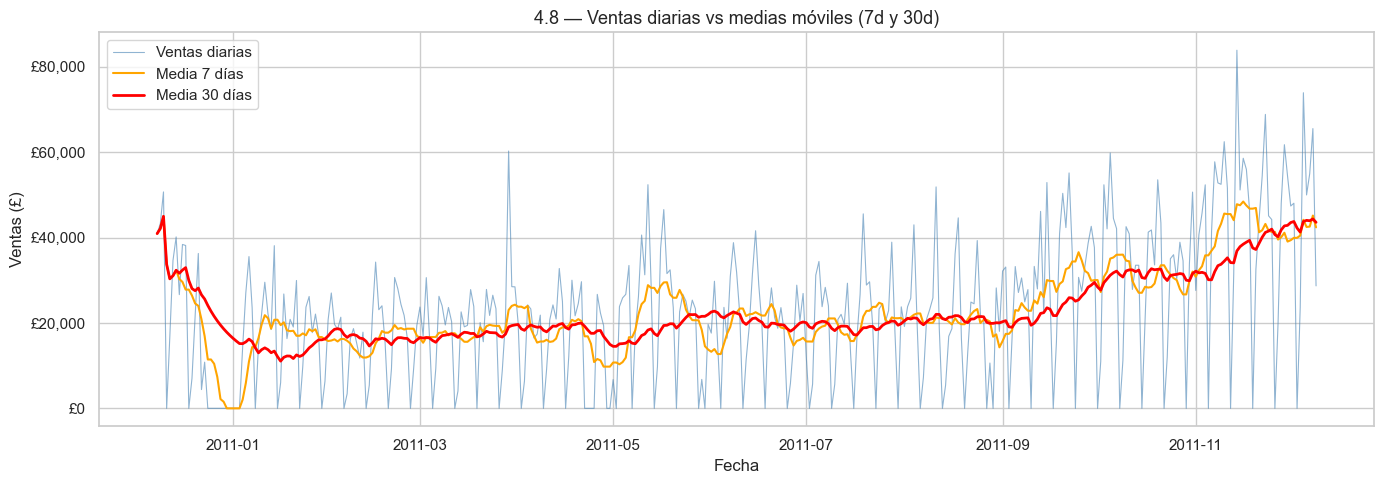

In [347]:
# ── 4.8.5  Gráfica: Ventas vs medias móviles ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_daily['Fecha'], df_daily['Ventas'],
        color='steelblue', linewidth=0.8, alpha=0.6, label='Ventas diarias')
ax.plot(df_daily['Fecha'], df_daily['Ventas_Media_7d'],
        color='orange', linewidth=1.5, label='Media 7 días')
ax.plot(df_daily['Fecha'], df_daily['Ventas_Media_30d'],
        color='red', linewidth=2.0, label='Media 30 días')
ax.set_title('4.8 — Ventas diarias vs medias móviles (7d y 30d)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}4.8_medias_moviles.png', dpi=150)
plt.show()

In [348]:
# ── 4.8.6  Estadísticas de las medias móviles ────────────────────────────────
print(f"\n  Estadísticas de las medias móviles:")
print(df_daily[['Ventas_Media_7d', 'Ventas_Media_30d']].describe()
      .map(lambda x: f"{x:>12,.2f}").to_string())

print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"\n  ✓ Medias móviles añadidas. df_daily: {len(df_daily)} filas.")


  Estadísticas de las medias móviles:
      Ventas_Media_7d Ventas_Media_30d
count          367.00           367.00
mean        22,917.28        22,492.97
std          9,427.42         7,629.37
min              0.00        11,060.00
25%         16,871.22        17,451.80
50%         20,731.57        19,903.04
75%         28,251.31        25,715.37
max         48,435.03        44,969.89

  Columnas en df_daily (18 total):
  ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d']

  ✓ Medias móviles añadidas. df_daily: 367 filas.


### 4.9  EVENTOS ESPECIALES

In [349]:
print("\n--- 4.9 Eventos especiales ---\n")

df_daily['Es_Navidad'] = (
    (df_daily['Fecha'].dt.month == 12) &
    (df_daily['Fecha'].dt.day.between(20, 25))
).astype(int)

dias_navidad = df_daily['Es_Navidad'].sum()
print(f"  Es_Navidad — días marcados: {dias_navidad}")
print(df_daily.loc[df_daily['Es_Navidad'] == 1, ['Fecha', 'Ventas', 'Es_Navidad']].to_string(index=False))

NAV_VENTANA = 30

def dias_para_navidad(fecha):
    navidad = pd.Timestamp(fecha.year, 12, 25)
    delta = (navidad - fecha).days
    if 0 < delta <= NAV_VENTANA:
        return delta
    return 0

df_daily['Dias_para_Navidad'] = df_daily['Fecha'].apply(dias_para_navidad)

print(f"\n  Dias_para_Navidad — distribución de valores > 0:")
print(df_daily.loc[df_daily['Dias_para_Navidad'] > 0,
                   ['Fecha', 'Ventas', 'Dias_para_Navidad']]
      .sort_values('Fecha').to_string(index=False))


--- 4.9 Eventos especiales ---

  Es_Navidad — días marcados: 6
     Fecha   Ventas  Es_Navidad
2010-12-20 21587.32           1
2010-12-21 36274.57           1
2010-12-22  4394.97           1
2010-12-23 10815.62           1
2010-12-24     0.00           1
2010-12-25     0.00           1

  Dias_para_Navidad — distribución de valores > 0:
     Fecha   Ventas  Dias_para_Navidad
2010-12-08 40923.74                 17
2010-12-09 43298.67                 16
2010-12-10 50687.25                 15
2010-12-11     0.00                 14
2010-12-12 16739.80                 13
2010-12-13 34626.06                 12
2010-12-14 40153.95                 11
2010-12-15 26630.96                 10
2010-12-16 38387.52                  9
2010-12-17 38142.45                  8
2010-12-18     0.00                  7
2010-12-19  7034.15                  6
2010-12-20 21587.32                  5
2010-12-21 36274.57                  4
2010-12-22  4394.97                  3
2010-12-23 10815.62                

In [350]:
# ── 4.9.3  Verificación de rangos ─────────────────────────────────────────────
assert df_daily['Es_Navidad'].isin([0, 1]).all(), "ERROR: Es_Navidad contiene valores fuera de {0,1}"
assert df_daily['Dias_para_Navidad'].between(0, NAV_VENTANA).all(), \
    f"ERROR: Dias_para_Navidad fuera del rango [0, {NAV_VENTANA}]"
print(f"\n  Verificación de rangos:")
print(f"  Es_Navidad         : valores únicos → {sorted(df_daily['Es_Navidad'].unique())}  ✓")
print(f"  Dias_para_Navidad  : rango [{df_daily['Dias_para_Navidad'].min()}, "
      f"{df_daily['Dias_para_Navidad'].max()}]  (esperado [0, {NAV_VENTANA}])  ✓")


  Verificación de rangos:
  Es_Navidad         : valores únicos → [np.int64(0), np.int64(1)]  ✓
  Dias_para_Navidad  : rango [0, 30]  (esperado [0, 30])  ✓


In [351]:
# ── 4.9.4  Resumen final de df_daily ──────────────────────────────────────────
print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"  Filas: {len(df_daily)}")



  Columnas en df_daily (20 total):
  ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad']
  Filas: 367


In [352]:
# ── 4.9.5  Guardar df_daily a CSV ─────────────────────────────────────────────
RUTA_DAILY_CSV = 'contenidoCSV/data_daily.csv'
df_daily.to_csv(RUTA_DAILY_CSV, index=False)
print(f"\n  ✓ df_daily guardado en: {RUTA_DAILY_CSV}")
print(f"    Filas:    {len(df_daily)}")
print(f"    Columnas: {len(df_daily.columns)}")
print(f"    Columnas: {list(df_daily.columns)}")

print("\n  ✓ Sección 4 (Transformación) completada.")


  ✓ df_daily guardado en: contenidoCSV/data_daily.csv
    Filas:    367
    Columnas: 20
    Columnas: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'DiaSemana', 'EsFinDeSemana', 'Mes', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad']

  ✓ Sección 4 (Transformación) completada.


# 5.  ENCODING DE VARIABLES CATEGÓRICAS 

### 5.1  INVENTARIO DE COLUMNAS — CLASIFICACIÓN POR TIPO DE ENCODING   

In [353]:
print("\n\n=== 5. ENCODING DE VARIABLES CATEGÓRICAS ===")
print("\n--- 5.1 Inventario: clasificación por tipo de encoding ---\n")

cols_numericas = [
    'Ventas',            # variable objetivo — sin cambio
    'NumTransacc',       # volumen — numérica continua
    'NumPedidos',        # volumen — numérica continua
    'NumClientes',       # volumen — numérica continua
    'UnidadesVendidas',  # volumen — numérica continua
    'Trimestre',         # ordinal numérica (1–4)
    'SemanaMes',         # ordinal numérica (1–5)
    'DiaAnio',           # ordinal numérica (1–365)
    'SemanaAnio',        # ordinal numérica (1–52)
    'EsFinDeSemana',     # binaria (0/1) — ya codificada
    'Es_Navidad',        # binaria (0/1) — ya codificada
    'Dias_para_Navidad', # numérica discreta (0–30)
    'Ventas_Lag1',       # lag numérico
    'Ventas_Lag7',       # lag numérico
    'Ventas_Media_7d',   # rolling numérico
    'Ventas_Media_30d',  # rolling numérico
]

cols_ciclicas = {
    'DiaSemana': 7,   # período 7  → sin/cos
    'Mes':       12,  # período 12 → sin/cos
}

cols_ohe = [
    'ProductoTopDia',  # nominal, ~22 cats tras agrupar raros
]



=== 5. ENCODING DE VARIABLES CATEGÓRICAS ===

--- 5.1 Inventario: clasificación por tipo de encoding ---



In [354]:
# ── Verificación: todas las columnas de df_daily (excl. Fecha) clasificadas ───
cols_clasificadas = set(cols_numericas) | set(cols_ciclicas.keys()) | set(cols_ohe)
cols_df = set(df_daily.columns) - {'Fecha'}
cols_sin_clasificar = cols_df - cols_clasificadas
cols_extra = cols_clasificadas - cols_df

print("  COLUMNAS NUMÉRICAS (sin cambio):")
for c in cols_numericas:
    print(f"    · {c:<22} dtype={df_daily[c].dtype}")

print("\n  COLUMNAS CÍCLICAS (→ sin/cos):")
for c, periodo in cols_ciclicas.items():
    rango = f"[{df_daily[c].min():.0f}, {df_daily[c].max():.0f}]"
    print(f"    · {c:<22} período={periodo}  rango={rango}")

print("\n  COLUMNAS NOMINALES (→ OHE):")
for c in cols_ohe:
    n_cats = df_daily[c].nunique()
    print(f"    · {c:<22} categorías únicas={n_cats}")

if cols_sin_clasificar:
    print(f"\n  ⚠ Columnas sin clasificar: {cols_sin_clasificar}")
else:
    print("\n  ✓ Todas las columnas clasificadas correctamente.")

if cols_extra:
    print(f"  ⚠ Columnas en clasificación no presentes en df_daily: {cols_extra}")

print(f"\n  Resumen:")
print(f"    Numéricas (sin cambio) : {len(cols_numericas)}")
print(f"    Cíclicas  (sin/cos)    : {len(cols_ciclicas)}")
print(f"    Nominales (OHE)        : {len(cols_ohe)}")
print(f"    Fecha                  :  1  (índice temporal — no se codifica)")
print(f"    Total columnas df_daily: {len(df_daily.columns)}")
print("\n  ✓ Inventario completado. Listo para 5.2 (prueba sklearn).")

  COLUMNAS NUMÉRICAS (sin cambio):
    · Ventas                 dtype=float64
    · NumTransacc            dtype=float64
    · NumPedidos             dtype=float64
    · NumClientes            dtype=float64
    · UnidadesVendidas       dtype=float64
    · Trimestre              dtype=int32
    · SemanaMes              dtype=int64
    · DiaAnio                dtype=int32
    · SemanaAnio             dtype=int64
    · EsFinDeSemana          dtype=int64
    · Es_Navidad             dtype=int64
    · Dias_para_Navidad      dtype=int64
    · Ventas_Lag1            dtype=float64
    · Ventas_Lag7            dtype=float64
    · Ventas_Media_7d        dtype=float64
    · Ventas_Media_30d       dtype=float64

  COLUMNAS CÍCLICAS (→ sin/cos):
    · DiaSemana              período=7  rango=[0, 6]
    · Mes                    período=12  rango=[1, 12]

  COLUMNAS NOMINALES (→ OHE):
    · ProductoTopDia         categorías únicas=109

  ✓ Todas las columnas clasificadas correctamente.

  Resumen:
   

### 5.2  PRUEBA SKLEARN: LabelEncoder vs OHE vs Cíclico en DiaSemana

In [355]:
print("\n--- 5.2 Prueba sklearn: LabelEncoder vs OHE vs Cíclico en DiaSemana ---\n")

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

diasemana_vals = df_daily[['DiaSemana']].copy().reset_index(drop=True)


--- 5.2 Prueba sklearn: LabelEncoder vs OHE vs Cíclico en DiaSemana ---



In [356]:
# ── 5.2.1  LabelEncoder ───────────────────────────────────────────────────────
le = LabelEncoder()
diasemana_vals['LE'] = le.fit_transform(diasemana_vals['DiaSemana'])

print("  5.2.1  LabelEncoder:")
print("  Asigna un entero a cada categoría — mantiene el orden original.")
print(f"  Clases: {list(le.classes_)}  →  valores: {list(range(len(le.classes_)))}")
print("  Problema: implica orden numérico (0<1<2...) y distancias falsas.")
print("  Ejemplo: Lun(0) - Dom(6) = 6, pero realmente son días adyacentes.\n")

  5.2.1  LabelEncoder:
  Asigna un entero a cada categoría — mantiene el orden original.
  Clases: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]  →  valores: [0, 1, 2, 3, 4, 5, 6]
  Problema: implica orden numérico (0<1<2...) y distancias falsas.
  Ejemplo: Lun(0) - Dom(6) = 6, pero realmente son días adyacentes.



In [357]:
# ── 5.2.2  OneHotEncoder ──────────────────────────────────────────────────────
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_array = ohe.fit_transform(diasemana_vals[['DiaSemana']])
ohe_cols = [f'DiaSemana_OHE_{int(c)}' for c in ohe.categories_[0][1:]]

print("  5.2.2  OneHotEncoder (drop='first'):")
print(f"  Genera {len(ohe_cols)} columnas binarias — elimina orden falso.")
print(f"  Columnas: {ohe_cols}")
print("  Problema: no captura la CONTINUIDAD cíclica.")
print("  Dom(6) y Lun(0) son días consecutivos pero el modelo los ve como lejanos.\n")

  5.2.2  OneHotEncoder (drop='first'):
  Genera 6 columnas binarias — elimina orden falso.
  Columnas: ['DiaSemana_OHE_1', 'DiaSemana_OHE_2', 'DiaSemana_OHE_3', 'DiaSemana_OHE_4', 'DiaSemana_OHE_5', 'DiaSemana_OHE_6']
  Problema: no captura la CONTINUIDAD cíclica.
  Dom(6) y Lun(0) son días consecutivos pero el modelo los ve como lejanos.



In [358]:
# ── 5.2.3  Codificación cíclica (sin/cos) ────────────────────────────────────
periodo = 7
diasemana_vals['DiaSemana_sin'] = np.sin(2 * np.pi * diasemana_vals['DiaSemana'] / periodo)
diasemana_vals['DiaSemana_cos'] = np.cos(2 * np.pi * diasemana_vals['DiaSemana'] / periodo)

print("  5.2.3  Codificación cíclica (sin/cos):")
print(f"  Fórmula: sin(2π·DiaSemana/7) y cos(2π·DiaSemana/7)")
print()
print(f"  {'DiaSemana':<12} {'sin':>8} {'cos':>8}  Nombre")
dias_nombres = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves',
                4:'Viernes', 5:'Sábado', 6:'Domingo'}
for d in range(7):
    s = np.sin(2 * np.pi * d / periodo)
    c = np.cos(2 * np.pi * d / periodo)
    print(f"  {d:<12} {s:>8.4f} {c:>8.4f}  {dias_nombres[d]}")

  5.2.3  Codificación cíclica (sin/cos):
  Fórmula: sin(2π·DiaSemana/7) y cos(2π·DiaSemana/7)

  DiaSemana         sin      cos  Nombre
  0              0.0000   1.0000  Lunes
  1              0.7818   0.6235  Martes
  2              0.9749  -0.2225  Miércoles
  3              0.4339  -0.9010  Jueves
  4             -0.4339  -0.9010  Viernes
  5             -0.9749  -0.2225  Sábado
  6             -0.7818   0.6235  Domingo


In [359]:
# ── 5.2.4  Comparativa de distancias ─────────────────────────────────────────
print("\n  5.2.4  Distancia Lunes(0) ↔ Domingo(6):")
d_label     = abs(6 - 0)
d_ciclica   = np.sqrt((np.sin(2*np.pi*6/7) - np.sin(2*np.pi*0/7))**2 +
                       (np.cos(2*np.pi*6/7) - np.cos(2*np.pi*0/7))**2)
d_adyacente = np.sqrt((np.sin(2*np.pi*1/7) - np.sin(2*np.pi*0/7))**2 +
                       (np.cos(2*np.pi*1/7) - np.cos(2*np.pi*0/7))**2)
print(f"    LabelEncoder  Lun↔Dom = {d_label}      (parece muy lejanos)")
print(f"    Cíclica       Lun↔Dom = {d_ciclica:.4f}  (≈ Lun↔Mar = {d_adyacente:.4f}) ✓")


  5.2.4  Distancia Lunes(0) ↔ Domingo(6):
    LabelEncoder  Lun↔Dom = 6      (parece muy lejanos)
    Cíclica       Lun↔Dom = 0.8678  (≈ Lun↔Mar = 0.8678) ✓


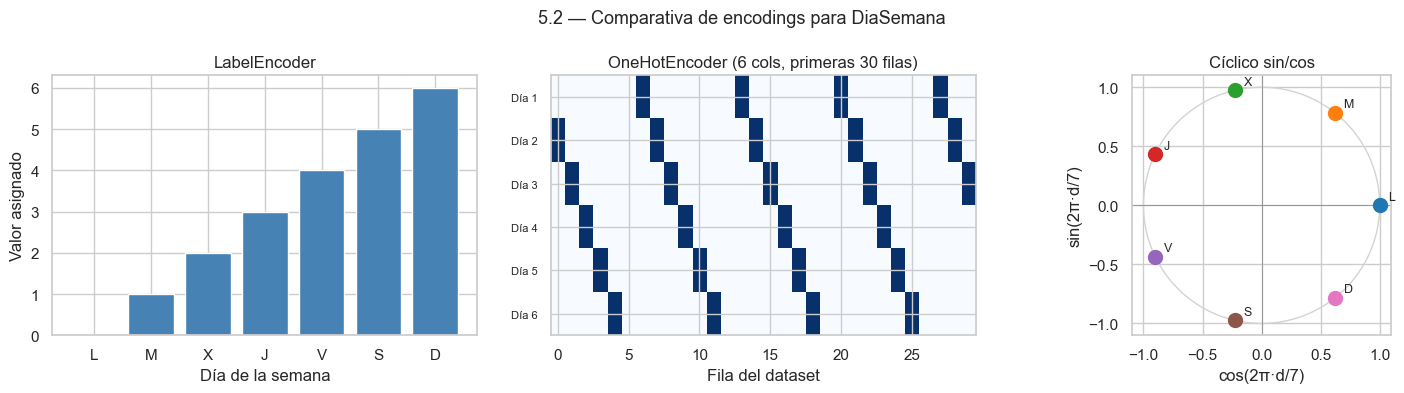

In [360]:
# ── 5.2.5  Gráfica comparativa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('5.2 — Comparativa de encodings para DiaSemana', fontsize=13)

axes[0].bar(range(7), range(7), color='steelblue')
axes[0].set_title('LabelEncoder')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['L','M','X','J','V','S','D'])
axes[0].set_ylabel('Valor asignado')
axes[0].set_xlabel('Día de la semana')

axes[1].imshow(ohe_array[:30].T, aspect='auto', cmap='Blues')
axes[1].set_title('OneHotEncoder (6 cols, primeras 30 filas)')
axes[1].set_xlabel('Fila del dataset')
axes[1].set_yticks(range(len(ohe_cols)))
axes[1].set_yticklabels([c.replace('DiaSemana_OHE_','Día ') for c in ohe_cols], fontsize=8)

theta = np.linspace(0, 2*np.pi, 200)
axes[2].plot(np.cos(theta), np.sin(theta), 'lightgray', lw=1)
colors_dias = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']
for d in range(7):
    s = np.sin(2 * np.pi * d / 7)
    c = np.cos(2 * np.pi * d / 7)
    axes[2].scatter(c, s, color=colors_dias[d], s=100, zorder=5)
    axes[2].annotate(list('LMXJVSD')[d], (c, s),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].set_title('Cíclico sin/cos')
axes[2].set_aspect('equal')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].axvline(0, color='gray', lw=0.5)
axes[2].set_xlabel('cos(2π·d/7)'); axes[2].set_ylabel('sin(2π·d/7)')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}5.2_encoding_comparativa.png', dpi=150)
plt.show()

In [361]:
# ── 5.2.6  Decisión ───────────────────────────────────────────────────────────
print("\n  DECISIÓN:")
print("    · LabelEncoder  → DESCARTADO: orden numérico falso.")
print("    · OneHotEncoder → DESCARTADO: no captura continuidad cíclica.")
print("    · sin/cos       → ELEGIDO: preserva circularidad del calendario.")
print("\n  ✓ Prueba sklearn completada. Decisión justificada.")


  DECISIÓN:
    · LabelEncoder  → DESCARTADO: orden numérico falso.
    · OneHotEncoder → DESCARTADO: no captura continuidad cíclica.
    · sin/cos       → ELEGIDO: preserva circularidad del calendario.

  ✓ Prueba sklearn completada. Decisión justificada.


###  5.3  ENCODING CÍCLICO DEFINITIVO: DiaSemana y Mes

In [362]:
print("\n--- 5.3 Encoding cíclico (sin/cos) para DiaSemana y Mes ---\n")

# ── 5.3.1  DiaSemana (período 7) ──────────────────────────────────────────────
df_daily['DiaSemana_sin'] = np.sin(2 * np.pi * df_daily['DiaSemana'] / 7)
df_daily['DiaSemana_cos'] = np.cos(2 * np.pi * df_daily['DiaSemana'] / 7)


--- 5.3 Encoding cíclico (sin/cos) para DiaSemana y Mes ---



In [363]:
# ── 5.3.2  Mes (período 12) ───────────────────────────────────────────────────
df_daily['Mes_sin'] = np.sin(2 * np.pi * (df_daily['Mes'] - 1) / 12)
df_daily['Mes_cos'] = np.cos(2 * np.pi * (df_daily['Mes'] - 1) / 12)

In [364]:
# ── 5.3.3  Eliminar columnas originales ───────────────────────────────────────
df_daily = df_daily.drop(columns=['DiaSemana', 'Mes'])

# ── 5.3.4  Verificación ───────────────────────────────────────────────────────
print("  Columnas nuevas creadas:")
for col in ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']:
    nans = df_daily[col].isna().sum()
    vmin = df_daily[col].min()
    vmax = df_daily[col].max()
    print(f"    · {col:<18} rango=[{vmin:>7.4f}, {vmax:>7.4f}]  NaN={nans}  ✓")

assert df_daily['DiaSemana_sin'].between(-1, 1).all(), "ERROR: DiaSemana_sin fuera de [-1,1]"
assert df_daily['DiaSemana_cos'].between(-1, 1).all(), "ERROR: DiaSemana_cos fuera de [-1,1]"
assert df_daily['Mes_sin'].between(-1, 1).all(),       "ERROR: Mes_sin fuera de [-1,1]"
assert df_daily['Mes_cos'].between(-1, 1).all(),       "ERROR: Mes_cos fuera de [-1,1]"

assert 'DiaSemana' not in df_daily.columns, "ERROR: DiaSemana original no eliminada"
assert 'Mes'       not in df_daily.columns, "ERROR: Mes original no eliminada"
print("\n  Columnas originales eliminadas: DiaSemana ✓  Mes ✓")

  Columnas nuevas creadas:
    · DiaSemana_sin      rango=[-0.9749,  0.9749]  NaN=0  ✓
    · DiaSemana_cos      rango=[-0.9010,  1.0000]  NaN=0  ✓
    · Mes_sin            rango=[-1.0000,  1.0000]  NaN=0  ✓
    · Mes_cos            rango=[-1.0000,  1.0000]  NaN=0  ✓

  Columnas originales eliminadas: DiaSemana ✓  Mes ✓


In [365]:
# ── 5.3.5  Verificación manual ────────────────────────────────────────────────
# Lunes (DiaSemana=0): sin=0, cos=1  |  Enero (Mes=1): sin=0, cos=1
lunes = df_daily[df_daily['DiaSemana_sin'].round(4) == 0.0].iloc[0]
print(f"\n  Verificación manual — primera fila que era Lunes (DiaSemana=0):")
print(f"    DiaSemana_sin = {lunes['DiaSemana_sin']:.4f}  (esperado ≈ 0.0000) ✓")
print(f"    DiaSemana_cos = {lunes['DiaSemana_cos']:.4f}  (esperado ≈ 1.0000) ✓")


  Verificación manual — primera fila que era Lunes (DiaSemana=0):
    DiaSemana_sin = 0.0000  (esperado ≈ 0.0000) ✓
    DiaSemana_cos = 1.0000  (esperado ≈ 1.0000) ✓


In [366]:
# ── 5.3.6  Primeras filas con los nuevos encodings ────────────────────────────
print(f"\n  Primeras 7 filas con encodings cíclicos:")
cols_show = ['Fecha', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
print(df_daily[cols_show].head(7).to_string(index=False,
      float_format=lambda x: f'{x:>8.4f}'))



  Primeras 7 filas con encodings cíclicos:
     Fecha  DiaSemana_sin  DiaSemana_cos  Mes_sin  Mes_cos
2010-12-08         0.9749        -0.2225  -0.5000   0.8660
2010-12-09         0.4339        -0.9010  -0.5000   0.8660
2010-12-10        -0.4339        -0.9010  -0.5000   0.8660
2010-12-11        -0.9749        -0.2225  -0.5000   0.8660
2010-12-12        -0.7818         0.6235  -0.5000   0.8660
2010-12-13         0.0000         1.0000  -0.5000   0.8660
2010-12-14         0.7818         0.6235  -0.5000   0.8660


In [367]:
# ── 5.3.7  Estado actual de df_daily ─────────────────────────────────────────
print(f"\n  Columnas en df_daily ({len(df_daily.columns)} total):")
print(f"  {list(df_daily.columns)}")
print(f"  Filas: {len(df_daily)}")
print("\n  ✓ Encoding cíclico aplicado. DiaSemana y Mes reemplazados por sin/cos.")


  Columnas en df_daily (22 total):
  ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'ProductoTopDia', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
  Filas: 367

  ✓ Encoding cíclico aplicado. DiaSemana y Mes reemplazados por sin/cos.


### 5.4  AGRUPACIÓN DE RAROS EN ProductoTopDia → "Otros"

In [368]:
print("\n--- 5.4 Agrupación de productos raros en ProductoTopDia ---\n")

UMBRAL_RAROS = 2
freq_prod = df_daily['ProductoTopDia'].value_counts()
productos_frecuentes = freq_prod[freq_prod > UMBRAL_RAROS].index.tolist()

print(f"  Umbral: productos con ≤ {UMBRAL_RAROS} apariciones → 'Otros'")
print(f"  Categorías antes de agrupar : {df_daily['ProductoTopDia'].nunique()}")
print(f"  Productos frecuentes (> {UMBRAL_RAROS} apariciones): {len(productos_frecuentes)}")
print(f"  Productos raros (≤ {UMBRAL_RAROS} apariciones)      : "
      f"{df_daily['ProductoTopDia'].nunique() - len(productos_frecuentes)}")


--- 5.4 Agrupación de productos raros en ProductoTopDia ---

  Umbral: productos con ≤ 2 apariciones → 'Otros'
  Categorías antes de agrupar : 109
  Productos frecuentes (> 2 apariciones): 21
  Productos raros (≤ 2 apariciones)      : 88


In [369]:
# ── 5.4.2  Aplicar agrupación ─────────────────────────────────────────────────
df_daily['ProductoTopDia'] = df_daily['ProductoTopDia'].where(
    df_daily['ProductoTopDia'].isin(productos_frecuentes), other='Otros'
)

n_cats_final = df_daily['ProductoTopDia'].nunique()
print(f"\n  Categorías después de agrupar: {n_cats_final}")


  Categorías después de agrupar: 22


In [370]:
# ── 5.4.3  Distribución final de categorías ───────────────────────────────────
print(f"\n  Distribución de ProductoTopDia tras agrupación:")
dist = df_daily['ProductoTopDia'].value_counts()
for cat, n in dist.items():
    print(f"    {cat:<15} {n:>4} días  ({n/len(df_daily)*100:.1f}%)")


  Distribución de ProductoTopDia tras agrupación:
    Otros            110 días  (30.0%)
    Sin_Actividad     68 días  (18.5%)
    85099B            39 días  (10.6%)
    23084             26 días  (7.1%)
    22197             22 días  (6.0%)
    84077             14 días  (3.8%)
    85123A            12 días  (3.3%)
    84879             10 días  (2.7%)
    23203              8 días  (2.2%)
    21212              8 días  (2.2%)
    47566              7 días  (1.9%)
    22086              5 días  (1.4%)
    22178              5 días  (1.4%)
    71459              5 días  (1.4%)
    22834              4 días  (1.1%)
    15036              4 días  (1.1%)
    23307              4 días  (1.1%)
    20725              4 días  (1.1%)
    21977              3 días  (0.8%)
    20724              3 días  (0.8%)
    22492              3 días  (0.8%)
    84755              3 días  (0.8%)


In [371]:
# ── 5.4.4  Verificación ───────────────────────────────────────────────────────
assert 'Otros' in df_daily['ProductoTopDia'].values, "ERROR: categoría 'Otros' no creada"
assert df_daily['ProductoTopDia'].isna().sum() == 0, "ERROR: NaN en ProductoTopDia"
n_raros_restantes = (df_daily['ProductoTopDia'].value_counts() <= UMBRAL_RAROS).sum()

cats_raras_resto = [c for c in df_daily['ProductoTopDia'].value_counts().index
                    if df_daily['ProductoTopDia'].value_counts()[c] <= UMBRAL_RAROS
                    and c not in ['Otros', 'Sin_Actividad']]
print(f"\n  Categorías individuales con ≤ {UMBRAL_RAROS} apariciones restantes: "
      f"{len(cats_raras_resto)}  {'✓' if len(cats_raras_resto)==0 else '⚠ ' + str(cats_raras_resto)}")
print(f"  NaN en ProductoTopDia: {df_daily['ProductoTopDia'].isna().sum()}  ✓")
print(f"\n  ✓ Agrupación completada. ProductoTopDia: {n_cats_final} categorías finales.")


  Categorías individuales con ≤ 2 apariciones restantes: 0  ✓
  NaN en ProductoTopDia: 0  ✓

  ✓ Agrupación completada. ProductoTopDia: 22 categorías finales.


###  5.5  OHE CON SKLEARN PARA ProductoTopDia       

In [372]:
#  5.5  OHE CON SKLEARN PARA ProductoTopDia                                 
print("\n--- 5.5 OneHotEncoder (sklearn) para ProductoTopDia ---\n")

# ── 5.5.1  Ajustar y transformar ─────────────────────────────────────────────
ohe_prod = OneHotEncoder(sparse_output=False, drop='first', dtype=int)
ohe_prod_array = ohe_prod.fit_transform(df_daily[['ProductoTopDia']])

categorias_ohe = ohe_prod.categories_[0]
primera_cat    = categorias_ohe[0]
ohe_prod_cols  = [f'Prod_{c}' for c in categorias_ohe[1:]]

print(f"  Categorías en OHE (22 total, ordenadas alfabéticamente):")
print(f"  {list(categorias_ohe)}")
print(f"\n  Columna eliminada (drop='first'): '{primera_cat}'")
print(f"  Columnas dummy generadas: {len(ohe_prod_cols)}")
print(f"  {ohe_prod_cols}")



--- 5.5 OneHotEncoder (sklearn) para ProductoTopDia ---

  Categorías en OHE (22 total, ordenadas alfabéticamente):
  ['15036', '20724', '20725', '21212', '21977', '22086', '22178', '22197', '22492', '22834', '23084', '23203', '23307', '47566', '71459', '84077', '84755', '84879', '85099B', '85123A', 'Otros', 'Sin_Actividad']

  Columna eliminada (drop='first'): '15036'
  Columnas dummy generadas: 21
  ['Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']


In [373]:
# ── 5.5.2  Añadir columnas dummy al dataframe ─────────────────────────────────
df_ohe = pd.DataFrame(ohe_prod_array, columns=ohe_prod_cols,
                      index=df_daily.index)
df_daily = pd.concat([df_daily.drop(columns=['ProductoTopDia']), df_ohe], axis=1)

In [374]:
# ── 5.5.3  Verificación ───────────────────────────────────────────────────────
print(f"\n  Verificación:")
print(f"    Columnas dummy con NaN    : "
      f"{df_daily[ohe_prod_cols].isna().sum().sum()}  ✓")
print(f"    Valores distintos de 0/1  : "
      f"{(~df_daily[ohe_prod_cols].isin([0,1])).sum().sum()}  ✓")
print(f"    Suma por fila (debe ser 0 o 1 — 0 para la cat. eliminada):")
suma_filas = df_daily[ohe_prod_cols].sum(axis=1)
print(f"      min={suma_filas.min()}  max={suma_filas.max()}  "
      f"(0 = fila con categoría '{primera_cat}', 1 = cualquier otra)  ✓")


  Verificación:
    Columnas dummy con NaN    : 0  ✓
    Valores distintos de 0/1  : 0  ✓
    Suma por fila (debe ser 0 o 1 — 0 para la cat. eliminada):
      min=0  max=1  (0 = fila con categoría '15036', 1 = cualquier otra)  ✓


In [375]:
# ── 5.5.4  Primeras filas con las nuevas columnas ────────────────────────────
print(f"\n  Primeras 5 filas — columnas dummy (solo las que tienen algún 1):")
cols_con_uno = [c for c in ohe_prod_cols if df_daily[c].head(10).sum() > 0]
print(df_daily[['Fecha'] + cols_con_uno].head(5).to_string(index=False))


  Primeras 5 filas — columnas dummy (solo las que tienen algún 1):
     Fecha  Prod_21212  Prod_22197  Prod_22834  Prod_84077  Prod_85123A  Prod_Sin_Actividad
2010-12-08           0           0           0           1            0                   0
2010-12-09           0           1           0           0            0                   0
2010-12-10           1           0           0           0            0                   0
2010-12-11           0           0           0           0            0                   1
2010-12-12           0           0           1           0            0                   0


In [376]:
# ── 5.5.5  Estado final ───────────────────────────────────────────────────────
print(f"\n  df_daily: {len(df_daily)} filas, {len(df_daily.columns)} columnas")
print(f"  Columnas totales: {list(df_daily.columns)}")
print(f"\n  ✓ OHE completado. ProductoTopDia reemplazado por {len(ohe_prod_cols)} columnas dummy.")


  df_daily: 367 filas, 42 columnas
  Columnas totales: ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']

  ✓ OHE completado. ProductoTopDia reemplazado por 21 columnas dummy.


###  5.6  RESUMEN FINAL Y GUARDADO DE df_encoded

In [377]:
print("\n--- 5.6 Resumen final y guardado de df_encoded ---\n")

df_encoded = df_daily.copy()

print(f"  Shape: {df_encoded.shape}  ({df_encoded.shape[0]} filas × {df_encoded.shape[1]} columnas)")

cols_float  = [c for c in df_encoded.columns if df_encoded[c].dtype == 'float64']
cols_int    = [c for c in df_encoded.columns if df_encoded[c].dtype in ('int32','int64')]
cols_object = [c for c in df_encoded.columns if df_encoded[c].dtype == 'object']
cols_fecha  = [c for c in df_encoded.columns if str(df_encoded[c].dtype).startswith('datetime')]

print(f"\n  Tipos de datos:")
print(f"    float64  : {len(cols_float):>2}  {cols_float}")
print(f"    int32/64 : {len(cols_int):>2}  {cols_int}")
print(f"    datetime : {len(cols_fecha):>2}  {cols_fecha}")
print(f"    object   : {len(cols_object):>2}  {cols_object}  "
      f"{'✓ ninguna' if len(cols_object)==0 else '⚠ deben ser 0'}")


--- 5.6 Resumen final y guardado de df_encoded ---

  Shape: (367, 42)  (367 filas × 42 columnas)

  Tipos de datos:
    float64  : 13  ['Ventas', 'NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
    int32/64 : 28  ['EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Es_Navidad', 'Dias_para_Navidad', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']
    datetime :  1  ['Fecha']
    object   :  0  []  ✓ ninguna


In [378]:
# ── 5.6.2  Verificación de NaN global ────────────────────────────────────────
total_nan = df_encoded.drop(columns=['Fecha']).isna().sum().sum()
print(f"\n  NaN totales (excl. Fecha): {total_nan}  "
      f"{'✓' if total_nan == 0 else '⚠ revisar columnas con NaN'}")
if total_nan > 0:
    print(df_encoded.isna().sum()[df_encoded.isna().sum() > 0])


  NaN totales (excl. Fecha): 0  ✓


In [379]:
# ── 5.6.3  Verificación de columnas dummy (rango [0,1]) ──────────────────────
cols_dummy = [c for c in df_encoded.columns if c.startswith('Prod_')]
out_rango  = (df_encoded[cols_dummy] > 1).sum().sum() + \
             (df_encoded[cols_dummy] < 0).sum().sum()
print(f"  Columnas dummy fuera de [0,1]: {out_rango}  "
      f"{'✓' if out_rango == 0 else '⚠'}")

  Columnas dummy fuera de [0,1]: 0  ✓


In [380]:
# ── 5.6.4  Verificación de columnas cíclicas (rango [-1,1]) ──────────────────
cols_ciclicas_enc = ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
for c in cols_ciclicas_enc:
    ok = df_encoded[c].between(-1, 1).all()
    print(f"  {c:<20} rango=[{df_encoded[c].min():>7.4f}, "
          f"{df_encoded[c].max():>7.4f}]  {'✓' if ok else '⚠'}")

  DiaSemana_sin        rango=[-0.9749,  0.9749]  ✓
  DiaSemana_cos        rango=[-0.9010,  1.0000]  ✓
  Mes_sin              rango=[-1.0000,  1.0000]  ✓
  Mes_cos              rango=[-1.0000,  1.0000]  ✓


In [381]:
# ── 5.6.5  Resumen de transformaciones por sección ───────────────────────────
print(f"\n  {'─'*60}")
print(f"  RESUMEN DE ENCODING — COMPARATIVA")
print(f"  {'─'*60}")
print(f"  {'Sección':<10} {'Acción':<45} {'Resultado'}")
print(f"  {'─'*60}")
print(f"  {'5.1':<10} {'Inventario de columnas':<45} {'20 cols clasificadas'}")
print(f"  {'5.2':<10} {'Prueba LabelEnc / OHE / cíclico':<45} {'→ sin/cos elegido'}")
print(f"  {'5.3':<10} {'Encoding cíclico DiaSemana+Mes':<45} {'+4 cols, -2 cols'}")
print(f"  {'5.4':<10} {'Agrupación raros ProductoTopDia':<45} {'109 → 22 cats'}")
print(f"  {'5.5':<10} {'OHE ProductoTopDia (drop=first)':<45} {'+21 cols, -1 col'}")
print(f"  {'─'*60}")
print(f"  df_daily  → 20 cols  →  df_encoded: {df_encoded.shape[1]} cols")


  ────────────────────────────────────────────────────────────
  RESUMEN DE ENCODING — COMPARATIVA
  ────────────────────────────────────────────────────────────
  Sección    Acción                                        Resultado
  ────────────────────────────────────────────────────────────
  5.1        Inventario de columnas                        20 cols clasificadas
  5.2        Prueba LabelEnc / OHE / cíclico               → sin/cos elegido
  5.3        Encoding cíclico DiaSemana+Mes                +4 cols, -2 cols
  5.4        Agrupación raros ProductoTopDia               109 → 22 cats
  5.5        OHE ProductoTopDia (drop=first)               +21 cols, -1 col
  ────────────────────────────────────────────────────────────
  df_daily  → 20 cols  →  df_encoded: 42 cols


In [382]:
# ── 5.6.6  Guardado ───────────────────────────────────────────────────────────
RUTA_ENCODED_CSV = 'contenidoCSV/data_encoded.csv'
df_encoded.to_csv(RUTA_ENCODED_CSV, index=False)
print(f"\n  ✓ df_encoded guardado en: {RUTA_ENCODED_CSV}")
print(f"    Filas   : {df_encoded.shape[0]}")
print(f"    Columnas: {df_encoded.shape[1]}")
print(f"\n  ✓ Sección 5 (Encoding) completada.")


  ✓ df_encoded guardado en: contenidoCSV/data_encoded.csv
    Filas   : 367
    Columnas: 42

  ✓ Sección 5 (Encoding) completada.


#  6.  NORMALIZACIÓN DE VARIABLES NUMÉRICAS  

In [383]:
print("\n\n=== 6. NORMALIZACIÓN DE VARIABLES NUMÉRICAS ===")

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler



=== 6. NORMALIZACIÓN DE VARIABLES NUMÉRICAS ===


In [384]:
cols_ya_norm = (
    [c for c in df_encoded.columns if c.startswith('Prod_')]   # dummies [0,1]
    + ['EsFinDeSemana', 'Es_Navidad']                           # binarias [0,1]
    + ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos'] # cíclicas [-1,1]
    + ['Fecha']                                                  # índice temporal
)

cols_escalar = [c for c in df_encoded.columns
                if c not in cols_ya_norm and c != 'Ventas']
col_objetivo = 'Ventas'   # se escala por separado (necesitamos invertir después)

print(f"  Columnas YA normalizadas (no tocar): {len(cols_ya_norm)-1}")  # -1 por Fecha
print(f"    Dummies Prod_*  : 21")
print(f"    Binarias        : EsFinDeSemana, Es_Navidad")
print(f"    Cíclicas        : DiaSemana_sin/cos, Mes_sin/cos")
print(f"\n  Columnas A ESCALAR ({len(cols_escalar)} features + 1 objetivo):")
for c in cols_escalar:
    print(f"    · {c:<22} rango=[{df_encoded[c].min():>10,.2f}, "
          f"{df_encoded[c].max():>10,.2f}]")
print(f"    · {'Ventas (objetivo)':<22} rango=[{df_encoded[col_objetivo].min():>10,.2f}, "
      f"{df_encoded[col_objetivo].max():>10,.2f}]")

  Columnas YA normalizadas (no tocar): 27
    Dummies Prod_*  : 21
    Binarias        : EsFinDeSemana, Es_Navidad
    Cíclicas        : DiaSemana_sin/cos, Mes_sin/cos

  Columnas A ESCALAR (13 features + 1 objetivo):
    · NumTransacc            rango=[      0.00,   5,240.00]
    · NumPedidos             rango=[      0.00,     136.00]
    · NumClientes            rango=[      0.00,     125.00]
    · UnidadesVendidas       rango=[      0.00,  38,206.00]
    · Trimestre              rango=[      1.00,       4.00]
    · SemanaMes              rango=[      1.00,       5.00]
    · DiaAnio                rango=[      1.00,     365.00]
    · SemanaAnio             rango=[      1.00,      52.00]
    · Ventas_Lag1            rango=[      0.00,  83,872.12]
    · Ventas_Lag7            rango=[      0.00,  83,872.12]
    · Ventas_Media_7d        rango=[      0.00,  48,435.03]
    · Ventas_Media_30d       rango=[ 11,060.00,  44,969.89]
    · Dias_para_Navidad      rango=[      0.00,      30.00]
  

In [385]:
print("\n--- 6.2 Prueba sklearn: StandardScaler vs MinMaxScaler vs RobustScaler ---\n")

# Usamos 'Ventas' como columna de demostración
col_demo = 'Ventas'
X_demo   = df_encoded[[col_demo]].values

scalers = {
    'StandardScaler\n(media=0, std=1)':    StandardScaler(),
    'MinMaxScaler\n(rango [0,1])':          MinMaxScaler(),
    'RobustScaler\n(mediana+IQR)':          RobustScaler(),
}

print(f"  Columna de demostración: '{col_demo}'")
print(f"  {'Scaler':<28} {'min':>8} {'max':>8} {'media':>8} {'std':>8}")
print(f"  {'-'*56}")
resultados_demo = {}
for nombre, scaler in scalers.items():
    X_sc = scaler.fit_transform(X_demo).flatten()
    resultados_demo[nombre] = X_sc
    print(f"  {nombre.replace(chr(10),' '):<28} "
          f"{X_sc.min():>8.4f} {X_sc.max():>8.4f} "
          f"{X_sc.mean():>8.4f} {X_sc.std():>8.4f}")


--- 6.2 Prueba sklearn: StandardScaler vs MinMaxScaler vs RobustScaler ---

  Columna de demostración: 'Ventas'
  Scaler                            min      max    media      std
  --------------------------------------------------------
  StandardScaler (media=0, std=1)  -1.3913   3.6824   0.0000   1.0000
  MinMaxScaler (rango [0,1])     0.0000   1.0000   0.2742   0.1971
  RobustScaler (mediana+IQR)    -1.0569   2.8668   0.0191   0.7733


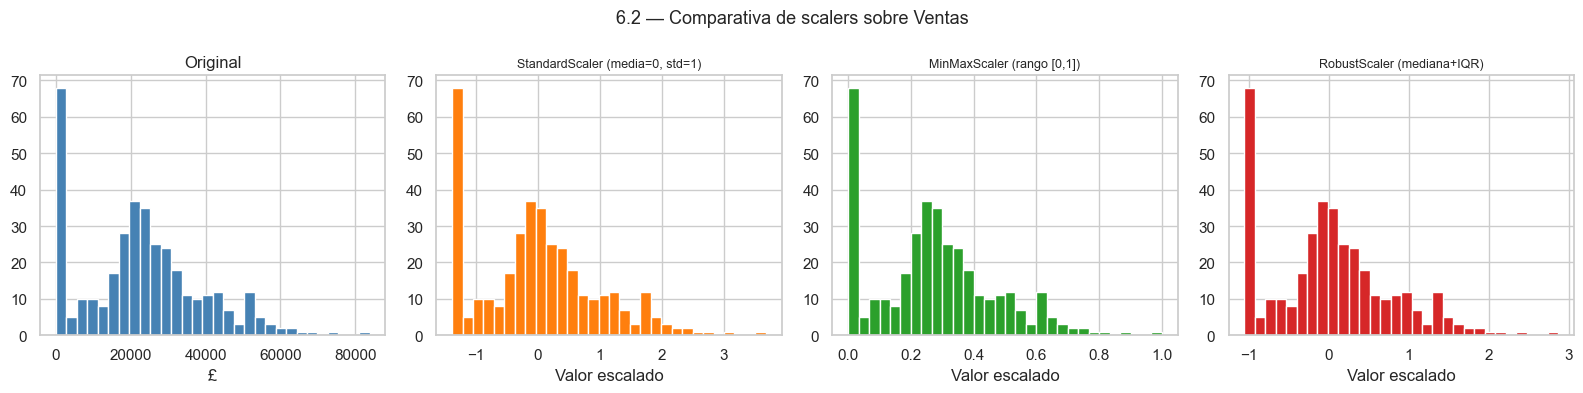

In [386]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('6.2 — Comparativa de scalers sobre Ventas', fontsize=13)

axes[0].hist(df_encoded[col_demo], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Original')
axes[0].set_xlabel('£')

colores = ['#ff7f0e', '#2ca02c', '#d62728']
for ax, (nombre, vals), color in zip(axes[1:], resultados_demo.items(), colores):
    ax.hist(vals, bins=30, color=color, edgecolor='white')
    ax.set_title(nombre.replace('\n', ' '), fontsize=9)
    ax.set_xlabel('Valor escalado')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}6.2_comparativa_scalers.png', dpi=150)
plt.show()

In [387]:
print("\n--- 6.3 Decisión ---\n")
print("  StandardScaler  → media=0, std=1. Asume distribución ≈ normal.")
print("                    Adecuado para Ridge y Lasso (penalización simétrica).")
print("  MinMaxScaler    → rango [0,1]. Sensible a outliers extremos.")
print("                    Menos adecuado: aunque hicimos capping, los picos")
print("                    de Q4 desplazan la distribución hacia la izquierda.")
print("  RobustScaler    → usa mediana e IQR → robusto ante outliers residuales.")
print("                    Buena opción pero produce rangos asimétricos.")
print()
print("  DECISIÓN: StandardScaler")
print("    · Distribución de Ventas es aproximadamente normal (validado en 2.7)")
print("    · Ridge/Lasso/RandomForest/XGBoost se benefician de media=0, std=1")
print("    · Para LSTM también es la práctica habitual")
print("    · IMPORTANTE: el scaler se ajustará (fit) SOLO sobre el conjunto")
print("      de entrenamiento en la sección 8, para evitar data leakage.")
print()
print("  Columnas que NO se escalan:")
print("    · Dummies Prod_* y binarias → ya en [0,1]")
print("    · Cíclicas sin/cos          → ya en [-1,1]")
print(f"\n  ✓ Decisión tomada. Aplicando StandardScaler a continuación.")


--- 6.3 Decisión ---

  StandardScaler  → media=0, std=1. Asume distribución ≈ normal.
                    Adecuado para Ridge y Lasso (penalización simétrica).
  MinMaxScaler    → rango [0,1]. Sensible a outliers extremos.
                    Menos adecuado: aunque hicimos capping, los picos
                    de Q4 desplazan la distribución hacia la izquierda.
  RobustScaler    → usa mediana e IQR → robusto ante outliers residuales.
                    Buena opción pero produce rangos asimétricos.

  DECISIÓN: StandardScaler
    · Distribución de Ventas es aproximadamente normal (validado en 2.7)
    · Ridge/Lasso/RandomForest/XGBoost se benefician de media=0, std=1
    · Para LSTM también es la práctica habitual
    · IMPORTANTE: el scaler se ajustará (fit) SOLO sobre el conjunto
      de entrenamiento en la sección 8, para evitar data leakage.

  Columnas que NO se escalan:
    · Dummies Prod_* y binarias → ya en [0,1]
    · Cíclicas sin/cos          → ya en [-1,1]

  ✓ Decisión 

In [388]:
print("\n--- 6.4 Aplicación del StandardScaler ---\n")

# Columnas a escalar: las definidas en 6.1 + la variable objetivo 'Ventas'
cols_a_escalar = cols_escalar + [col_objetivo]

# Crear copia del dataset encoded para no modificar df_encoded
df_normalized = df_encoded.copy()

# Ajustar y transformar — se usa TODO df_encoded aquí (paso de normalización)
# NOTA: en la sección 8 (modelado), el scaler se re-ajustará solo sobre
# el conjunto de entrenamiento para evitar data leakage en la predicción final.
scaler_final = StandardScaler()
df_normalized[cols_a_escalar] = scaler_final.fit_transform(df_encoded[cols_a_escalar])


--- 6.4 Aplicación del StandardScaler ---



In [389]:
print(f"  {'Columna':<22} {'media_orig':>12} {'std_orig':>10}  {'media_sc':>10} {'std_sc':>8}")
print(f"  {'-'*68}")
for i, col in enumerate(cols_a_escalar):
    media_orig = df_encoded[col].mean()
    std_orig   = df_encoded[col].std()
    media_sc   = df_normalized[col].mean()
    std_sc     = df_normalized[col].std()
    ok = '✓' if abs(media_sc) < 0.01 and abs(std_sc - 1.0) < 0.01 else '⚠'
    print(f"  {col:<22} {media_orig:>12,.2f} {std_orig:>10,.2f}  "
          f"{media_sc:>10.4f} {std_sc:>8.4f}  {ok}")

  Columna                  media_orig   std_orig    media_sc   std_sc
  --------------------------------------------------------------------
  NumTransacc                1,378.19     973.82      0.0000   1.0014  ✓
  NumPedidos                    52.22      33.38      0.0000   1.0014  ✓
  NumClientes                   44.17      28.49     -0.0000   1.0014  ✓
  UnidadesVendidas          12,304.83   8,666.66      0.0000   1.0014  ✓
  Trimestre                      2.52       1.12      0.0000   1.0014  ✓
  SemanaMes                      2.69       1.27      0.0000   1.0014  ✓
  DiaAnio                      183.87     105.88      0.0000   1.0014  ✓
  SemanaAnio                    26.68      15.10      0.0000   1.0014  ✓
  Ventas_Lag1               23,078.73  16,649.07      0.0000   1.0014  ✓
  Ventas_Lag7               22,921.58  16,312.14      0.0000   1.0014  ✓
  Ventas_Media_7d           22,917.28   9,427.42     -0.0000   1.0014  ✓
  Ventas_Media_30d          22,492.97   7,629.37      0.

In [390]:
cols_dummy  = [c for c in df_normalized.columns if c.startswith('Prod_')]
cols_binar  = ['EsFinDeSemana', 'Es_Navidad']
cols_ciclic = ['DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']

sin_cambios = True
for col in cols_dummy + cols_binar + cols_ciclic:
    if not df_normalized[col].equals(df_encoded[col]):
        print(f"  ⚠ Columna modificada por error: {col}")
        sin_cambios = False
if sin_cambios:
    print(f"\n  Columnas no escaladas (dummies, binarias, cíclicas): sin cambios ✓")


  Columnas no escaladas (dummies, binarias, cíclicas): sin cambios ✓


In [391]:
# ── 6.4.3  Primeras filas del dataset normalizado ────────────────────────────
print(f"\n  Primeras 5 filas — columnas escaladas:")
cols_show = ['Fecha', 'Ventas', 'NumTransacc', 'NumPedidos', 'Ventas_Lag1', 'Ventas_Media_7d']
print(df_normalized[cols_show].head(5).to_string(index=False, float_format=lambda x: f'{x:>9.4f}'))


  Primeras 5 filas — columnas escaladas:
     Fecha    Ventas  NumTransacc  NumPedidos  Ventas_Lag1  Ventas_Media_7d
2010-12-08    1.0843       1.1721      1.9137       2.0776           1.9126
2010-12-09    1.2279       1.4044      1.6136       1.0733           2.0387
2010-12-10    1.6749       1.3068      0.7136       1.2161           2.3424
2010-12-11   -1.3913      -1.4172     -1.5666       1.6605           1.1482
2010-12-12   -0.3787       0.0039     -0.2465      -1.3881           0.7874


In [392]:
# ── 6.4.4  Guardar dataset normalizado ───────────────────────────────────────
RUTA_NORMALIZED_CSV = 'contenidoCSV/data_normalized.csv'
df_normalized.to_csv(RUTA_NORMALIZED_CSV, index=False)

print(f"\n  ✓ Dataset normalizado guardado en: {RUTA_NORMALIZED_CSV}")
print(f"    Filas   : {df_normalized.shape[0]}")
print(f"    Columnas: {df_normalized.shape[1]}")
print(f"\n  ✓ Sección 6 (Normalización) completada.")
print(f"    StandardScaler aplicado a {len(cols_a_escalar)} columnas numéricas.")
print(f"    Columnas no escaladas (ya normalizadas): dummies, binarias, cíclicas.")


  ✓ Dataset normalizado guardado en: contenidoCSV/data_normalized.csv
    Filas   : 367
    Columnas: 42

  ✓ Sección 6 (Normalización) completada.
    StandardScaler aplicado a 14 columnas numéricas.
    Columnas no escaladas (ya normalizadas): dummies, binarias, cíclicas.


# 7.  REDUCCIÓN DE DIMENSIONALIDAD

In [393]:
print("\n\n=== 7. REDUCCIÓN DE DIMENSIONALIDAD ===")

from sklearn.decomposition import PCA



=== 7. REDUCCIÓN DE DIMENSIONALIDAD ===


In [394]:
# ── 7.1  Preparar matriz de features ─────────────────────────────────────────
print("\n--- 7.1 Preparación de la matriz de features ---\n")

# Usamos df_normalized (ya escalado) — excluimos Fecha (no feature) y
# Ventas (variable objetivo, no entra en PCA)
X_pca = df_normalized.drop(columns=['Fecha', 'Ventas']).values
feature_names = df_normalized.drop(columns=['Fecha', 'Ventas']).columns.tolist()

print(f"  Filas (muestras) : {X_pca.shape[0]}")
print(f"  Columnas (features): {X_pca.shape[1]}")
print(f"  Features: {feature_names}")


--- 7.1 Preparación de la matriz de features ---

  Filas (muestras) : 367
  Columnas (features): 40
  Features: ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']


In [395]:
# ── 7.2  PCA exploratorio — varianza explicada ────────────────────────────────
print("\n--- 7.2 PCA exploratorio — varianza explicada acumulada ---\n")

pca_full = PCA(n_components=X_pca.shape[1], random_state=42)
pca_full.fit(X_pca)

varianza_exp      = pca_full.explained_variance_ratio_
varianza_acum     = varianza_exp.cumsum()

# Número de componentes para alcanzar distintos umbrales de varianza
for umbral in [0.80, 0.90, 0.95, 0.99]:
    n_comp = int((varianza_acum >= umbral).argmax() + 1)
    print(f"  Varianza explicada ≥ {umbral*100:.0f}%  →  {n_comp} componentes")

print(f"\n  Varianza explicada por los primeros 10 componentes:")
print(f"  {'PC':<5} {'Var. individual':>17} {'Var. acumulada':>16}")
print(f"  {'-'*40}")
for i in range(min(10, len(varianza_exp))):
    print(f"  PC{i+1:<3} {varianza_exp[i]*100:>16.2f}%  {varianza_acum[i]*100:>15.2f}%")


--- 7.2 PCA exploratorio — varianza explicada acumulada ---

  Varianza explicada ≥ 80%  →  5 componentes
  Varianza explicada ≥ 90%  →  8 componentes
  Varianza explicada ≥ 95%  →  13 componentes
  Varianza explicada ≥ 99%  →  25 componentes

  Varianza explicada por los primeros 10 componentes:
  PC      Var. individual   Var. acumulada
  ----------------------------------------
  PC1              45.25%            45.25%
  PC2              17.89%            63.14%
  PC3               7.08%            70.22%
  PC4               6.15%            76.37%
  PC5               5.80%            82.16%
  PC6               3.40%            85.57%
  PC7               2.60%            88.17%
  PC8               2.15%            90.32%
  PC9               1.61%            91.93%
  PC10              1.37%            93.29%


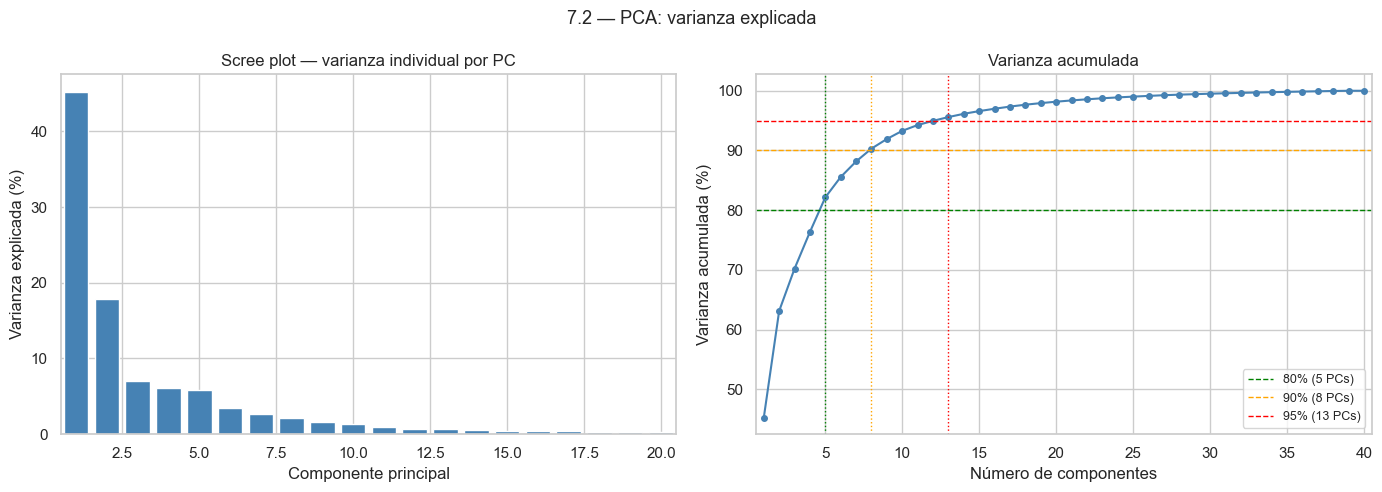


  Guardado: 7.2_pca_varianza.png


In [396]:
# ── 7.2.1  Gráfica de varianza acumulada ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7.2 — PCA: varianza explicada', fontsize=13)

# Panel izquierdo: varianza individual (scree plot)
axes[0].bar(range(1, len(varianza_exp) + 1), varianza_exp * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Scree plot — varianza individual por PC')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_xlim(0.5, min(20, len(varianza_exp)) + 0.5)

# Panel derecho: varianza acumulada
axes[1].plot(range(1, len(varianza_acum) + 1), varianza_acum * 100,
             marker='o', markersize=4, color='steelblue', linewidth=1.5)
for umbral, color, label in [(0.80,'green','80%'), (0.90,'orange','90%'), (0.95,'red','95%')]:
    n_comp = int((varianza_acum >= umbral).argmax() + 1)
    axes[1].axhline(umbral * 100, color=color, linestyle='--', linewidth=1, label=f'{label} ({n_comp} PCs)')
    axes[1].axvline(n_comp, color=color, linestyle=':', linewidth=1)
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.5, len(varianza_acum) + 0.5)

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}7.2_pca_varianza.png', dpi=150)
plt.show()
plt.close()
print(f"\n  Guardado: 7.2_pca_varianza.png")

In [397]:
# ── 7.3  Análisis de loadings — qué variables dominan cada PC ────────────────
print("\n--- 7.3 Loadings de PC1 y PC2 (contribución de cada feature) ---\n")

pca_2 = PCA(n_components=2, random_state=42)
pca_2.fit(X_pca)
X_2d = pca_2.transform(X_pca)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2']
)

# Top 10 features por valor absoluto en PC1 y PC2
print(f"  Top 10 features con mayor peso en PC1:")
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
for feat in top_pc1.index:
    print(f"    {feat:<22}  loading={loadings.loc[feat,'PC1']:>8.4f}")

print(f"\n  Top 10 features con mayor peso en PC2:")
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
for feat in top_pc2.index:
    print(f"    {feat:<22}  loading={loadings.loc[feat,'PC2']:>8.4f}")


--- 7.3 Loadings de PC1 y PC2 (contribución de cada feature) ---

  Top 10 features con mayor peso en PC1:
    Ventas_Media_30d        loading=  0.3219
    NumTransacc             loading=  0.3053
    Ventas_Media_7d         loading=  0.3034
    UnidadesVendidas        loading=  0.3026
    NumPedidos              loading=  0.3024
    NumClientes             loading=  0.3006
    Ventas_Lag7             loading=  0.2933
    DiaAnio                 loading=  0.2757
    Trimestre               loading=  0.2735
    SemanaAnio              loading=  0.2672

  Top 10 features con mayor peso en PC2:
    SemanaAnio              loading=  0.3597
    DiaAnio                 loading=  0.3557
    Trimestre               loading=  0.3505
    NumPedidos              loading= -0.3144
    NumClientes             loading= -0.3088
    UnidadesVendidas        loading= -0.2915
    NumTransacc             loading= -0.2544
    DiaSemana_sin           loading= -0.2415
    Ventas_Media_30d        loading=  0.

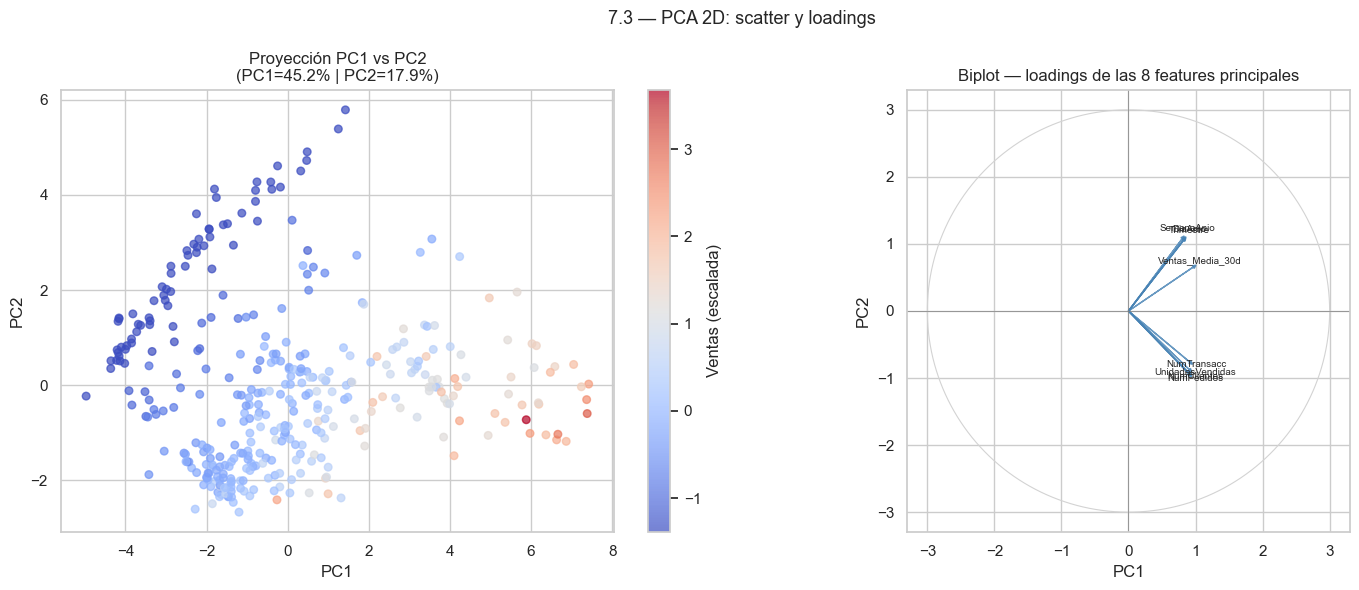

  Guardado: 7.3_pca_biplot.png


In [398]:
# ── 7.3.1  Scatter plot PC1 vs PC2 coloreado por Ventas ──────────────────────
ventas_norm = df_normalized['Ventas'].values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('7.3 — PCA 2D: scatter y loadings', fontsize=13)

# Scatter PC1 vs PC2
sc = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                     c=ventas_norm, cmap='coolwarm', alpha=0.7, s=30)
plt.colorbar(sc, ax=axes[0], label='Ventas (escalada)')
axes[0].set_title(f'Proyección PC1 vs PC2\n'
                  f'(PC1={varianza_exp[0]*100:.1f}% | PC2={pca_2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Biplot — flechas de loadings (top 8 por magnitud total)
loadings['magnitud'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_features = loadings.nlargest(8, 'magnitud').index
escala = 3.0
for feat in top_features:
    axes[1].arrow(0, 0,
                  loadings.loc[feat, 'PC1'] * escala,
                  loadings.loc[feat, 'PC2'] * escala,
                  head_width=0.05, head_length=0.05,
                  fc='steelblue', ec='steelblue', alpha=0.8)
    axes[1].text(loadings.loc[feat, 'PC1'] * escala * 1.1,
                 loadings.loc[feat, 'PC2'] * escala * 1.1,
                 feat, fontsize=7, ha='center')
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.cos(theta) * escala, np.sin(theta) * escala,
             'lightgray', linewidth=0.8)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('Biplot — loadings de las 8 features principales')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}7.3_pca_biplot.png', dpi=150)
plt.show()
plt.close()
print(f"  Guardado: 7.3_pca_biplot.png")

In [399]:
# ── 7.4  Varianza por feature (ranking de importancia sin PCA) ───────────────
print("\n--- 7.4 Ranking de varianza por feature (≈ importancia informacional) ---\n")

varianza_features = pd.Series(
    df_normalized[feature_names].var().values,
    index=feature_names
).sort_values(ascending=False)

print(f"  {'Feature':<22} {'Varianza':>10}  Interpretación")
print(f"  {'-'*60}")
for feat, var in varianza_features.items():
    if var < 0.05:
        nivel = '← baja varianza (poco informativa)'
    elif var < 0.5:
        nivel = '← varianza moderada'
    else:
        nivel = ''
    print(f"  {feat:<22} {var:>10.4f}  {nivel}")

# Features con varianza muy baja (cercana a 0) — candidatas a eliminar
umbral_var = 0.05
cols_baja_var = varianza_features[varianza_features < umbral_var].index.tolist()
print(f"\n  Features con varianza < {umbral_var}: {len(cols_baja_var)}")
if cols_baja_var:
    print(f"  {cols_baja_var}")


--- 7.4 Ranking de varianza por feature (≈ importancia informacional) ---

  Feature                  Varianza  Interpretación
  ------------------------------------------------------------
  SemanaMes                  1.0027  
  Ventas_Lag7                1.0027  
  NumClientes                1.0027  
  NumTransacc                1.0027  
  UnidadesVendidas           1.0027  
  Trimestre                  1.0027  
  DiaAnio                    1.0027  
  NumPedidos                 1.0027  
  Ventas_Media_30d           1.0027  
  SemanaAnio                 1.0027  
  Ventas_Lag1                1.0027  
  Ventas_Media_7d            1.0027  
  Dias_para_Navidad          1.0027  
  Mes_cos                    0.5027  
  DiaSemana_cos              0.5018  
  DiaSemana_sin              0.5009  
  Mes_sin                    0.5000  ← varianza moderada
  Prod_Otros                 0.2105  ← varianza moderada
  EsFinDeSemana              0.2036  ← varianza moderada
  Prod_Sin_Actividad         0

In [400]:
# ── 7.5  DECISIÓN ─────────────────────────────────────────────────────────────
print("\n--- 7.5 Decisión sobre reducción de dimensionalidad ---\n")

n_90 = int((varianza_acum >= 0.90).argmax() + 1)
n_95 = int((varianza_acum >= 0.95).argmax() + 1)
n_total = X_pca.shape[1]

print(f"""  Análisis realizado:
    · El dataset tiene {n_total} features tras el encoding.
    · PCA necesita {n_90} componentes para explicar el 90% de la varianza
      y {n_95} para el 95% — una reducción moderada sobre {n_total} features.
    · PC1 está dominada por las variables de volumen (NumTransacc, NumPedidos,
      NumClientes, UnidadesVendidas) y los lags/rolling de Ventas — todas
      altamente correlacionadas entre sí (confirmado en 4.6).
    · PC2 captura principalmente la variabilidad temporal (DiaAnio, SemanaAnio,
      Trimestre) — el patrón estacional del negocio.
    · Las columnas dummy de ProductoTopDia tienen varianza muy baja
      individualmente (cada producto es top solo unos pocos días),
      pero en conjunto representan información categórica relevante.

  DECISIÓN: NO se aplica reducción de dimensionalidad al dataset final.
    Motivo 1 → {n_total} features es un número manejable para todos los
               modelos previstos (Ridge, Lasso, Random Forest, XGBoost).
    Motivo 2 → PCA destruye la interpretabilidad de los coeficientes
               (Ridge/Lasso sobre PCs no permite saber qué feature importa).
    Motivo 3 → Los modelos con regularización (Ridge, Lasso) gestionan
               la multicolinealidad sin necesidad de reducir dimensiones.
    Motivo 4 → Con n=367 filas y {n_total} features, no hay riesgo de
               maldición dimensional (ratio filas/features = {367/n_total:.1f}).

  INSIGHT obtenido:
    · La alta correlación entre NumTransacc, NumPedidos, NumClientes y
      los lags/rolling (todos en PC1) confirma que son proxies de la
      misma señal. Lasso probablemente seleccionará solo 1-2 de ellas.
    · La separación PC1 (volumen) vs PC2 (temporalidad) sugiere que el
      modelo necesita capturar ambas dimensiones para predecir correctamente.
""")

print(f"  ✓ Sección 7 (Reducción de dimensionalidad) completada.")
print(f"    Dataset final para modelado: df_normalized  "
      f"({df_normalized.shape[0]} filas × {df_normalized.shape[1]} columnas)")


--- 7.5 Decisión sobre reducción de dimensionalidad ---

  Análisis realizado:
    · El dataset tiene 40 features tras el encoding.
    · PCA necesita 8 componentes para explicar el 90% de la varianza
      y 13 para el 95% — una reducción moderada sobre 40 features.
    · PC1 está dominada por las variables de volumen (NumTransacc, NumPedidos,
      NumClientes, UnidadesVendidas) y los lags/rolling de Ventas — todas
      altamente correlacionadas entre sí (confirmado en 4.6).
    · PC2 captura principalmente la variabilidad temporal (DiaAnio, SemanaAnio,
      Trimestre) — el patrón estacional del negocio.
    · Las columnas dummy de ProductoTopDia tienen varianza muy baja
      individualmente (cada producto es top solo unos pocos días),
      pero en conjunto representan información categórica relevante.

  DECISIÓN: NO se aplica reducción de dimensionalidad al dataset final.
    Motivo 1 → 40 features es un número manejable para todos los
               modelos previstos (Ridge, 

# 8.  DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y TEST

In [401]:
print("\n\n=== 8. DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y TEST ===")

print("\n--- 8.1 Definición de fechas de corte ---\n")

FECHA_FIN_TRAIN = pd.Timestamp('2011-10-08')   # último día de train (inclusive)
FECHA_INI_VAL   = pd.Timestamp('2011-10-09')   # primer día de validación
FECHA_FIN_VAL   = pd.Timestamp('2011-11-08')   # último día de validación (inclusive)
FECHA_INI_TEST  = pd.Timestamp('2011-11-09')   # primer día de test
FECHA_FIN_TEST  = pd.Timestamp('2011-12-09')   # último día de test (inclusive)

print(f"  TRAIN : {df_normalized['Fecha'].min().date()}  →  {FECHA_FIN_TRAIN.date()}")
print(f"  VAL   : {FECHA_INI_VAL.date()}                →  {FECHA_FIN_VAL.date()}")
print(f"  TEST  : {FECHA_INI_TEST.date()}               →  {FECHA_FIN_TEST.date()}")

print("\n--- 8.2 Creación de los splits ---\n")

df_train = df_normalized[df_normalized['Fecha'] <= FECHA_FIN_TRAIN].copy()
df_val   = df_normalized[(df_normalized['Fecha'] >= FECHA_INI_VAL) &
                          (df_normalized['Fecha'] <= FECHA_FIN_VAL)].copy()
df_test  = df_normalized[(df_normalized['Fecha'] >= FECHA_INI_TEST) &
                          (df_normalized['Fecha'] <= FECHA_FIN_TEST)].copy()

n_total = len(df_normalized)
n_train = len(df_train)
n_val   = len(df_val)
n_test  = len(df_test)

print(f"  {'Conjunto':<8} {'Filas':>6}  {'% total':>8}  {'Inicio':>12}  {'Fin':>12}")
print(f"  {'-'*56}")
print(f"  {'TRAIN':<8} {n_train:>6}  {n_train/n_total*100:>7.1f}%  "
      f"{df_train['Fecha'].min().date()!s:>12}  {df_train['Fecha'].max().date()!s:>12}")
print(f"  {'VAL':<8} {n_val:>6}  {n_val/n_total*100:>7.1f}%  "
      f"{df_val['Fecha'].min().date()!s:>12}  {df_val['Fecha'].max().date()!s:>12}")
print(f"  {'TEST':<8} {n_test:>6}  {n_test/n_total*100:>7.1f}%  "
      f"{df_test['Fecha'].min().date()!s:>12}  {df_test['Fecha'].max().date()!s:>12}")
print(f"  {'-'*56}")
print(f"  {'TOTAL':<8} {n_train+n_val+n_test:>6}  (verificación: {n_train+n_val+n_test} == {n_total} "
      f"{'✓' if n_train+n_val+n_test == n_total else '⚠'})")



=== 8. DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO, VALIDACIÓN Y TEST ===

--- 8.1 Definición de fechas de corte ---

  TRAIN : 2010-12-08  →  2011-10-08
  VAL   : 2011-10-09                →  2011-11-08
  TEST  : 2011-11-09               →  2011-12-09

--- 8.2 Creación de los splits ---

  Conjunto  Filas   % total        Inicio           Fin
  --------------------------------------------------------
  TRAIN       305     83.1%    2010-12-08    2011-10-08
  VAL          31      8.4%    2011-10-09    2011-11-08
  TEST         31      8.4%    2011-11-09    2011-12-09
  --------------------------------------------------------
  TOTAL       367  (verificación: 367 == 367 ✓)


In [402]:
# ── 8.3  Separar features y objetivo ─────────────────────────────────────────
print("\n--- 8.3 Separación de features (X) y objetivo (y) ---\n")

COLS_FEATURES = [c for c in df_normalized.columns if c not in ['Fecha', 'Ventas']]
COL_OBJETIVO  = 'Ventas'

X_train = df_train[COLS_FEATURES].values
y_train = df_train[COL_OBJETIVO].values

X_val   = df_val[COLS_FEATURES].values
y_val   = df_val[COL_OBJETIVO].values

X_test  = df_test[COLS_FEATURES].values
y_test  = df_test[COL_OBJETIVO].values

print(f"  Features utilizadas: {len(COLS_FEATURES)}")
print(f"  {COLS_FEATURES}\n")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")


--- 8.3 Separación de features (X) y objetivo (y) ---

  Features utilizadas: 40
  ['NumTransacc', 'NumPedidos', 'NumClientes', 'UnidadesVendidas', 'EsFinDeSemana', 'Trimestre', 'SemanaMes', 'DiaAnio', 'SemanaAnio', 'Ventas_Lag1', 'Ventas_Lag7', 'Ventas_Media_7d', 'Ventas_Media_30d', 'Es_Navidad', 'Dias_para_Navidad', 'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos', 'Prod_20724', 'Prod_20725', 'Prod_21212', 'Prod_21977', 'Prod_22086', 'Prod_22178', 'Prod_22197', 'Prod_22492', 'Prod_22834', 'Prod_23084', 'Prod_23203', 'Prod_23307', 'Prod_47566', 'Prod_71459', 'Prod_84077', 'Prod_84755', 'Prod_84879', 'Prod_85099B', 'Prod_85123A', 'Prod_Otros', 'Prod_Sin_Actividad']

  X_train : (305, 40)   y_train : (305,)
  X_val   : (31, 40)     y_val   : (31,)
  X_test  : (31, 40)    y_test  : (31,)


In [403]:
print("\n--- 8.4 Re-escalado correcto: fit sobre train, transform sobre val/test ---\n")

idx_escalar = [COLS_FEATURES.index(c) for c in cols_escalar if c in COLS_FEATURES]

scaler_train = StandardScaler()
X_train[:, idx_escalar] = scaler_train.fit_transform(X_train[:, idx_escalar])
X_val  [:, idx_escalar] = scaler_train.transform(X_val  [:, idx_escalar])
X_test [:, idx_escalar] = scaler_train.transform(X_test [:, idx_escalar])

scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"  scaler_train ajustado sobre {X_train.shape[0]} filas de train")
print(f"  scaler_y     ajustado sobre {y_train.shape[0]} valores de Ventas (train)")
print(f"\n  Verificación X_train (columnas numéricas):")
print(f"    media ≈ {X_train[:, idx_escalar].mean(axis=0).mean():.4f}  (esperado ≈ 0)")
print(f"    std   ≈ {X_train[:, idx_escalar].std(axis=0).mean():.4f}   (esperado ≈ 1)")
print(f"\n  Verificación y_train escalado:")
print(f"    media ≈ {y_train_sc.mean():.4f}  (esperado ≈ 0)")
print(f"    std   ≈ {y_train_sc.std():.4f}   (esperado ≈ 1)")


--- 8.4 Re-escalado correcto: fit sobre train, transform sobre val/test ---

  scaler_train ajustado sobre 305 filas de train
  scaler_y     ajustado sobre 305 valores de Ventas (train)

  Verificación X_train (columnas numéricas):
    media ≈ 0.0000  (esperado ≈ 0)
    std   ≈ 1.0000   (esperado ≈ 1)

  Verificación y_train escalado:
    media ≈ 0.0000  (esperado ≈ 0)
    std   ≈ 1.0000   (esperado ≈ 1)



--- 8.5 Visualización del split temporal ---


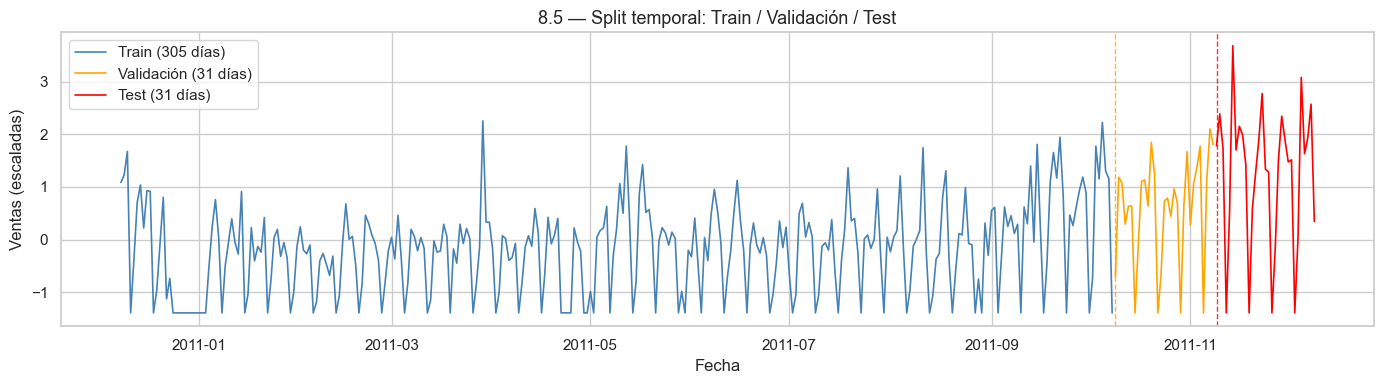


  Guardado: 8.5_split_temporal.png


In [404]:
# ── 8.5  Gráfica del split temporal ──────────────────────────────────────────
print("\n--- 8.5 Visualización del split temporal ---")

fig, ax = plt.subplots(figsize=(14, 4))

ventas_orig = df_normalized['Ventas'].values   # ya escaladas, solo para visualizar
fechas_all  = df_normalized['Fecha'].values

ax.plot(df_train['Fecha'], df_train['Ventas'], color='steelblue',
        linewidth=1.2, label=f'Train ({n_train} días)')
ax.plot(df_val['Fecha'],   df_val['Ventas'],   color='orange',
        linewidth=1.2, label=f'Validación ({n_val} días)')
ax.plot(df_test['Fecha'],  df_test['Ventas'],  color='red',
        linewidth=1.2, label=f'Test ({n_test} días)')

ax.axvline(FECHA_INI_VAL,  color='orange', linestyle='--', linewidth=1.0, alpha=0.8)
ax.axvline(FECHA_INI_TEST, color='red',    linestyle='--', linewidth=1.0, alpha=0.8)

ax.set_title('8.5 — Split temporal: Train / Validación / Test', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (escaladas)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}8.5_split_temporal.png', dpi=150)
plt.show()
plt.close()
print(f"\n  Guardado: 8.5_split_temporal.png")

In [405]:
# ── 8.6  Resumen final ────────────────────────────────────────────────────────
print(f"\n--- 8.6 Resumen del split ---\n")
print(f"  {'Conjunto':<10} {'Filas':>6}  {'% total':>8}  {'Inicio':>12}  {'Fin':>12}")
print(f"  {'-'*56}")
print(f"  {'TRAIN':<10} {n_train:>6}  {n_train/n_total*100:>7.1f}%  "
      f"{df_train['Fecha'].min().date()!s:>12}  {df_train['Fecha'].max().date()!s:>12}")
print(f"  {'VAL':<10} {n_val:>6}  {n_val/n_total*100:>7.1f}%  "
      f"{df_val['Fecha'].min().date()!s:>12}  {df_val['Fecha'].max().date()!s:>12}")
print(f"  {'TEST':<10} {n_test:>6}  {n_test/n_total*100:>7.1f}%  "
      f"{df_test['Fecha'].min().date()!s:>12}  {df_test['Fecha'].max().date()!s:>12}")
print(f"\n  Scalers disponibles para el modelado:")
print(f"    scaler_train → transforma X (features numéricas)")
print(f"    scaler_y     → transforma y (Ventas) — necesario para invertir predicciones a £")
print(f"\n  Arrays listos para el modelado:")
print(f"    X_train {X_train.shape} | y_train {y_train.shape} | y_train_sc {y_train_sc.shape}")
print(f"    X_val   {X_val.shape}   | y_val   {y_val.shape}   | y_val_sc   {y_val_sc.shape}")
print(f"    X_test  {X_test.shape}  | y_test  {y_test.shape}  | y_test_sc  {y_test_sc.shape}")
print(f"\n  ✓ Sección 8 (División train/val/test) completada.")


--- 8.6 Resumen del split ---

  Conjunto    Filas   % total        Inicio           Fin
  --------------------------------------------------------
  TRAIN         305     83.1%    2010-12-08    2011-10-08
  VAL            31      8.4%    2011-10-09    2011-11-08
  TEST           31      8.4%    2011-11-09    2011-12-09

  Scalers disponibles para el modelado:
    scaler_train → transforma X (features numéricas)
    scaler_y     → transforma y (Ventas) — necesario para invertir predicciones a £

  Arrays listos para el modelado:
    X_train (305, 40) | y_train (305,) | y_train_sc (305,)
    X_val   (31, 40)   | y_val   (31,)   | y_val_sc   (31,)
    X_test  (31, 40)  | y_test  (31,)  | y_test_sc  (31,)

  ✓ Sección 8 (División train/val/test) completada.


In [406]:
# ── 8.7  Guardar los tres conjuntos como CSV ──────────────────────────────────
print("\n--- 8.7 Guardado de los conjuntos como CSV ---\n")

RUTA_TRAIN_CSV = 'contenidoCSV/data_train.csv'
RUTA_VAL_CSV   = 'contenidoCSV/data_val.csv'
RUTA_TEST_CSV  = 'contenidoCSV/data_test.csv'

df_train.to_csv(RUTA_TRAIN_CSV, index=False)
df_val.to_csv(RUTA_VAL_CSV,     index=False)
df_test.to_csv(RUTA_TEST_CSV,   index=False)

print(f"  ✓ Train guardado en : {RUTA_TRAIN_CSV}  ({n_train} filas × {df_train.shape[1]} columnas)")
print(f"  ✓ Val   guardado en : {RUTA_VAL_CSV}    ({n_val} filas × {df_val.shape[1]} columnas)")
print(f"  ✓ Test  guardado en : {RUTA_TEST_CSV}   ({n_test} filas × {df_test.shape[1]} columnas)")


--- 8.7 Guardado de los conjuntos como CSV ---

  ✓ Train guardado en : contenidoCSV/data_train.csv  (305 filas × 42 columnas)
  ✓ Val   guardado en : contenidoCSV/data_val.csv    (31 filas × 42 columnas)
  ✓ Test  guardado en : contenidoCSV/data_test.csv   (31 filas × 42 columnas)


# 9.  ENTRENAMIENTO DE MODELOS DE REGRESIÓN

In [29]:
print("\n\n=== 9. ENTRENAMIENTO DE MODELOS DE REGRESIÓN ===")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model  import LinearRegression, Ridge
from sklearn.pipeline      import Pipeline
from sklearn.ensemble      import RandomForestRegressor
from sklearn.metrics       import mean_squared_error
import xgboost as xgb
from itertools import product as iterproduct
import random

RUTA_GRAFICOS = 'graficos/'

# ── Recargar los splits desde CSV (permite ejecutar esta sección de forma independiente)
print("\n--- Cargando datos de train/val/test desde CSV ---")
df_train_s9 = pd.read_csv('contenidoCSV/data_train.csv', parse_dates=['Fecha'])
df_val_s9   = pd.read_csv('contenidoCSV/data_val.csv',   parse_dates=['Fecha'])
df_test_s9  = pd.read_csv('contenidoCSV/data_test.csv',  parse_dates=['Fecha'])

# Ventas en £ originales — desde data_encoded.csv (antes de la normalización)
# Los CSV de train/val/test tienen Ventas ya normalizada (sección 6) → doble escala si usamos scaler_y sobre ellos
df_encoded_s9 = pd.read_csv('contenidoCSV/data_encoded.csv', parse_dates=['Fecha'])

FECHA_FIN_TRAIN = pd.Timestamp('2011-10-08')
FECHA_INI_VAL   = pd.Timestamp('2011-10-09')
FECHA_FIN_VAL   = pd.Timestamp('2011-11-08')
FECHA_INI_TEST  = pd.Timestamp('2011-11-09')
FECHA_FIN_TEST  = pd.Timestamp('2011-12-09')

y_train_raw = df_encoded_s9[df_encoded_s9['Fecha'] <= FECHA_FIN_TRAIN]['Ventas'].values
y_val_raw   = df_encoded_s9[(df_encoded_s9['Fecha'] >= FECHA_INI_VAL) & (df_encoded_s9['Fecha'] <= FECHA_FIN_VAL)]['Ventas'].values
y_test_raw  = df_encoded_s9[(df_encoded_s9['Fecha'] >= FECHA_INI_TEST) & (df_encoded_s9['Fecha'] <= FECHA_FIN_TEST)]['Ventas'].values

COLS_FEATURES = [c for c in df_train_s9.columns if c not in ['Fecha', 'Ventas']]
COL_OBJETIVO  = 'Ventas'

# Features desde los CSV normalizados (features X ya están bien escaladas)
X_train_raw = df_train_s9[COLS_FEATURES].values
X_val_raw   = df_val_s9[COLS_FEATURES].values
X_test_raw  = df_test_s9[COLS_FEATURES].values

# Columnas numéricas a re-escalar (mismas que sección 6 — todas menos dummies, binarias y cíclicas)
cols_no_escalar = (
    [c for c in COLS_FEATURES if c.startswith('Prod_')]
    + ['EsFinDeSemana', 'Es_Navidad',
       'DiaSemana_sin', 'DiaSemana_cos', 'Mes_sin', 'Mes_cos']
)
cols_escalar_s9 = [c for c in COLS_FEATURES if c not in cols_no_escalar]
idx_escalar_s9  = [COLS_FEATURES.index(c) for c in cols_escalar_s9]

# Re-escalar X: fit SOLO sobre train, transform sobre val y test
X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()

scaler_train = StandardScaler()
X_train[:, idx_escalar_s9] = scaler_train.fit_transform(X_train_raw[:, idx_escalar_s9])
X_val  [:, idx_escalar_s9] = scaler_train.transform(X_val_raw  [:, idx_escalar_s9])
X_test [:, idx_escalar_s9] = scaler_train.transform(X_test_raw [:, idx_escalar_s9])

# Escalar y: fit SOLO sobre train (valores en £ originales)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train_raw.reshape(-1,1)).ravel()
y_val_sc   = scaler_y.transform(y_val_raw.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test_raw.reshape(-1,1)).ravel()

print(f"  X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"  y_train — media: £{y_train_raw.mean():,.0f}  std: £{y_train_raw.std():,.0f}")
print(f"  y_train_sc — media: {y_train_sc.mean():.4f}  std: {y_train_sc.std():.4f}  ✓")

# ── Función auxiliar: RMSE en £ originales ────────────────────────────────────
def rmse_original(y_true_sc, y_pred_sc, scaler):
    """Invierte el escalado y calcula RMSE en libras."""
    y_true = scaler.inverse_transform(y_true_sc.reshape(-1, 1)).ravel()
    y_pred = scaler.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()
    return np.sqrt(mean_squared_error(y_true, y_pred)), y_true, y_pred

# ── Función auxiliar: resumen de resultados ──────────────────────────────────
def print_resultados(nombre, rmse_val, rmse_test, y_test_orig, y_pred_orig):
    print(f"\n  {'─'*55}")
    print(f"  {nombre}")
    print(f"  {'─'*55}")
    print(f"    RMSE Validación : £{rmse_val:>10,.2f}")
    print(f"    RMSE Test       : £{rmse_test:>10,.2f}")
    print(f"    Ventas reales   (media £): {y_test_orig.mean():>10,.2f}")
    print(f"    Predicciones    (media £): {y_pred_orig.mean():>10,.2f}")
    print(f"    Error relativo  (RMSE/media): {rmse_test/y_test_orig.mean()*100:.1f}%")

# Diccionario para guardar resultados de todos los modelos
resultados_modelos = {}



=== 9. ENTRENAMIENTO DE MODELOS DE REGRESIÓN ===

--- Cargando datos de train/val/test desde CSV ---
  X_train: (305, 40) | X_val: (31, 40) | X_test: (31, 40)
  y_train — media: £19,895  std: £13,810
  y_train_sc — media: 0.0000  std: 1.0000  ✓


### 9.1  MODELO 1 — REGRESIÓN POLINÓMICA

In [30]:
print("\n\n--- 9.1 Modelo 1: Regresión Polinómica ---")
print("""
  Descripción:
    PolynomialFeatures expande las features originales añadiendo términos
    de grado d (x1², x1·x2, x2², ...) y luego aplica Ridge (regresión
    lineal con regularización L2) para evitar overfitting.
    A mayor grado → más capacidad pero mayor riesgo de sobreajuste.

  Hiperparámetros estudiados:
    · degree (1–3): grado del polinomio
    · alpha  (0.01–100): intensidad de la regularización Ridge
""")



--- 9.1 Modelo 1: Regresión Polinómica ---

  Descripción:
    PolynomialFeatures expande las features originales añadiendo términos
    de grado d (x1², x1·x2, x2², ...) y luego aplica Ridge (regresión
    lineal con regularización L2) para evitar overfitting.
    A mayor grado → más capacidad pero mayor riesgo de sobreajuste.

  Hiperparámetros estudiados:
    · degree (1–3): grado del polinomio
    · alpha  (0.01–100): intensidad de la regularización Ridge



In [31]:
# ── 9.1.1  Pipeline ──────────────────────────────────────────────────────────
pipe_poly = Pipeline([
    ('poly',  PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

# ── 9.1.2  GridSearchCV sobre validación (usando TimeSeriesSplit no aplica
#           aquí porque ya tenemos el split manual; usamos val directamente) ──
param_grid_poly = {
    'poly__degree': [1, 2, 3],
    'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("  GridSearchCV en curso (degree × alpha)...")
best_rmse_poly = np.inf
best_params_poly = {}
resultados_grid_poly = []

for degree in param_grid_poly['poly__degree']:
    for alpha in param_grid_poly['ridge__alpha']:
        pipe_poly.set_params(poly__degree=degree, ridge__alpha=alpha)
        pipe_poly.fit(X_train, y_train_sc)
        y_val_pred_sc = pipe_poly.predict(X_val)
        rmse_v, _, _ = rmse_original(y_val_sc, y_val_pred_sc, scaler_y)
        resultados_grid_poly.append((degree, alpha, rmse_v))
        if rmse_v < best_rmse_poly:
            best_rmse_poly = rmse_v
            best_params_poly = {'degree': degree, 'alpha': alpha}

print(f"\n  Resultados GridSearch (RMSE Val en £):")
print(f"  {'degree':>8} {'alpha':>8} {'RMSE Val':>12}")
print(f"  {'-'*30}")
for d, a, r in sorted(resultados_grid_poly, key=lambda x: x[2]):
    marca = ' ← mejor' if d == best_params_poly['degree'] and a == best_params_poly['alpha'] else ''
    print(f"  {d:>8} {a:>8.2f} £{r:>10,.2f}{marca}")

  GridSearchCV en curso (degree × alpha)...

  Resultados GridSearch (RMSE Val en £):
    degree    alpha     RMSE Val
  ------------------------------
         1    10.00 £  5,149.78 ← mejor
         1     1.00 £  5,200.75
         1     0.10 £  5,287.29
         1     0.01 £  5,303.33
         1   100.00 £  5,722.94
         2   100.00 £  6,129.33
         2    10.00 £  6,427.20
         2     1.00 £  7,278.10
         3   100.00 £  7,931.93
         2     0.10 £  8,386.45
         2     0.01 £  8,914.31
         3    10.00 £  8,919.04
         3     0.01 £ 10,257.27
         3     1.00 £ 10,319.90
         3     0.10 £ 10,404.11


In [32]:
# ── 9.1.3  Reentrenar con mejores hiperparámetros ────────────────────────────
pipe_poly.set_params(poly__degree=best_params_poly['degree'],
                     ridge__alpha=best_params_poly['alpha'])
pipe_poly.fit(X_train, y_train_sc)

y_val_pred_sc_poly  = pipe_poly.predict(X_val)
y_test_pred_sc_poly = pipe_poly.predict(X_test)

rmse_val_poly,  _,              _              = rmse_original(y_val_sc,  y_val_pred_sc_poly,  scaler_y)
rmse_test_poly, y_test_orig,    y_pred_poly    = rmse_original(y_test_sc, y_test_pred_sc_poly, scaler_y)

print_resultados('Regresión Polinómica', rmse_val_poly, rmse_test_poly, y_test_orig, y_pred_poly)
print(f"\n  Mejores hiperparámetros: degree={best_params_poly['degree']}, alpha={best_params_poly['alpha']}")

resultados_modelos['Polinómica'] = {
    'rmse_val': rmse_val_poly, 'rmse_test': rmse_test_poly,
    'y_pred': y_pred_poly, 'params': best_params_poly
}


  ───────────────────────────────────────────────────────
  Regresión Polinómica
  ───────────────────────────────────────────────────────
    RMSE Validación : £  5,149.78
    RMSE Test       : £  5,136.47
    Ventas reales   (media £):  43,853.17
    Predicciones    (media £):  46,032.16
    Error relativo  (RMSE/media): 11.7%

  Mejores hiperparámetros: degree=1, alpha=10.0


#### 9.2  MODELO 2 — RANDOM FOREST REGRESSOR

In [37]:
print("\n\n--- 9.2 Modelo 2: Random Forest Regressor ---")
print("""
  Descripción:
    Ensemble de árboles de decisión entrenados en subconjuntos aleatorios
    de datos y features (bagging). Promedia sus predicciones para reducir
    la varianza y el overfitting respecto a un árbol individual.
    No asume linealidad y captura interacciones entre features.

  Nota: Se excluye 'UnidadesVendidas' del conjunto de features para este
    modelo (y XGBoost). Esta variable es la suma diaria de Quantity, y
    Ventas = Σ(Quantity × UnitPrice) del mismo día → correlación casi
    perfecta que introduce fuga de información (data leakage).
    En su lugar, el modelo dispone de los lags y rolling-means de ambas
    variables, que sí están disponibles en producción.

  Hiperparámetros estudiados (rejilla conservadora anti-overfitting):
    · n_estimators    : número de árboles (100, 200, 300)
    · max_depth       : profundidad máxima (3, 5, 8)
    · min_samples_leaf: muestras mínimas en hoja (3, 5, 10)
    · max_features    : features por split ('sqrt', 0.3, 0.5)
""")



--- 9.2 Modelo 2: Random Forest Regressor ---

  Descripción:
    Ensemble de árboles de decisión entrenados en subconjuntos aleatorios
    de datos y features (bagging). Promedia sus predicciones para reducir
    la varianza y el overfitting respecto a un árbol individual.
    No asume linealidad y captura interacciones entre features.

  Nota: Se excluye 'UnidadesVendidas' del conjunto de features para este
    modelo (y XGBoost). Esta variable es la suma diaria de Quantity, y
    Ventas = Σ(Quantity × UnitPrice) del mismo día → correlación casi
    perfecta que introduce fuga de información (data leakage).
    En su lugar, el modelo dispone de los lags y rolling-means de ambas
    variables, que sí están disponibles en producción.

  Hiperparámetros estudiados (rejilla conservadora anti-overfitting):
    · n_estimators    : número de árboles (100, 200, 300)
    · max_depth       : profundidad máxima (3, 5, 8)
    · min_samples_leaf: muestras mínimas en hoja (3, 5, 10)
    · max_fe

In [38]:
# ── 9.2.1  Excluir UnidadesVendidas (data leakage) ──────────────────────────
COLS_RF   = [c for c in COLS_FEATURES if c != 'UnidadesVendidas']
idx_RF    = [COLS_FEATURES.index(c) for c in COLS_RF]
X_train_rf = X_train[:, idx_RF]
X_val_rf   = X_val  [:, idx_RF]
X_test_rf  = X_test [:, idx_RF]
print(f"  Features usadas en RF: {len(COLS_RF)} (excluida 'UnidadesVendidas')")

# ── 9.2.2  Búsqueda de hiperparámetros (rejilla conservadora) ───────────────
param_grid_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 8],
    'min_samples_leaf': [3, 5, 10],
    'max_features'    : ['sqrt', 0.3, 0.5],
}

print("  RandomizedSearchCV en curso (20 combinaciones)...")
best_rmse_rf   = np.inf
best_params_rf = {}
np.random.seed(42)

from itertools import product as iterproduct
import random
random.seed(42)

# Generar 20 combinaciones aleatorias
keys_rf   = list(param_grid_rf.keys())
values_rf = list(param_grid_rf.values())
todas_rf  = list(iterproduct(*values_rf))
sample_rf = random.sample(todas_rf, min(20, len(todas_rf)))

resultados_rf = []
for combo in sample_rf:
    params = dict(zip(keys_rf, combo))
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    rf.fit(X_train_rf, y_train_sc)
    y_val_pred_sc = rf.predict(X_val_rf)
    rmse_v, _, _  = rmse_original(y_val_sc, y_val_pred_sc, scaler_y)
    resultados_rf.append((params, rmse_v))
    if rmse_v < best_rmse_rf:
        best_rmse_rf   = rmse_v
        best_params_rf = params

print(f"\n  Top 5 combinaciones (por RMSE Val):")
print(f"  {'n_est':>6} {'depth':>6} {'min_leaf':>9} {'max_feat':>9} {'RMSE Val':>12}")
print(f"  {'-'*46}")
for params, rmse_v in sorted(resultados_rf, key=lambda x: x[1])[:5]:
    print(f"  {params['n_estimators']:>6} {params['max_depth']:>6} "
          f"{params['min_samples_leaf']:>9} {str(params['max_features']):>9} "
          f"£{rmse_v:>10,.2f}")

  Features usadas en RF: 39 (excluida 'UnidadesVendidas')
  RandomizedSearchCV en curso (20 combinaciones)...

  Top 5 combinaciones (por RMSE Val):
   n_est  depth  min_leaf  max_feat     RMSE Val
  ----------------------------------------------
     200      8         3      sqrt £  7,742.04
     100      5         5       0.3 £  7,764.68
     300      8         3       0.3 £  7,788.14
     300      8         3      sqrt £  7,818.64
     200      3         5       0.3 £  7,920.29


In [39]:
# ── 9.2.3  Reentrenar con mejores hiperparámetros ────────────────────────────
rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params_rf)
rf_best.fit(X_train_rf, y_train_sc)

y_val_pred_sc_rf  = rf_best.predict(X_val_rf)
y_test_pred_sc_rf = rf_best.predict(X_test_rf)

rmse_val_rf,   _,           _           = rmse_original(y_val_sc,  y_val_pred_sc_rf,  scaler_y)
rmse_test_rf,  y_test_orig, y_pred_rf   = rmse_original(y_test_sc, y_test_pred_sc_rf, scaler_y)

print_resultados('Random Forest Regressor', rmse_val_rf, rmse_test_rf, y_test_orig, y_pred_rf)
print(f"\n  Mejores hiperparámetros: {best_params_rf}")

# ── 9.2.4  Importancia de features ──────────────────────────────────────────
importancias = pd.Series(rf_best.feature_importances_, index=COLS_RF)
top_imp = importancias.sort_values(ascending=False).head(10)
print(f"\n  Top 10 features más importantes (Random Forest):")
for feat, imp in top_imp.items():
    print(f"    {feat:<22}  {imp:.4f}  {'█' * int(imp * 100)}")

resultados_modelos['Random Forest'] = {
    'rmse_val': rmse_val_rf, 'rmse_test': rmse_test_rf,
    'y_pred': y_pred_rf, 'params': best_params_rf
}


  ───────────────────────────────────────────────────────
  Random Forest Regressor
  ───────────────────────────────────────────────────────
    RMSE Validación : £  7,742.04
    RMSE Test       : £ 14,248.03
    Ventas reales   (media £):  43,853.17
    Predicciones    (media £):  35,593.23
    Error relativo  (RMSE/media): 32.5%

  Mejores hiperparámetros: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}

  Top 10 features más importantes (Random Forest):
    NumTransacc             0.2304  ███████████████████████
    NumPedidos              0.2201  ██████████████████████
    NumClientes             0.1040  ██████████
    Prod_Sin_Actividad      0.0798  ███████
    Ventas_Lag7             0.0743  ███████
    DiaSemana_sin           0.0602  ██████
    Ventas_Media_7d         0.0505  █████
    EsFinDeSemana           0.0430  ████
    Ventas_Media_30d        0.0348  ███
    Ventas_Lag1             0.0265  ██


### 9.3  MODELO 3 — XGBOOST REGRESSOR

In [40]:
print("\n\n--- 9.3 Modelo 3: XGBoost Regressor ---")
print("""
  Descripción:
    Gradient Boosting optimizado que construye árboles secuencialmente,
    corrigiendo los errores del árbol anterior. Incorpora regularización
    L1 (reg_alpha) y L2 (reg_lambda) para controlar el overfitting.
    Muy efectivo para series temporales tabulares con features de lag.

  Nota: Al igual que RF, se excluye 'UnidadesVendidas' para evitar
    data leakage (columna COLS_RF, 39 features).

  Hiperparámetros estudiados:
    · n_estimators   : número de árboles (100, 200, 500)
    · max_depth      : profundidad máxima (3, 5, 7)
    · learning_rate  : tasa de aprendizaje (0.01, 0.05, 0.1, 0.2)
    · subsample      : fracción de muestras por árbol (0.7, 0.8, 1.0)
    · colsample_bytree: fracción de features por árbol (0.7, 0.8, 1.0)
    · reg_alpha      : regularización L1 (0, 0.1, 1.0)
    · reg_lambda     : regularización L2 (1, 5, 10)
    Early stopping: detiene el entrenamiento si el RMSE en val no mejora
    en 20 rondas consecutivas → evita overfitting automáticamente.
""")



--- 9.3 Modelo 3: XGBoost Regressor ---

  Descripción:
    Gradient Boosting optimizado que construye árboles secuencialmente,
    corrigiendo los errores del árbol anterior. Incorpora regularización
    L1 (reg_alpha) y L2 (reg_lambda) para controlar el overfitting.
    Muy efectivo para series temporales tabulares con features de lag.

  Nota: Al igual que RF, se excluye 'UnidadesVendidas' para evitar
    data leakage (columna COLS_RF, 39 features).

  Hiperparámetros estudiados:
    · n_estimators   : número de árboles (100, 200, 500)
    · max_depth      : profundidad máxima (3, 5, 7)
    · learning_rate  : tasa de aprendizaje (0.01, 0.05, 0.1, 0.2)
    · subsample      : fracción de muestras por árbol (0.7, 0.8, 1.0)
    · colsample_bytree: fracción de features por árbol (0.7, 0.8, 1.0)
    · reg_alpha      : regularización L1 (0, 0.1, 1.0)
    · reg_lambda     : regularización L2 (1, 5, 10)
    Early stopping: detiene el entrenamiento si el RMSE en val no mejora
    en 20 rond

In [41]:
# COLS_RF / X_train_rf / X_val_rf / X_test_rf ya definidos en 9.2
print(f"  Features usadas en XGBoost: {len(COLS_RF)} (excluida 'UnidadesVendidas')")

param_dist_xgb = {
    'n_estimators'    : [100, 200, 500],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 1.0],
    'reg_lambda'      : [1, 5, 10],
}

print("  RandomizedSearchCV en curso (30 combinaciones + early stopping)...")
keys_xgb   = list(param_dist_xgb.keys())
values_xgb = list(param_dist_xgb.values())
todas_xgb  = list(iterproduct(*values_xgb))
sample_xgb = random.sample(todas_xgb, min(30, len(todas_xgb)))

best_rmse_xgb   = np.inf
best_params_xgb = {}
resultados_xgb  = []

for combo in sample_xgb:
    params = dict(zip(keys_xgb, combo))
    n_est = params.pop('n_estimators')
    xgb_model = xgb.XGBRegressor(
        n_estimators=n_est,
        objective='reg:squarederror',
        random_state=42,
        verbosity=0,
        early_stopping_rounds=20,
        **params
    )
    xgb_model.fit(
        X_train_rf, y_train_sc,
        eval_set=[(X_val_rf, y_val_sc)],
        verbose=False
    )
    y_val_pred_sc = xgb_model.predict(X_val_rf)
    rmse_v, _, _  = rmse_original(y_val_sc, y_val_pred_sc, scaler_y)
    params['n_estimators'] = xgb_model.best_iteration + 1  # nº real de árboles usados
    resultados_xgb.append((params, rmse_v))
    if rmse_v < best_rmse_xgb:
        best_rmse_xgb   = rmse_v
        best_params_xgb = dict(params)

print(f"\n  Top 5 combinaciones (por RMSE Val):")
print(f"  {'n_est':>6} {'depth':>6} {'lr':>6} {'sub':>5} {'col':>5} {'a':>5} {'l':>5} {'RMSE Val':>12}")
print(f"  {'-'*62}")
for params, rmse_v in sorted(resultados_xgb, key=lambda x: x[1])[:5]:
    print(f"  {params.get('n_estimators','-'):>6} {params['max_depth']:>6} "
          f"{params['learning_rate']:>6} {params['subsample']:>5} "
          f"{params['colsample_bytree']:>5} {params['reg_alpha']:>5} "
          f"{params['reg_lambda']:>5} £{rmse_v:>10,.2f}")


  Features usadas en XGBoost: 39 (excluida 'UnidadesVendidas')
  RandomizedSearchCV en curso (30 combinaciones + early stopping)...

  Top 5 combinaciones (por RMSE Val):
   n_est  depth     lr   sub   col     a     l     RMSE Val
  --------------------------------------------------------------
      34      3    0.1   0.7   0.7   0.1    10 £  7,540.44
      34      3    0.1   0.7   0.7   0.1     5 £  7,553.52
      49      5   0.05   1.0   0.8     0     5 £  7,723.00
      16      5    0.2   0.7   0.8     0    10 £  7,776.68
       9      3    0.2   0.8   1.0     0     1 £  7,800.84


In [42]:
# ── 9.3.3  Reentrenar con mejores hiperparámetros ────────────────────────────
n_est_best = best_params_xgb.pop('n_estimators')
xgb_best = xgb.XGBRegressor(
    n_estimators=n_est_best,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0,
    **best_params_xgb
)
xgb_best.fit(X_train_rf, y_train_sc)
best_params_xgb['n_estimators'] = n_est_best  # restaurar para el resumen

y_val_pred_sc_xgb  = xgb_best.predict(X_val_rf)
y_test_pred_sc_xgb = xgb_best.predict(X_test_rf)

rmse_val_xgb,  _,           _           = rmse_original(y_val_sc,  y_val_pred_sc_xgb,  scaler_y)
rmse_test_xgb, y_test_orig, y_pred_xgb  = rmse_original(y_test_sc, y_test_pred_sc_xgb, scaler_y)

print_resultados('XGBoost Regressor', rmse_val_xgb, rmse_test_xgb, y_test_orig, y_pred_xgb)
print(f"\n  Mejores hiperparámetros: {best_params_xgb}")

# ── 9.3.4  Importancia de features XGBoost ───────────────────────────────────
imp_xgb = pd.Series(xgb_best.feature_importances_, index=COLS_RF)
top_xgb = imp_xgb.sort_values(ascending=False).head(10)
print(f"\n  Top 10 features más importantes (XGBoost):")
for feat, imp in top_xgb.items():
    print(f"    {feat:<22}  {imp:.4f}  {'█' * int(imp * 100)}")

resultados_modelos['XGBoost'] = {
    'rmse_val': rmse_val_xgb, 'rmse_test': rmse_test_xgb,
    'y_pred': y_pred_xgb, 'params': best_params_xgb
}


  ───────────────────────────────────────────────────────
  XGBoost Regressor
  ───────────────────────────────────────────────────────
    RMSE Validación : £  7,540.44
    RMSE Test       : £ 15,010.42
    Ventas reales   (media £):  43,853.17
    Predicciones    (media £):  35,174.37
    Error relativo  (RMSE/media): 34.2%

  Mejores hiperparámetros: {'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 10, 'n_estimators': 34}

  Top 10 features más importantes (XGBoost):
    NumPedidos              0.3253  ████████████████████████████████
    NumTransacc             0.1662  ████████████████
    EsFinDeSemana           0.1155  ███████████
    Prod_Sin_Actividad      0.0899  ████████
    Ventas_Media_7d         0.0834  ████████
    Ventas_Lag7             0.0312  ███
    NumClientes             0.0256  ██
    Ventas_Media_30d        0.0205  ██
    Mes_sin                 0.0200  ██
    DiaSemana_cos           0.0175  █


### 9.4  COMPARATIVA FINAL DE MODELOS

In [43]:
print("\n\n--- 9.4 Comparativa final de los 3 modelos ---\n")

print(f"  {'Modelo':<22} {'RMSE Val (£)':>14} {'RMSE Test (£)':>14} {'Error rel. (%)':>16}")
print(f"  {'-'*68}")
mejor_modelo = min(resultados_modelos.items(), key=lambda x: x[1]['rmse_test'])
for nombre, res in resultados_modelos.items():
    marca = ' ← MEJOR' if nombre == mejor_modelo[0] else ''
    er    = res['rmse_test'] / y_test_orig.mean() * 100
    print(f"  {nombre:<22} £{res['rmse_val']:>12,.2f} £{res['rmse_test']:>12,.2f} "
          f"{er:>15.1f}%{marca}")



--- 9.4 Comparativa final de los 3 modelos ---

  Modelo                   RMSE Val (£)  RMSE Test (£)   Error rel. (%)
  --------------------------------------------------------------------
  Polinómica             £    5,149.78 £    5,136.47            11.7% ← MEJOR
  Random Forest          £    7,742.04 £   14,248.03            32.5%
  XGBoost                £    7,540.44 £   15,010.42            34.2%


In [ ]:
# ── 9.4.1  Gráfica — predicciones vs reales en el test set ──────────────────
import matplotlib.ticker as mticker
fechas_test = df_test_s9['Fecha'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
fig.suptitle('9.4 — Predicciones vs Ventas reales (Test set: nov–dic 2011)', fontsize=13)

modelos_plot = [
    ('Polinómica',    resultados_modelos['Polinómica']['y_pred'],   'orange'),
    ('Random Forest', resultados_modelos['Random Forest']['y_pred'],'steelblue'),
    ('XGBoost',       resultados_modelos['XGBoost']['y_pred'],      'green'),
]

ventas_reales_test = scaler_y.inverse_transform(y_test_sc.reshape(-1,1)).ravel()

for ax, (nombre, y_pred, color) in zip(axes, modelos_plot):
    ax.plot(fechas_test, ventas_reales_test, color='black',
            linewidth=1.5, label='Ventas reales', zorder=3)
    ax.plot(fechas_test, y_pred, color=color,
            linewidth=1.5, linestyle='--', label=f'Predicción {nombre}', zorder=2)
    rmse_t = resultados_modelos[nombre]['rmse_test']
    ax.set_title(f'{nombre}  —  RMSE Test: £{rmse_t:,.0f}', fontsize=11)
    ax.set_ylabel('Ventas (£)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}9.4_predicciones_test.png', dpi=150)
plt.show()
plt.close()
print(f"  Guardado: 9.4_predicciones_test.png")

NameError: name 'df_test' is not defined

In [ ]:
# ── 9.4.2  Gráfica — importancia de features comparada ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('9.4 — Importancia de features: Random Forest vs XGBoost', fontsize=13)

for ax, (nombre, imp_series, color) in zip(axes, [
    ('Random Forest', importancias.sort_values(ascending=False).head(15), 'steelblue'),
    ('XGBoost',       imp_xgb.sort_values(ascending=False).head(15),      'green'),
]):
    ax.barh(imp_series.index[::-1], imp_series.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 15 features — {nombre}')
    ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}9.4_importancia_features.png', dpi=150)
plt.show()
plt.close()
print(f"  Guardado: 9.4_importancia_features.png")

print(f"\n  ✓ Sección 9 (Entrenamiento de modelos) completada.")
print(f"    Mejor modelo: {mejor_modelo[0]}  —  RMSE Test: £{mejor_modelo[1]['rmse_test']:,.2f}")